# Shear Wave Splitting Workflow

This notebook demonstrates a complete workflow for loading pickled shear wave splitting data, performing analysis, and visualizing results.

## Overview of the Shear Wave Splitting Process

Shear wave splitting analysis measures seismic anisotropy by analyzing how S-waves split into fast and slow components when traveling through anisotropic media. The analysis involves:

1. **Data Preparation**: Load seismic waveforms with 3-component data (Z, N, E)
2. **Grid Search**: Test multiple lag times and rotation angles to find optimal splitting parameters
3. **Eigenvalue Analysis**: Compute λ1 and λ2 eigenvalues from covariance matrix after rotation and time-shift
4. **Parameter Estimation**: Find the lag and angle that minimize λ2 (maximum linearization)
5. **Quality Control**: Assess measurement quality using rectilinearity, contour analysis, and SNR
6. **Visualization**: Plot splitting parameters, particle motion, and corrected waveforms

### Key Parameters:
- **Fast Direction (φ)**: Angle of polarization of the fast S-wave component
- **Delay Time (δt)**: Time lag between fast and slow arrivals
- **Rectilinearity**: Quality metric (1 - λ2/λ1), where 1 = perfect linear particle motion

## Important Notes

**Updated for modern packages**: This notebook has been updated to work around missing dependencies:
- **`general` module**: Replaced with inline stub functions (no action needed)
- **`mtspec` package**: Replaced with modern `multitaper` package

If you see an import error for `multitaper`, install it with:
```bash
pip install multitaper
```

The pickle files contain **pre-computed splitting results**, so you can analyze existing data without needing all original dependencies.

## 1. Import Libraries and Setup

### Package Dependencies

This workflow requires the following key packages:
- **obspy**: Seismological data handling
- **numpy, matplotlib, pandas**: Standard scientific computing
- **multitaper**: Modern multitaper spectral analysis (replaces deprecated mtspec)

If you encounter import errors for `multitaper`, install it with:
```bash
pip install multitaper
```

The `general` module dependency is handled by stub functions in the code above.

In [6]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ObsPy for seismological data
from obspy import read, UTCDateTime, Stream
from obspy.clients.fdsn import Client

# Add scripts directory to path
sys.path.insert(0, '../scripts')

# ============================================================
# WORKAROUND: Create stub modules for missing dependencies
# ============================================================
import types

# 1. Create 'general' module stubs
general = types.ModuleType('general')
general.plotwaveform = types.ModuleType('general.plotwaveform')
general.util = types.ModuleType('general.util')
general.projection = types.ModuleType('general.projection')

# Define the cov_eig function that shearwavesplit needs
def cov_eig(data_array):
    """
    Compute eigenvalues of covariance matrix
    This is a simplified version for loading pickled data
    """
    if data_array.ndim == 1:
        data_array = data_array.reshape(-1, 1)
    cov_matrix = np.cov(data_array.T)
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    return sorted(eigenvalues, reverse=True)

# Add functions to the modules
general.plotwaveform.cov_eig = cov_eig
general.util.smooth_curve = lambda x, window_len=11: x  # Stub function
general.projection.ll2xy = lambda lon, lat, ref_lon, ref_lat: ([0, 0], [0, 0])  # Stub

# Register the modules in sys.modules so imports work
sys.modules['general'] = general
sys.modules['general.plotwaveform'] = general.plotwaveform
sys.modules['general.util'] = general.util
sys.modules['general.projection'] = general.projection

print("✓ Workaround modules created for 'general' dependencies")

# 2. Handle multitaper import (replaces deprecated mtspec)
try:
    from multitaper import MTSpec
    print("✓ multitaper package available")
except ImportError:
    print("⚠ multitaper package not installed")
    print("  Install with: pip install multitaper")
    print("  (Only needed if using multitaper spectral analysis)")

# ============================================================
# Now import shear wave splitting module
# ============================================================
try:
    from shearwavesplit import *
    import shearwavesplit as sws
    print("✓ Shear wave splitting module loaded successfully")
except ImportError as e:
    print(f"⚠ Warning: Could not import shearwavesplit module: {e}")
    print("  Some functions may not be available.")

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("\n=== Environment Setup Complete ===")
print(f"Working directory: {Path.cwd()}")

✓ Workaround modules created for 'general' dependencies
✓ multitaper package available
✓ Shear wave splitting module loaded successfully

=== Environment Setup Complete ===
Working directory: /Users/mhemmett/Seismology/Axial_Splitting/notebooks


## 2. Load Pickle Data

The pickle files contain `SWSobs` (Shear Wave Splitting Observation) objects with:
- Event metadata (location, time, magnitude)
- Station information
- Waveform data (3-component seismograms)
- P and S arrival times
- Splitting analysis results (MinLambdas list)

In [7]:
# Define path to pickle file
pickle_path = Path('../data/AXAS2.clean.cat.pickle')

# Check if file exists
if not pickle_path.exists():
    raise FileNotFoundError(f"Pickle file not found: {pickle_path}")

print(f"Loading pickle file: {pickle_path.name}")
print(f"File size: {pickle_path.stat().st_size / 1024:.2f} KB\n")

# Load the pickle file
with open(pickle_path, 'rb') as f:
    sws_data = pickle.load(f)

print(f"✓ Pickle file loaded successfully")
print(f"Data type: {type(sws_data)}")
print(f"Number of observations: {len(sws_data)}")

Loading pickle file: AXAS2.clean.cat.pickle
File size: 25001.02 KB

✓ Pickle file loaded successfully
Data type: <class 'list'>
Number of observations: 25036


## 3. Explore the Data Structure

Each observation (SWSobs object) contains:
- `obs_id`: Unique identifier (station_YYYYMMDD_HHMMSS)
- `event_lon`, `event_lat`, `event_depth`: Event location
- `station_code`: Station name
- `p_time`, `s_time`: Phase arrival times
- `st_raw`: Raw 3-component stream
- `st_filter`: Filtered stream
- `MinLambdas`: List of splitting solutions from grid search

In [33]:
# Examine the first observation
if len(sws_data) > 0:
    obs = sws_data[0]
    
    print("=== First Observation Details ===")
    print(f"Type: {type(obs).__name__}")
    if hasattr(obs, 'obs_id'):
        print(f"Observation ID: {obs.obs_id}")
    
    print("\n=== Available Attributes ===")
    
    # First, discover all actual attributes
    actual_attrs = [attr for attr in dir(obs) if not attr.startswith('_')]
    print(f"All attributes: {actual_attrs}")
    
    print("\n=== Key Attributes Check ===")
    # List key attributes we're looking for
    key_attrs = ['obs_id', 'event_id', 'station_code', 'event_lon', 'event_lat', 
                 'event_depth', 'p_time', 's_time', 'st_raw', 'st_filter', 
                 'MinLambdas', 'baz_trigo', 'hyp_dist']
    
    for attr in key_attrs:
        if hasattr(obs, attr):
            value = getattr(obs, attr)
            if attr in ['st_raw', 'st_filter'] and value is not None:
                print(f"  ✓ {attr}: {type(value).__name__} with {len(value)} traces")
            elif attr == 'MinLambdas' and value is not None:
                print(f"  ✓ {attr}: List with {len(value)} splitting solutions")
            else:
                print(f"  ✓ {attr}: {value}")
        else:
            print(f"  ✗ {attr}: Not available")
else:
    print("No observations found in the pickle file.")

=== First Observation Details ===
Type: SWSobs
Observation ID: AXAS2_20150122_000859

=== Available Attributes ===
All attributes: ['MinLambdas', 'az', 'baz_trigo', 'dom_freq', 'dom_period', 'epi_dist', 'event_depth', 'event_id', 'event_lat', 'event_lon', 'get_baz_trigo', 'get_epi_dist', 'get_hyp_dist', 'hyp_dist', 'inc', 'ini_lat', 'ini_lon', 'match', 'minlambda_select', 'obs_id', 'p_time', 'rec', 's_snr', 's_time', 'sta_lat', 'sta_lon', 'sta_z', 'station_code']

=== Key Attributes Check ===
  ✓ obs_id: AXAS2_20150122_000859
  ✓ event_id: 20150122_000858
  ✓ station_code: AXAS2
  ✓ event_lon: -129.989863
  ✓ event_lat: 45.974004
  ✓ event_depth: 2.05625
  ✓ p_time: 2015-01-22T00:08:59.800000Z
  ✓ s_time: 2015-01-22T00:09:00.705000Z
  ✗ st_raw: Not available
  ✗ st_filter: Not available
  ✓ MinLambdas: List with 2 splitting solutions
  ✓ baz_trigo: 1.1604483655219793
  ✓ hyp_dist: 1518.0639949047907


In [9]:
# Print the range of baz_trigo values across all observations
baz_values = [obs.baz_trigo for obs in sws_data if hasattr(obs, 'baz_trigo')]
if baz_values:
    print(f"\n✓ baz_trigo values range from {min(np.rad2deg(baz_values))} to {max(np.rad2deg(baz_values))}")
else:
    print("\n⚠ No baz_trigo values found in observations.")


✓ baz_trigo values range from 0.007128622001521876 to 359.9868417327932


In [32]:
# Print the range of event_depth values across all observations
depth_values = [obs.event_depth for obs in sws_data if hasattr(obs, 'event_depth')]
if depth_values:
    print(f"\n✓ event_depth values range from {min(depth_values)} to {max(depth_values)} km")
else:
    print("\n⚠ No event_depth values found in observations.")


✓ event_depth values range from 0.00625 to 3.99375 km


In [10]:
# Look at the last observation as well
if len(sws_data) > 1:
    obs_last = sws_data[-1]
    
    print("\n=== Last Observation Details ===")
    print(f"Type: {type(obs_last).__name__}")
    if hasattr(obs_last, 'obs_id'):
        print(f"Observation ID: {obs_last.obs_id}")
    
    print("\n=== Key Attributes Check for Last Observation ===")
    
    for attr in key_attrs:
        if hasattr(obs_last, attr):
            value = getattr(obs_last, attr)
            if attr in ['st_raw', 'st_filter'] and value is not None:
                print(f"  ✓ {attr}: {type(value).__name__} with {len(value)} traces")
            elif attr == 'MinLambdas' and value is not None:
                print(f"  ✓ {attr}: List with {len(value)} splitting solutions")
            else:
                print(f"  ✓ {attr}: {value}")
        else:
            print(f"  ✗ {attr}: Not available")


=== Last Observation Details ===
Type: SWSobs
Observation ID: AXAS2_20170212_150211

=== Key Attributes Check for Last Observation ===
  ✓ obs_id: AXAS2_20170212_150211
  ✓ event_id: 20170212_150211
  ✓ station_code: AXAS2
  ✓ event_lon: -129.993203
  ✓ event_lat: 45.926455
  ✓ event_depth: 0.98125
  ✓ p_time: 2017-02-12T15:02:11.700000Z
  ✓ s_time: 2017-02-12T15:02:12.095000Z
  ✗ st_raw: Not available
  ✗ st_filter: Not available
  ✓ MinLambdas: List with 2 splitting solutions
  ✓ baz_trigo: 5.805635096126507
  ✗ hyp_dist: Not available


In [25]:
# Get the first 10 events before quality control filtering
first_10_events = sws_data_unfiltered[:10]

# Calculate hypocentral distance for each event
for obs in first_10_events:
    if hasattr(obs, 'station_code'):
        # Get station information
        station_info = stations_df[stations_df['Station ID'] == obs.station_code]
        
        if not station_info.empty:
            # Add station location
            obs.sta_lat = station_info['Latitude (°N)'].values[0]
            obs.sta_lon = station_info['Longitude (°W)'].values[0]
            obs.sta_z = station_info['Elevation (m)'].values[0]
            
            # Set event location
            if hasattr(obs, 'event_lat') and hasattr(obs, 'event_lon'):
                obs.ini_lat = obs.event_lat
                obs.ini_lon = obs.event_lon
            
            # Calculate hypocentral distance
            if hasattr(obs, 'get_hyp_dist'):
                obs.get_hyp_dist(obs.sta_lon, obs.sta_lat, obs.sta_z, 
                               obs.ini_lon, obs.ini_lat)

# Create a list to store event information
event_data = []

for i, obs in enumerate(first_10_events):
    event_info = {
        'event_number': i + 1,
        'obs_id': obs.obs_id if hasattr(obs, 'obs_id') else None,
        'station_code': obs.station_code if hasattr(obs, 'station_code') else None,
        'event_lon': obs.event_lon if hasattr(obs, 'event_lon') else None,
        'event_lat': obs.event_lat if hasattr(obs, 'event_lat') else None,
        'event_depth_km': obs.event_depth if hasattr(obs, 'event_depth') else None,
        'sta_lon': obs.sta_lon if hasattr(obs, 'sta_lon') else None,
        'sta_lat': obs.sta_lat if hasattr(obs, 'sta_lat') else None,
        'sta_elevation_m': obs.sta_z if hasattr(obs, 'sta_z') else None,
        'p_time': str(obs.p_time) if hasattr(obs, 'p_time') else None,
        's_time': str(obs.s_time) if hasattr(obs, 's_time') else None,
        'hyp_dist_km': obs.hyp_dist if hasattr(obs, 'hyp_dist') else None,
        's_snr': obs.s_snr if hasattr(obs, 's_snr') else None,
        'rec': obs.rec if hasattr(obs, 'rec') else None,
        'inc_deg': obs.inc if hasattr(obs, 'inc') else None,
        'baz_trigo_rad': obs.baz_trigo if hasattr(obs, 'baz_trigo') else None,
        'epi_dist_km': obs.epi_dist if hasattr(obs, 'epi_dist') else None,
        'dom_freq_hz': obs.dom_freq if hasattr(obs, 'dom_freq') else None,
        'dom_period_s': obs.dom_period if hasattr(obs, 'dom_period') else None,
    }
    
    # Add splitting parameters from first MinLambda solution
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        ml = obs.MinLambdas[0]
        event_info['fast_direction_rad'] = ml.angle if hasattr(ml, 'angle') else None
        event_info['fast_direction_deg'] = np.degrees(ml.angle) if hasattr(ml, 'angle') else None
        event_info['delay_time_samples'] = ml.lag if hasattr(ml, 'lag') else None
        event_info['lambda2'] = ml.lambda2 if hasattr(ml, 'lambda2') else None
        event_info['lag_error_samples'] = ml.lag_error if hasattr(ml, 'lag_error') else None
        event_info['angle_error_rad'] = ml.angle_error if hasattr(ml, 'angle_error') else None
        event_info['angle_error_deg'] = np.degrees(ml.angle_error) if hasattr(ml, 'angle_error') else None
    else:
        event_info['fast_direction_rad'] = None
        event_info['fast_direction_deg'] = None
        event_info['delay_time_samples'] = None
        event_info['lambda2'] = None
        event_info['lag_error_samples'] = None
        event_info['angle_error_rad'] = None
        event_info['angle_error_deg'] = None
    
    event_data.append(event_info)

# Create DataFrame
first_10_df = pd.DataFrame(event_data)

# Save to CSV
output_file = '../data/first_10_events_unfiltered_christian.csv'
first_10_df.to_csv(output_file, index=False)

print(f"✓ First 10 events saved to: {output_file}")
print(f"\nDataFrame shape: {first_10_df.shape}")
print(f"\nFirst 10 events summary:")
print(first_10_df[['event_number', 'obs_id', 'event_depth_km', 'hyp_dist_km', 
                    's_snr', 'rec', 'inc_deg', 'fast_direction_deg', 
                    'delay_time_samples']].to_string())

✓ First 10 events saved to: ../data/first_10_events_unfiltered_christian.csv

DataFrame shape: (10, 26)

First 10 events summary:
   event_number                 obs_id  event_depth_km  hyp_dist_km     s_snr       rec    inc_deg  fast_direction_deg  delay_time_samples
0             1  AXAS2_20150122_000859         2.05625  1518.063995  3.386959  0.948354   4.933158               -38.0            6.364583
1             2  AXAS2_20150122_020241         0.74375  1516.744114  4.586738  0.905058  12.682831               -81.0            5.506173
2             3  AXAS2_20150122_030047         0.35625  1516.356420  4.360540  0.983793  13.112185                13.0            2.238095
3             4  AXAS2_20150122_030132         0.60625  1516.608138  5.228774  0.767018   6.088902               -53.0            8.151515
4             5  AXAS2_20150122_033741         1.01250  1517.012967  3.071345  0.909814  20.481152               -78.0           13.863636
5             6  AXAS2_20150122_0340

## 3.5 Quality Control Filtering

Apply quality control filters to select high-quality observations based on:
- **S-wave SNR** (`s_snr > 2.0`): Signal-to-noise ratio for S-wave
- **Rectilinearity** (`rec > 0.7`): Quality of linear particle motion
- **Incidence angle** (`inc < 30°`): Ray path angle from vertical

In [12]:
# Apply quality control filters
print("=== Quality Control Filtering ===\n")
print(f"Initial number of observations: {len(sws_data)}")

# Store original data for comparison
sws_data_unfiltered = sws_data.copy()

# First, check if 'inc' is in degrees or radians by examining a few values
sample_inc_values = []
for obs in sws_data[:min(10, len(sws_data))]:
    if hasattr(obs, 'inc'):
        sample_inc_values.append(obs.inc)

if sample_inc_values:
    print(f"\nSample incidence angle values: {sample_inc_values[:5]}")
    # If all values are less than pi/2 (~1.57), likely in radians
    if all(abs(val) < 2.0 for val in sample_inc_values if val is not None):
        print("⚠ Incidence angles appear to be in RADIANS")
        inc_conversion_factor = np.degrees(1)  # Convert to degrees
        inc_unit = "radians (will convert to degrees)"
    else:
        print("✓ Incidence angles appear to be in DEGREES")
        inc_conversion_factor = 1.0  # Already in degrees
        inc_unit = "degrees"
else:
    print("⚠ No incidence angle values found in sample")
    inc_conversion_factor = 1.0
    inc_unit = "unknown"

# Define filter thresholds
s_snr_threshold = 2.0
rec_threshold = 0.7
inc_threshold = 30.0  # degrees

print(f"\nFilter criteria:")
print(f"  - S-wave SNR (s_snr) > {s_snr_threshold}")
print(f"  - Rectilinearity (rec) > {rec_threshold}")
print(f"  - Incidence angle (inc) < {inc_threshold}° (input in {inc_unit})")

# Apply filters
filtered_data = []
filter_stats = {
    'missing_s_snr': 0,
    'missing_rec': 0,
    'missing_inc': 0,
    'failed_s_snr': 0,
    'failed_rec': 0,
    'failed_inc': 0,
    'passed_all': 0
}

for obs in sws_data:
    # Check if required attributes exist
    has_s_snr = hasattr(obs, 's_snr') and obs.s_snr is not None
    has_rec = hasattr(obs, 'rec') and obs.rec is not None
    has_inc = hasattr(obs, 'inc') and obs.inc is not None
    
    # Track missing attributes
    if not has_s_snr:
        filter_stats['missing_s_snr'] += 1
    if not has_rec:
        filter_stats['missing_rec'] += 1
    if not has_inc:
        filter_stats['missing_inc'] += 1
    
    # Skip if any required attribute is missing
    if not (has_s_snr and has_rec and has_inc):
        continue
    
    # Convert inc to degrees if necessary
    inc_degrees = obs.inc * inc_conversion_factor
    
    # Apply filters
    pass_s_snr = obs.s_snr > s_snr_threshold
    pass_rec = obs.rec > rec_threshold
    pass_inc = inc_degrees < inc_threshold
    
    # Track failures
    if not pass_s_snr:
        filter_stats['failed_s_snr'] += 1
    if not pass_rec:
        filter_stats['failed_rec'] += 1
    if not pass_inc:
        filter_stats['failed_inc'] += 1
    
    # Keep observation if it passes all filters
    if pass_s_snr and pass_rec and pass_inc:
        filtered_data.append(obs)
        filter_stats['passed_all'] += 1

# Update sws_data with filtered observations
sws_data = filtered_data

print(f"\n=== Filtering Results ===")
print(f"Observations with missing attributes:")
print(f"  - Missing s_snr: {filter_stats['missing_s_snr']}")
print(f"  - Missing rec: {filter_stats['missing_rec']}")
print(f"  - Missing inc: {filter_stats['missing_inc']}")
print(f"\nObservations that failed filters (among those with all attributes):")
print(f"  - Failed s_snr filter: {filter_stats['failed_s_snr']}")
print(f"  - Failed rec filter: {filter_stats['failed_rec']}")
print(f"  - Failed inc filter: {filter_stats['failed_inc']}")
print(f"\nFinal results:")
print(f"  - Observations passing all filters: {filter_stats['passed_all']}")
print(f"  - Observations removed: {len(sws_data_unfiltered) - len(sws_data)}")
print(f"  - Retention rate: {100 * len(sws_data) / len(sws_data_unfiltered):.1f}%")

# Display statistics of filtered data
if len(sws_data) > 0:
    filtered_s_snr = [obs.s_snr for obs in sws_data if hasattr(obs, 's_snr')]
    filtered_rec = [obs.rec for obs in sws_data if hasattr(obs, 'rec')]
    filtered_inc = [obs.inc * inc_conversion_factor for obs in sws_data if hasattr(obs, 'inc')]
    
    print(f"\n=== Filtered Data Statistics ===")
    if filtered_s_snr:
        print(f"S-wave SNR range: {min(filtered_s_snr):.2f} - {max(filtered_s_snr):.2f}")
        print(f"S-wave SNR mean: {np.mean(filtered_s_snr):.2f}")
    if filtered_rec:
        print(f"Rectilinearity range: {min(filtered_rec):.3f} - {max(filtered_rec):.3f}")
        print(f"Rectilinearity mean: {np.mean(filtered_rec):.3f}")
    if filtered_inc:
        print(f"Incidence angle range: {min(filtered_inc):.2f}° - {max(filtered_inc):.2f}°")
        print(f"Incidence angle mean: {np.mean(filtered_inc):.2f}°")
else:
    print("\n⚠ WARNING: No observations passed the quality control filters!")
    print("Consider relaxing the filter criteria.")

=== Quality Control Filtering ===

Initial number of observations: 25036

Sample incidence angle values: [np.float64(4.93315840157817), np.float64(12.682831094216402), np.float64(13.112184525414122), np.float64(6.0889020474375775), np.float64(20.481151741673358)]
✓ Incidence angles appear to be in DEGREES

Filter criteria:
  - S-wave SNR (s_snr) > 2.0
  - Rectilinearity (rec) > 0.7
  - Incidence angle (inc) < 30.0° (input in degrees)

=== Filtering Results ===
Observations with missing attributes:
  - Missing s_snr: 0
  - Missing rec: 0
  - Missing inc: 0

Observations that failed filters (among those with all attributes):
  - Failed s_snr filter: 92
  - Failed rec filter: 1177
  - Failed inc filter: 0

Final results:
  - Observations passing all filters: 23771
  - Observations removed: 1265
  - Retention rate: 94.9%

=== Filtered Data Statistics ===
S-wave SNR range: 2.00 - 335.14
S-wave SNR mean: 3.80
Rectilinearity range: 0.700 - 1.000
Rectilinearity mean: 0.919
Incidence angle rang

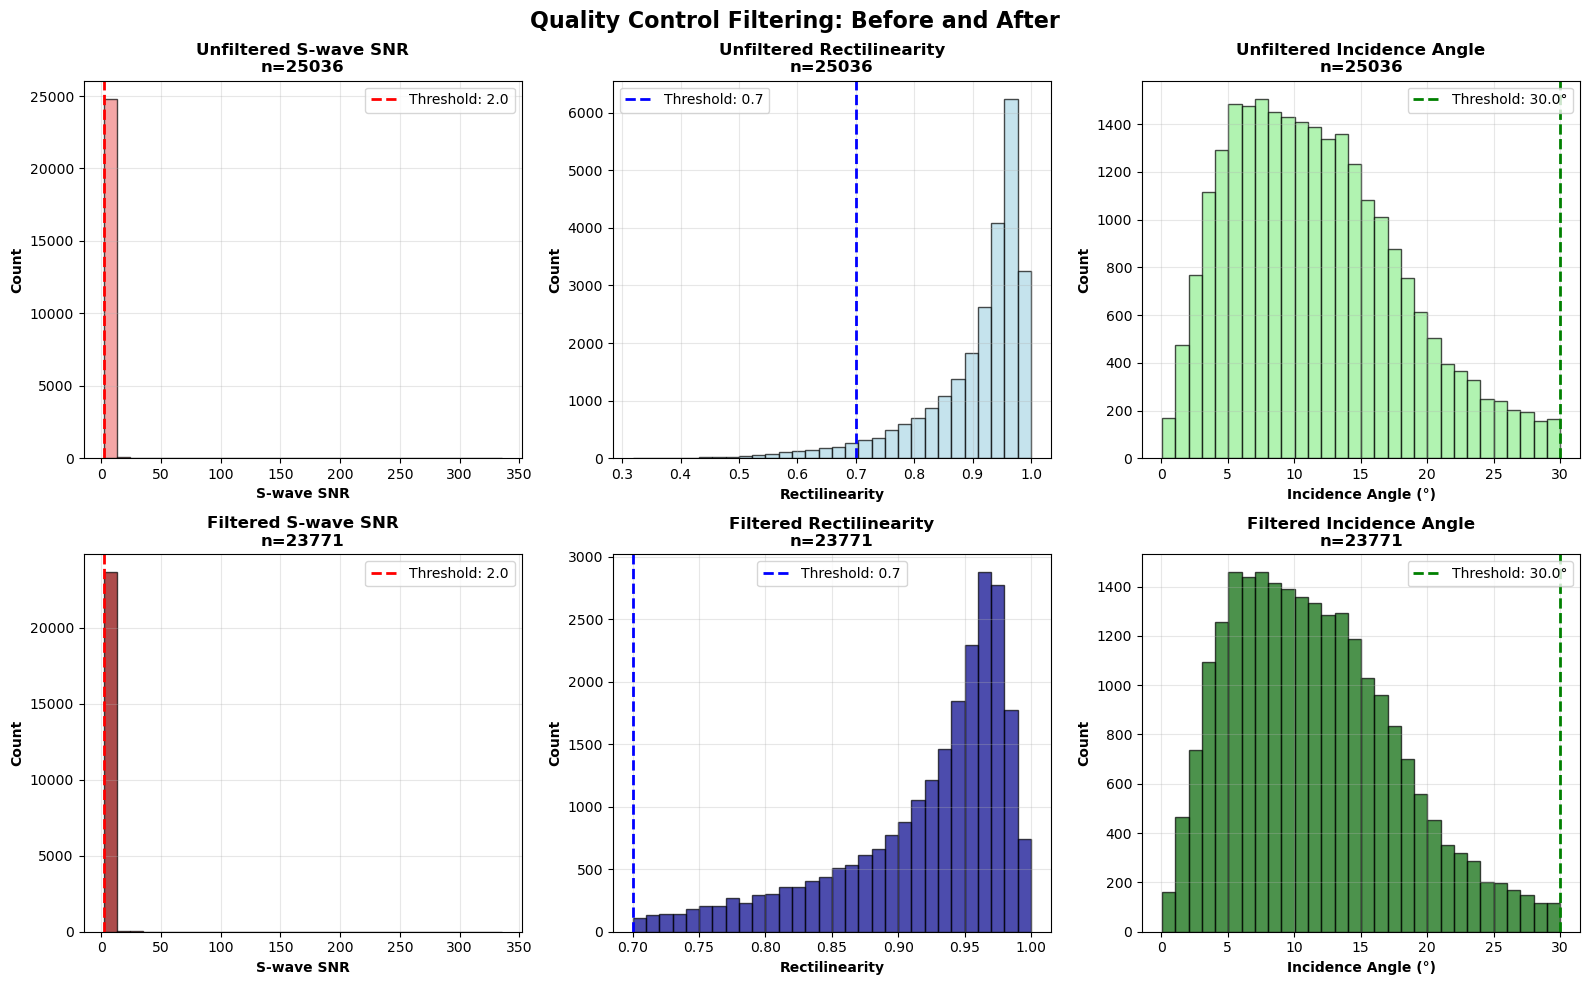


✓ Quality control filtering visualization complete


In [14]:
# Visualize the filtering results
if len(sws_data_unfiltered) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Extract data for unfiltered and filtered datasets
    unfilt_s_snr = [obs.s_snr for obs in sws_data_unfiltered if hasattr(obs, 's_snr') and obs.s_snr is not None]
    unfilt_rec = [obs.rec for obs in sws_data_unfiltered if hasattr(obs, 'rec') and obs.rec is not None]
    unfilt_inc = [obs.inc * inc_conversion_factor for obs in sws_data_unfiltered if hasattr(obs, 'inc') and obs.inc is not None]
    
    filt_s_snr = [obs.s_snr for obs in sws_data if hasattr(obs, 's_snr') and obs.s_snr is not None]
    filt_rec = [obs.rec for obs in sws_data if hasattr(obs, 'rec') and obs.rec is not None]
    filt_inc = [obs.inc * inc_conversion_factor for obs in sws_data if hasattr(obs, 'inc') and obs.inc is not None]
    
    # Row 1: Unfiltered data
    # S-wave SNR
    if unfilt_s_snr:
        axes[0, 0].hist(unfilt_s_snr, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
        axes[0, 0].axvline(s_snr_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {s_snr_threshold}')
        axes[0, 0].set_xlabel('S-wave SNR', fontweight='bold')
        axes[0, 0].set_ylabel('Count', fontweight='bold')
        axes[0, 0].set_title(f'Unfiltered S-wave SNR\nn={len(unfilt_s_snr)}', fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # Rectilinearity
    if unfilt_rec:
        axes[0, 1].hist(unfilt_rec, bins=30, color='lightblue', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(rec_threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {rec_threshold}')
        axes[0, 1].set_xlabel('Rectilinearity', fontweight='bold')
        axes[0, 1].set_ylabel('Count', fontweight='bold')
        axes[0, 1].set_title(f'Unfiltered Rectilinearity\nn={len(unfilt_rec)}', fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    # Incidence angle
    if unfilt_inc:
        axes[0, 2].hist(unfilt_inc, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[0, 2].axvline(inc_threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold: {inc_threshold}°')
        axes[0, 2].set_xlabel('Incidence Angle (°)', fontweight='bold')
        axes[0, 2].set_ylabel('Count', fontweight='bold')
        axes[0, 2].set_title(f'Unfiltered Incidence Angle\nn={len(unfilt_inc)}', fontweight='bold')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # Row 2: Filtered data
    # S-wave SNR
    if filt_s_snr:
        axes[1, 0].hist(filt_s_snr, bins=30, color='darkred', edgecolor='black', alpha=0.7)
        axes[1, 0].axvline(s_snr_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {s_snr_threshold}')
        axes[1, 0].set_xlabel('S-wave SNR', fontweight='bold')
        axes[1, 0].set_ylabel('Count', fontweight='bold')
        axes[1, 0].set_title(f'Filtered S-wave SNR\nn={len(filt_s_snr)}', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No data passed filters', 
                       ha='center', va='center', fontsize=12, color='red')
        axes[1, 0].set_title('Filtered S-wave SNR', fontweight='bold')
    
    # Rectilinearity
    if filt_rec:
        axes[1, 1].hist(filt_rec, bins=30, color='darkblue', edgecolor='black', alpha=0.7)
        axes[1, 1].axvline(rec_threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {rec_threshold}')
        axes[1, 1].set_xlabel('Rectilinearity', fontweight='bold')
        axes[1, 1].set_ylabel('Count', fontweight='bold')
        axes[1, 1].set_title(f'Filtered Rectilinearity\nn={len(filt_rec)}', fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No data passed filters', 
                       ha='center', va='center', fontsize=12, color='red')
        axes[1, 1].set_title('Filtered Rectilinearity', fontweight='bold')
    
    # Incidence angle
    if filt_inc:
        axes[1, 2].hist(filt_inc, bins=30, color='darkgreen', edgecolor='black', alpha=0.7)
        axes[1, 2].axvline(inc_threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold: {inc_threshold}°')
        axes[1, 2].set_xlabel('Incidence Angle (°)', fontweight='bold')
        axes[1, 2].set_ylabel('Count', fontweight='bold')
        axes[1, 2].set_title(f'Filtered Incidence Angle\nn={len(filt_inc)}', fontweight='bold')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    else:
        axes[1, 2].text(0.5, 0.5, 'No data passed filters', 
                       ha='center', va='center', fontsize=12, color='red')
        axes[1, 2].set_title('Filtered Incidence Angle', fontweight='bold')
    
    plt.suptitle('Quality Control Filtering: Before and After', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Quality control filtering visualization complete")
else:
    print("⚠ No data available for visualization")

In [15]:
# Collect statistics from all observations
stations = []
depths = []
num_solutions = []
s_times = []

for obs in sws_data:
    if hasattr(obs, 'station_code'):
        stations.append(obs.station_code)
    if hasattr(obs, 'event_depth'):
        depths.append(obs.event_depth)
    if hasattr(obs, 'MinLambdas'):
        num_solutions.append(len(obs.MinLambdas))
    if hasattr(obs, 's_time'):
        s_times.append(obs.s_time)

print("=== Catalog Summary ===")
print(f"Total observations: {len(sws_data)}")
print(f"\nStations: {set(stations)}")
print(f"\nDepth range: {min(depths):.2f} - {max(depths):.2f} km")
print(f"Average depth: {np.mean(depths):.2f} km")
print(f"\nSolutions per observation: {np.mean(num_solutions):.1f} average")

if s_times:
    print(f"\nTime range: {min(s_times)} to {max(s_times)}")

=== Catalog Summary ===
Total observations: 23771

Stations: {'AXAS2'}

Depth range: 0.01 - 3.99 km
Average depth: 0.98 km

Solutions per observation: 2.0 average

Time range: 2015-01-22T00:09:00.705000Z to 2017-02-12T15:02:12.095000Z


In [16]:
# Bring in our station metadata csv, loaded as a pandas dataframe
import pandas as pd
stations_file = '../data/axial_seamount_stations.csv'
stations_df = pd.read_csv(stations_file)

In [17]:
# Get station lat, lon, and elev for AXAS2 station from stations_df, then save as variables in observation objects
for obs in sws_data:
    if hasattr(obs, 'station_code'):
        station_info = stations_df[stations_df['Station ID'] == obs.station_code]
        if not station_info.empty:
            obs.sta_lat = station_info['Latitude (°N)'].values[0]
            obs.sta_lon = station_info['Longitude (°W)'].values[0]
            obs.sta_z = station_info['Elevation (m)'].values[0]

# Assign event_lat and event_lon to ini_lat and ini_lon for each observation
for obs in sws_data:
    if hasattr(obs, 'event_lat') and hasattr(obs, 'event_lon'):
        obs.ini_lat = 45.9
        obs.ini_lon = -130.1

In [18]:
# Call get_hyp_dist to calculate hypocentral distance for each observation
for obs in sws_data:
    if hasattr(obs, 'get_hyp_dist') and hasattr(obs, 'sta_lon') and hasattr(obs, 'sta_lat') and hasattr(obs, 'sta_z') and hasattr(obs, 'ini_lon') and hasattr(obs, 'ini_lat'):
        obs.get_hyp_dist(obs.sta_lon, obs.sta_lat, obs.sta_z, obs.ini_lon, obs.ini_lat)

In [19]:
sws_data[0]

station AXAS2
S time   : 2015-01-22T00:09:00
longitude: -129.9899
latitude : 45.9740
depth[km]: 2.06
hyp_dist [km]: 1518.06
Number of MinLambdas: 2
baz_trigo: 1.1604


In [20]:
dir(sws_data[0])

['MinLambdas',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_repr_pretty_',
 'az',
 'baz_trigo',
 'dom_freq',
 'dom_period',
 'epi_dist',
 'event_depth',
 'event_id',
 'event_lat',
 'event_lon',
 'get_baz_trigo',
 'get_epi_dist',
 'get_hyp_dist',
 'hyp_dist',
 'inc',
 'ini_lat',
 'ini_lon',
 'match',
 'minlambda_select',
 'obs_id',
 'p_time',
 'rec',
 's_snr',
 's_time',
 'sta_lat',
 'sta_lon',
 'sta_z',
 'station_code']

In [31]:
sws_data[0].event_depth

2.05625

In [26]:
sws_data[0].sta_lat

np.float64(45.936)

In [27]:
sws_data[0].sta_lon

np.float64(-130.013)

In [21]:
sws_data[0].obs_id

'AXAS2_20150122_000859'

In [22]:
sws_data[0].s_time

2015-01-22T00:09:00.705000Z

In [23]:
sws_data[0].s_snr

np.float64(3.3869589598999563)

In [24]:
sws_data[0].inc

np.float64(4.93315840157817)

In [28]:
sws_data[0].event_lat

45.974004

In [29]:
sws_data[0].event_lon

-129.989863

In [73]:
sws_data[0].rec

np.float64(0.9483539661022964)

In [74]:
sws_data[0].MinLambdas[0].lag # This is in samples

np.float64(6.364583333333334)

In [75]:
sws_data[0].MinLambdas[0].angle # This is in radians

np.float64(-0.6632251157578452)

In [86]:
np.rad2deg(sws_data[0].baz_trigo)

np.float64(66.48879368726409)

In [14]:
good_obs = sws_data[1]

## 5. Shear Wave Splitting Analysis

### The Core Algorithm

The splitting analysis uses a grid search approach:

1. **Grid Search Parameters**:
   - Lag times: typically 0-60 samples (0-0.6s at 100 Hz)
   - Rotation angles: -90° to +90° (180° range covers all possibilities)

2. **For each (lag, angle) pair**:
   - Rotate horizontal components by angle
   - Shift one component by lag time
   - Compute eigenvalues (λ1, λ2) of covariance matrix
   - Store λ2 value

3. **Find optimal solution**:
   - Minimum λ2 indicates best linearization
   - Extract lag and angle at minimum
   - Compute error bounds from contour analysis

Let's analyze a single event:

In [15]:
# Select an observation with good quality results
# Look for one with multiple MinLambdas solutions
good_obs = None
for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        good_obs = obs
        break

if good_obs is None:
    print("⚠ No observations with splitting solutions found.")
else:
    print("=== Selected Observation for Analysis ===")
    print(f"\nNumber of splitting solutions: {len(good_obs.MinLambdas)}")
    
    # Display information about each solution
    print("\n=== Splitting Solutions ===")
    for i, min_lambda in enumerate(good_obs.MinLambdas):
        print(f"\nSolution #{i+1}:")
        if hasattr(min_lambda, 'lag'):
            print(f"  Lag (samples): {min_lambda.lag:.2f}")
        if hasattr(min_lambda, 'angle'):
            angle_deg = np.degrees(min_lambda.angle)
            print(f"  Fast direction (degrees): {angle_deg:.1f}°")
        if hasattr(min_lambda, 'rec'):
            print(f"  Rectilinearity: {min_lambda.rec:.3f}")
        if hasattr(min_lambda, 'lambda2'):
            print(f"  λ2 value: {min_lambda.lambda2:.6f}")
        if hasattr(min_lambda, 'lag_error'):
            print(f"  Lag error: {min_lambda.lag_error:.2f} samples")
        if hasattr(min_lambda, 'angle_error'):
            angle_err_deg = np.degrees(min_lambda.angle_error)
            print(f"  Angle error: {angle_err_deg:.1f}°")

=== Selected Observation for Analysis ===

Number of splitting solutions: 2

=== Splitting Solutions ===

Solution #1:
  Lag (samples): 6.36
  Fast direction (degrees): -38.0°
  Rectilinearity: 0.922
  Lag error: 0.98 samples
  Angle error: 16.5°

Solution #2:
  Lag (samples): 16.54
  Fast direction (degrees): -68.0°
  Rectilinearity: 0.797
  Lag error: 1.24 samples
  Angle error: 15.0°


## 6. Visualize Waveforms

Plot the raw and filtered 3-component seismograms

In [16]:
if good_obs and hasattr(good_obs, 'st_filter'):
    st = good_obs.st_filter
    print(good_obs)
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    # Plot each component
    for i, tr in enumerate(st):
        ax = axes[i]
        
        # Time array (relative to start)
        time = np.arange(len(tr.data)) / tr.stats.sampling_rate
        
        # Plot waveform
        ax.plot(time, tr.data, 'k', linewidth=0.8)
        ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add phase markers if available
        if hasattr(good_obs, 'p_time') and hasattr(good_obs, 's_time'):
            p_rel = (good_obs.p_time - tr.stats.starttime)
            s_rel = (good_obs.s_time - tr.stats.starttime)
            
            ax.axvline(p_rel, color='blue', linestyle='--', alpha=0.7, label='P-wave')
            ax.axvline(s_rel, color='red', linestyle='--', alpha=0.7, label='S-wave')
            
            if i == 0:
                ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Time (s)', fontweight='bold')
    
    # Title
    if hasattr(good_obs, 'obs_id'):
        fig.suptitle(f'Three-Component Seismogram\n{good_obs.obs_id}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No waveform data available for plotting.")

⚠ No waveform data available for plotting.


## 7. Plot Splitting Parameters

Visualize the distribution of fast directions and delay times

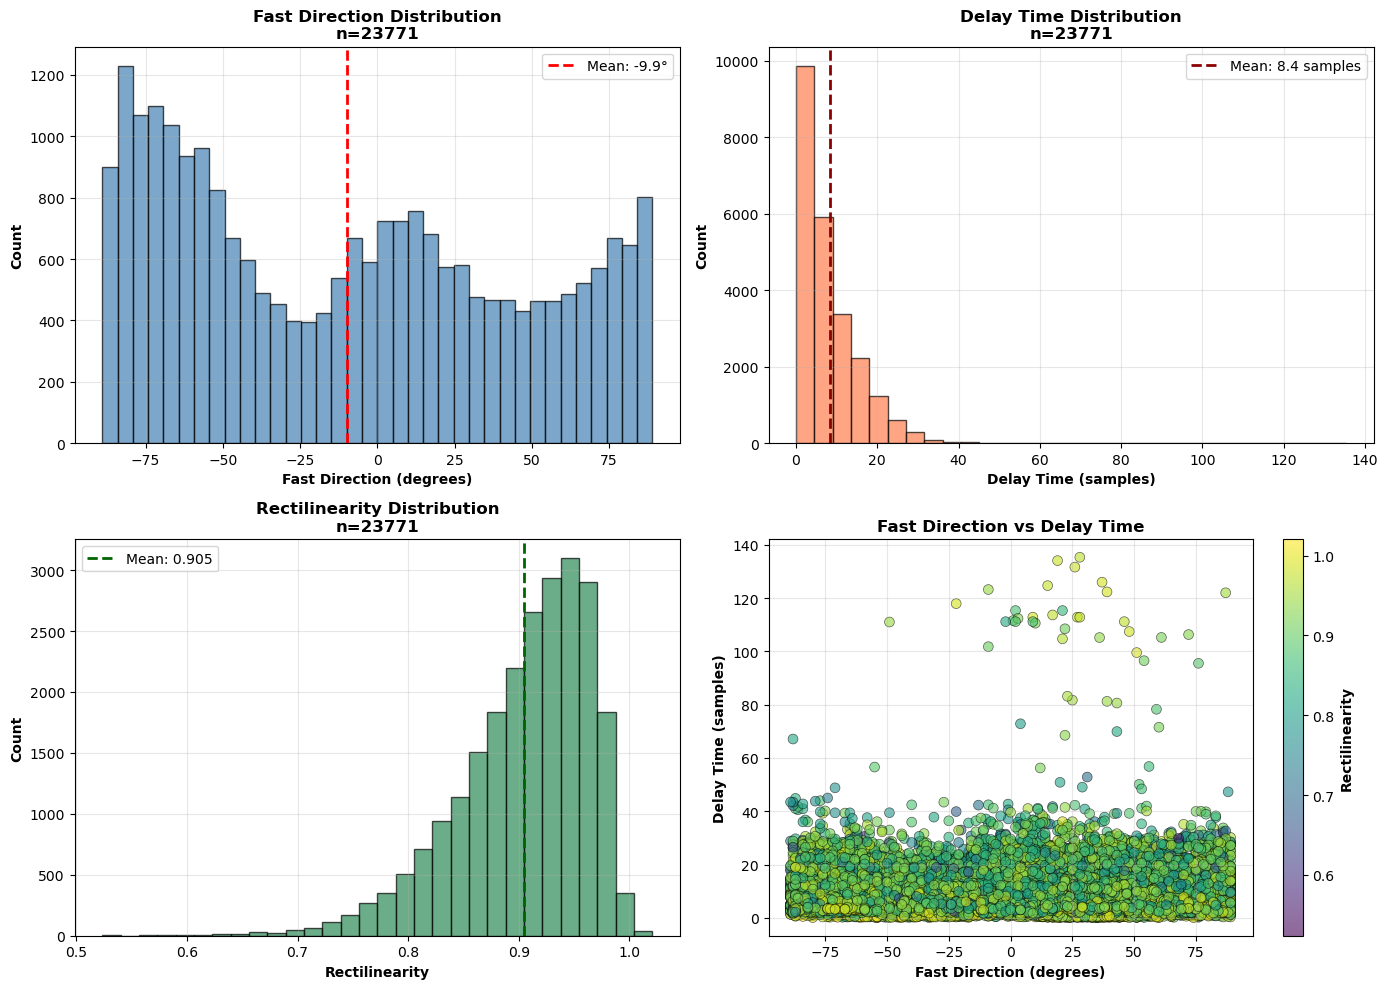

=== Splitting Parameter Statistics ===

Fast Direction:
  Mean: -9.9°
  Std:  54.7°
  Range: [-89.0°, 89.0°]

Delay Time:
  Mean: 8.4 samples
  Std:  8.0 samples
  Range: [0.0, 135.3] samples

Rectilinearity:
  Mean: 0.905
  Std:  0.059
  Range: [0.524, 1.021]


In [17]:
# Extract splitting parameters from all observations
fast_directions = []  # in degrees
delay_times = []      # in samples
rectilinearities = []

for obs in sws_data:
    if hasattr(obs, 'MinLambdas'):
        # Use the first (best) solution
        min_lambda = obs.MinLambdas[0]
        
        if hasattr(min_lambda, 'angle'):
            fast_directions.append(np.degrees(min_lambda.angle))
        
        if hasattr(min_lambda, 'lag'):
            delay_times.append(min_lambda.lag)
        
        if hasattr(min_lambda, 'rec'):
            rectilinearities.append(min_lambda.rec)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fast direction histogram
if fast_directions:
    axes[0, 0].hist(fast_directions, bins=36, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Fast Direction (degrees)', fontweight='bold')
    axes[0, 0].set_ylabel('Count', fontweight='bold')
    axes[0, 0].set_title(f'Fast Direction Distribution\nn={len(fast_directions)}', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvline(np.mean(fast_directions), color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(fast_directions):.1f}°')
    axes[0, 0].legend()

# 2. Delay time histogram
if delay_times:
    axes[0, 1].hist(delay_times, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Delay Time (samples)', fontweight='bold')
    axes[0, 1].set_ylabel('Count', fontweight='bold')
    axes[0, 1].set_title(f'Delay Time Distribution\nn={len(delay_times)}', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline(np.mean(delay_times), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(delay_times):.1f} samples')
    axes[0, 1].legend()

# 3. Rectilinearity histogram
if rectilinearities:
    axes[1, 0].hist(rectilinearities, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Rectilinearity', fontweight='bold')
    axes[1, 0].set_ylabel('Count', fontweight='bold')
    axes[1, 0].set_title(f'Rectilinearity Distribution\nn={len(rectilinearities)}', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axvline(np.mean(rectilinearities), color='darkgreen', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(rectilinearities):.3f}')
    axes[1, 0].legend()

# 4. Scatter: Fast direction vs Delay time
if fast_directions and delay_times and len(fast_directions) == len(delay_times):
    scatter = axes[1, 1].scatter(fast_directions, delay_times, 
                                  c=rectilinearities if rectilinearities else 'purple',
                                  cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[1, 1].set_xlabel('Fast Direction (degrees)', fontweight='bold')
    axes[1, 1].set_ylabel('Delay Time (samples)', fontweight='bold')
    axes[1, 1].set_title('Fast Direction vs Delay Time', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    if rectilinearities:
        cbar = plt.colorbar(scatter, ax=axes[1, 1])
        cbar.set_label('Rectilinearity', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("=== Splitting Parameter Statistics ===")
if fast_directions:
    print(f"\nFast Direction:")
    print(f"  Mean: {np.mean(fast_directions):.1f}°")
    print(f"  Std:  {np.std(fast_directions):.1f}°")
    print(f"  Range: [{min(fast_directions):.1f}°, {max(fast_directions):.1f}°]")

if delay_times:
    print(f"\nDelay Time:")
    print(f"  Mean: {np.mean(delay_times):.1f} samples")
    print(f"  Std:  {np.std(delay_times):.1f} samples")
    print(f"  Range: [{min(delay_times):.1f}, {max(delay_times):.1f}] samples")

if rectilinearities:
    print(f"\nRectilinearity:")
    print(f"  Mean: {np.mean(rectilinearities):.3f}")
    print(f"  Std:  {np.std(rectilinearities):.3f}")
    print(f"  Range: [{min(rectilinearities):.3f}, {max(rectilinearities):.3f}]")

## 7.5 Retrieve Waveforms for Selected High-Quality Events

Now that we've identified the events in our dataset, let's retrieve their waveforms from IRIS for detailed analysis. We'll:
1. Select high-quality observations based on rectilinearity and lag
2. Download 3-component waveforms from IRIS
3. Filter and save them as `st_filter` in each observation object for reuse

**Note:** This section retrieves waveforms early in the workflow so they're available for all subsequent plotting and analysis. The filtered waveforms are stored in each observation's `st_filter` attribute, eliminating the need for duplicate retrieval or filtering code later in the notebook.

In [18]:
sws_data_edit = [good_obs]

In [19]:
sws_data_edit

[station AXAS2
S time   : 2015-01-22T00:09:00
longitude: -129.9899
latitude : 45.9740
depth[km]: 2.06
hyp_dist [km]: 1518.06
Number of MinLambdas: 2
baz_trigo: 1.1604
]

In [20]:
# Select a sample of high-quality observations for waveform retrieval
# Filter for observations with good rectilinearity and available MinLambdas

sample_observations = []

for obs in sws_data_edit:
    if (hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0 and
        hasattr(obs, 's_time') and hasattr(obs, 'station_code')):
        
        ml = obs.MinLambdas[0]
        
            
        sample_observations.append({
            'obs': obs,
            'station': obs.station_code,
            'datetime': obs.p_time,
            'rectilinearity': ml.rec,
            'lag': ml.lag,
            'angle': ml.angle,
            'depth': obs.event_depth if hasattr(obs, 'event_depth') else None
        })

# Sort by rectilinearity and take top observations
sample_observations.sort(key=lambda x: x['rectilinearity'], reverse=True)

# Select diverse sample (limit to first 10 high quality observations)
selected_samples = sample_observations[:10]

print(f"Selected {len(selected_samples)} high-quality observations for waveform retrieval:\n")
for i, sample in enumerate(selected_samples[:5], 1):  # Show first 5
    print(f"{i}. Station {sample['station']}: {sample['datetime']}")
    print(f"   Rectilinearity: {sample['rectilinearity']:.3f}, Lag: {sample['lag']:.2f} samples")
    if sample['depth'] is not None:
        print(f"   Fast direction: {np.degrees(sample['angle']):.1f}°, Depth: {sample['depth']:.2f} km")
    else:
        print(f"   Fast direction: {np.degrees(sample['angle']):.1f}°")

if len(selected_samples) > 5:
    print(f"\n... and {len(selected_samples) - 5} more observations")

Selected 1 high-quality observations for waveform retrieval:

1. Station AXAS2: 2015-01-22T00:08:59.800000Z
   Rectilinearity: 0.922, Lag: 6.36 samples
   Fast direction: -38.0°, Depth: 2.06 km


In [21]:
sample_observations

[{'obs': station AXAS2
S time   : 2015-01-22T00:09:00
longitude: -129.9899
latitude : 45.9740
depth[km]: 2.06
hyp_dist [km]: 1518.06
Number of MinLambdas: 2
baz_trigo: 1.1604
,
  'station': 'AXAS2',
  'datetime': 2015-01-22T00:08:59.800000Z,
  'rectilinearity': np.float64(0.9222985638323362),
  'lag': np.float64(6.364583333333334),
  'angle': np.float64(-0.6632251157578452),
  'depth': 2.05625}]

In [22]:
# Retrieve waveforms for selected observations from IRIS
from obspy.clients.fdsn import Client

client = Client("IRIS")
retrieved_count = 0

# Channel mapping for different stations
channel_map = {
    'AXCC1': ['HHE', 'HHN', 'HHZ'],
    'AXEC1': ['EHE', 'EHN', 'EHZ'],
    'AXEC2': ['HHE', 'HHN', 'HHZ'],
    'AXEC3': ['EHE', 'EHN', 'EHZ'],
    'AXAS1': ['EHE', 'EHN', 'EHZ'],
    'AXAS2': ['EHE', 'EHN', 'EHZ'],
    'AXID1': ['EHE', 'EHN', 'EHZ']
}

print("Retrieving waveforms from IRIS...\n")

for i, sample in enumerate(selected_samples):
    station = sample['station']
    s_time = sample['datetime']
    obs = sample['obs']
    
    # Create extended time window around S-wave
    starttime = s_time - 5.0  # 5 seconds before S
    endtime = s_time + 10.0    # 10 seconds after S
    
    print(f"Retrieving waveforms for {station} at {s_time}...")
    
    try:
        # Get channels for this station
        channels = channel_map.get(station, ['EHE', 'EHN', 'EHZ'])
        
        st = Stream()
        for channel in channels:
            try:
                stream = client.get_waveforms(
                    network='OO',
                    station=station,
                    location='',
                    channel=channel,
                    starttime=starttime,
                    endtime=endtime,
                    attach_response=True
                )
                st += stream
                print(f"  ✓ Retrieved {channel}")
            except Exception as e:
                print(f"  ✗ Failed to get {channel}: {e}")
        
        if len(st) >= 3:  # Need all 3 components
            # Preprocess and save to observation object
            st_processed = st.copy()
            st_processed.detrend('demean')
            st_processed.detrend('linear')
            st_processed.taper(max_percentage=0.05, type='cosine')
            st_processed.filter('bandpass', freqmin=1.0, freqmax=10.0, corners=4, zerophase=True)
            
            # Save filtered stream to observation object as st_filter (matches existing convention)
            obs.st_filter = st_processed
            
            retrieved_count += 1
            print(f"  ✓ Successfully retrieved {len(st)} components")
            print(f"  ✓ Saved filtered waveforms to obs.st_filter\n")
        else:
            print(f"  ✗ Incomplete waveform data ({len(st)} components)\n")
            
    except Exception as e:
        print(f"  ✗ Error retrieving waveforms: {e}\n")

print(f"\nSuccessfully retrieved waveforms for {retrieved_count} observations")
print(f"Filtered waveforms saved to observation objects as 'st_filter' for reuse in plotting")

Retrieving waveforms from IRIS...

Retrieving waveforms for AXAS2 at 2015-01-22T00:08:59.800000Z...
  ✓ Retrieved EHE
  ✓ Retrieved EHN
  ✓ Retrieved EHZ
  ✓ Successfully retrieved 3 components
  ✓ Saved filtered waveforms to obs.st_filter


Successfully retrieved waveforms for 1 observations
Filtered waveforms saved to observation objects as 'st_filter' for reuse in plotting


In [23]:
# For the second event in sample_observations, print out station, datetime, magnitude, depth, s-wave snr, rec, inc, and splitting parameters
if len(selected_samples) > 0:
    second_sample = selected_samples[0]
    obs = second_sample['obs']

    print("=== Second High-Quality Event Details ===")
    print(f"Station: {second_sample['station']}")
    print(f"Date/Time: {second_sample['datetime']}")
    print(f"Depth: {second_sample['depth']:.3f} km")

    # Check for magnitude - might be in different attributes
    magnitude = None
    mag_attrs = ['magnitude', 'mag', 'event_mag', 'event_magnitude']
    
    for attr in mag_attrs:
        if hasattr(obs, attr):
            magnitude = getattr(obs, attr)
            if magnitude is not None:
                print(f"Magnitude: {magnitude}")
                break
    
    if magnitude is None:
        print("Magnitude: Not available")
    
    # Additional event details
    print(f"\nEvent Location:")
    if hasattr(obs, 'event_lon') and hasattr(obs, 'event_lat'):
        print(f"  Longitude: {obs.event_lon:.4f}°W")
        print(f"  Latitude: {obs.event_lat:.4f}°N")
    
    print(f"\nSplitting Parameters:")
    print(f"  Fast direction: {np.degrees(second_sample['angle']):.1f}°")
    print(f"  Delay time: {second_sample['lag']:.3f} samples ({second_sample['lag']/100:.4f} s at 100 Hz)")
    print(f"  Rectilinearity: {second_sample['rectilinearity']:.4f}")

    if hasattr(obs, 'hyp_dist'):
        print(f"\nHypocentral distance: {obs.hyp_dist:.2f} km")

    print(f"\nAngle of incidence: {obs.inc if hasattr(obs, 'inc') else 'Not available'}°")
    
    print(f"\nObservation ID: {obs.obs_id if hasattr(obs, 'obs_id') else 'Not available'}")
else:
    print("No high-quality events available in selected_samples")

=== Second High-Quality Event Details ===
Station: AXAS2
Date/Time: 2015-01-22T00:08:59.800000Z
Depth: 2.056 km
Magnitude: Not available

Event Location:
  Longitude: -129.9899°W
  Latitude: 45.9740°N

Splitting Parameters:
  Fast direction: -38.0°
  Delay time: 6.365 samples (0.0636 s at 100 Hz)
  Rectilinearity: 0.9223

Hypocentral distance: 1518.06 km

Angle of incidence: 4.93315840157817°

Observation ID: AXAS2_20150122_000859


In [24]:
# Also for our first event, plot waveforms using our plotting code
# We should bandpass the data and plot three components, with P- and S-wave picks included

Plotting waveforms for AXAS2


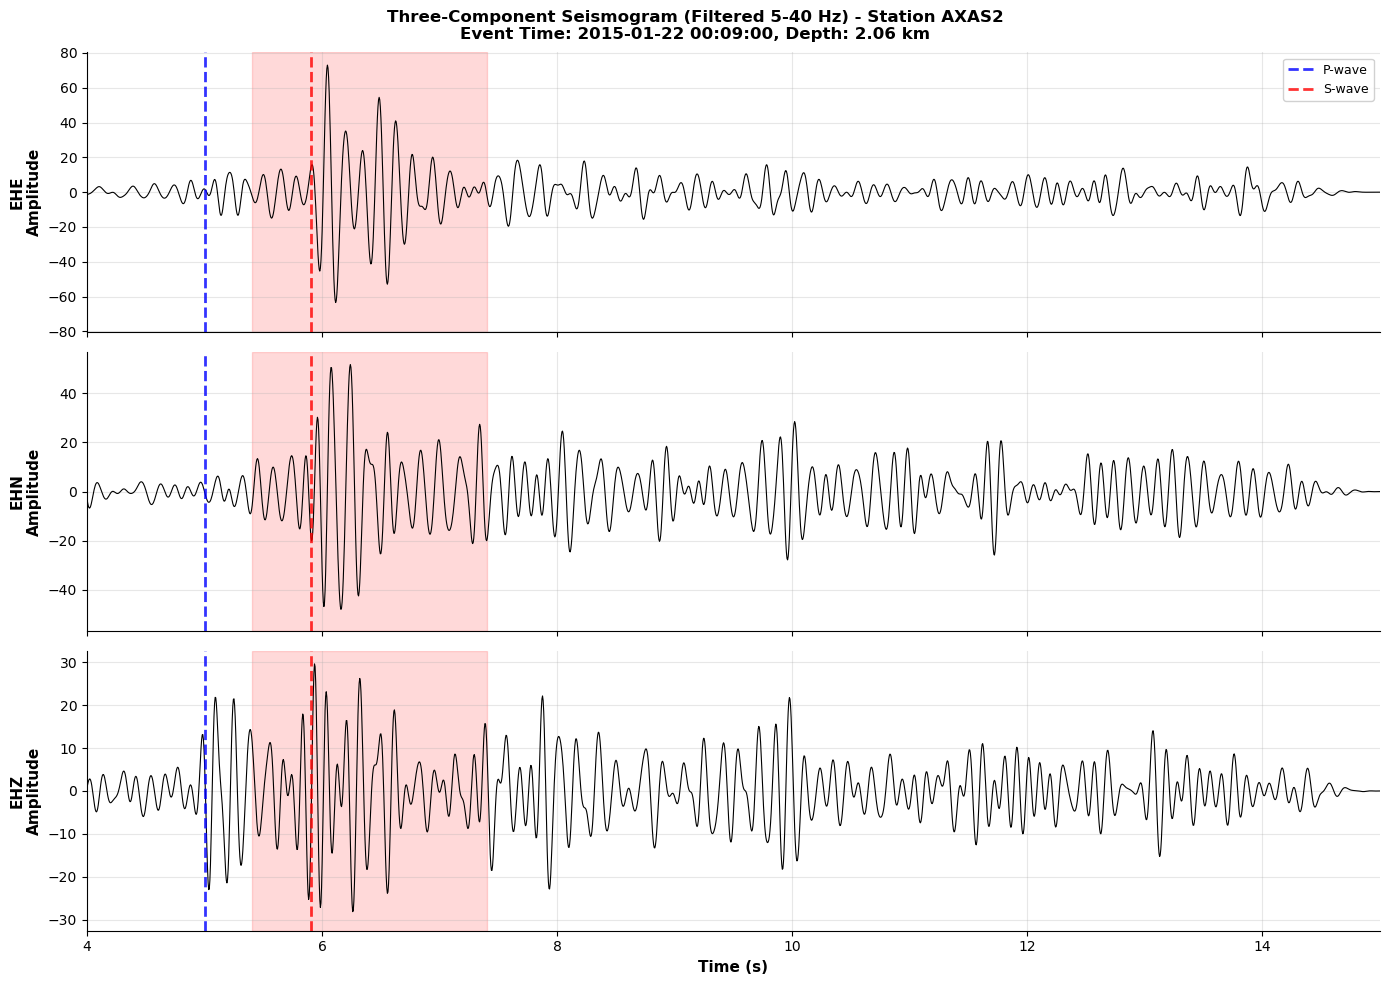

Station: AXAS2, Time: 2015-01-22T00:09:00.705000Z
  P-arrival at: 5.00 s
  S-arrival at: 5.91 s



In [25]:
# Plot waveforms for the first high-quality event with splitting information
if len(selected_samples) > 0:
    sample = selected_samples[0]
    obs = sample['obs']
    
    # Check if waveforms were successfully retrieved
    if not hasattr(obs, 'st_filter') or obs.st_filter is None:
        print(f"⚠ No waveforms available for {sample['station']}, skipping...")
    else:
        st = obs.st_filter.copy()
        print(f"Plotting waveforms for {sample['station']}")
        
        # Sort traces by channel (Z, N, E order)
        st = st.sort(['channel'])
        
        # Create figure
        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
        
        # Get P and S times relative to trace start
        trace_start = st[0].stats.starttime
        p_time_rel = float(obs.p_time - trace_start) if hasattr(obs, 'p_time') else None
        s_time_rel = float(obs.s_time - trace_start) if hasattr(obs, 's_time') else None
        
        # Plot each component
        for i, tr in enumerate(st):
            ax = axes[i]
            
            # Time array (relative to start)
            time = np.arange(len(tr.data)) / tr.stats.sampling_rate

            tr.filter("bandpass", freqmin=5, freqmax=40)
            tr.taper(type="hann", max_percentage=0.05)
            
            # Plot waveform
            ax.plot(time, tr.data, 'k', linewidth=0.8)
            ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold', fontsize=11)
            ax.grid(True, alpha=0.3)
            
            # Normalize to show all traces clearly
            ylim = np.max(np.abs(tr.data))
            ax.set_ylim([-ylim * 1.1, ylim * 1.1])
            ax.set_xlim([4, 15])
            
            # Add S-wave window shading first (so it's behind markers)
            if s_time_rel is not None:
                ax.axvspan(s_time_rel - 0.5, s_time_rel + 1.5, 
                          alpha=0.15, color='red', zorder=0)
            
            # Add phase markers
            if p_time_rel is not None and p_time_rel > 0:
                ax.axvline(p_time_rel, color='blue', linestyle='--', alpha=0.8, 
                          linewidth=2, label='P-wave', zorder=5)
            if s_time_rel is not None and s_time_rel > 0:
                ax.axvline(s_time_rel, color='red', linestyle='--', alpha=0.8, 
                          linewidth=2, label='S-wave', zorder=5)
            
            if i == 0:
                ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
            
            # Remove top and right spines for cleaner look
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        
        axes[-1].set_xlabel('Time (s)', fontweight='bold', fontsize=11)
        
        # Create title with splitting information
        depth_str = f"{sample['depth']:.2f} km" if sample['depth'] is not None else "unknown"
        title = (f"Three-Component Seismogram (Filtered 5-40 Hz) - Station {sample['station']}\n"
                f"Event Time: {obs.s_time.strftime('%Y-%m-%d %H:%M:%S')}, Depth: {depth_str}")
        
        fig.suptitle(title, fontsize=12, fontweight='bold', y=0.98)
        
        # Add text box with splitting parameters
        angle_deg = np.degrees(sample['angle'])
        angle_err_deg = np.degrees(obs.MinLambdas[0].angle_error) if hasattr(obs.MinLambdas[0], 'angle_error') else 0
        lag_sec = sample['lag'] / st[0].stats.sampling_rate
        lag_err_sec = obs.MinLambdas[0].lag_error / st[0].stats.sampling_rate if hasattr(obs.MinLambdas[0], 'lag_error') else 0
        
        info_text = (f"Splitting Parameters:\n"
                    f"  Fast direction φ = {angle_deg:.1f}° ± {angle_err_deg:.1f}°\n"
                    f"  Delay time δt = {lag_sec:.3f} s ± {lag_err_sec:.4f} s\n"
                    f"  Rectilinearity = {sample['rectilinearity']:.3f}\n"
                    f"  λ₂ = {obs.MinLambdas[0].lambda2:.2e}" if hasattr(obs.MinLambdas[0], 'lambda2') else "")
        
        axes[0].text(0.98, 0.97, info_text, transform=axes[0].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=1.5))
        
        plt.tight_layout()
        plt.show()
        
        print(f"Station: {sample['station']}, Time: {obs.s_time}")
        print(f"  P-arrival at: {p_time_rel:.2f} s" if p_time_rel else "  P-arrival: Not available")
        print(f"  S-arrival at: {s_time_rel:.2f} s" if s_time_rel else "  S-arrival: Not available")
        print(f"{'='*80}\n")

else:
    print("No high-quality events available for plotting")

## 8. Advanced Visualization Using Baillard's Plotting Functions

Now we'll use the comprehensive plotting functions from the `shearwavesplit` module (authored by @baillard) to create detailed diagnostic plots showing:

1. **Lambda2 Contour Maps**: Visualize the grid search results
2. **Particle Motion Plots**: Before and after splitting correction
3. **Waveform Comparison**: Original vs unsplit waveforms
4. **Time Evolution**: Splitting parameters over time

In [86]:
# Import additional plotting functions
#from general.plotwaveform import plot_patch, plot_particle_motion

# Select a good observation for detailed plotting
# We'll use the same observation we analyzed earlier
if good_obs is None:
    print("⚠ No good observation found. Please run the previous cells first.")
else:
    print(f"Selected observation: {good_obs.obs_id}")
    print(f"Number of MinLambda solutions: {len(good_obs.MinLambdas)}")
    print(f"Best solution:")
    print(f"  Lag: {good_obs.MinLambdas[0].lag:.2f} samples")
    print(f"  Fast direction: {np.degrees(good_obs.MinLambdas[0].angle):.1f}°")
    print(f"  Rectilinearity: {good_obs.MinLambdas[0].rec:.3f}")

Selected observation: AXAS2_20150122_000859
Number of MinLambda solutions: 2
Best solution:
  Lag: 6.36 samples
  Fast direction: -38.0°
  Rectilinearity: 0.922


In [28]:
def plot_particle_motion(xy_array, time_array=None, ax=None, vmin=None, vmax=None, 
                        xlabel='East', ylabel='North', cmap='viridis'):
    """
    Plot particle motion in the E/N or X/Y plane.
    
    Parameters:
    -----------
    xy_array : numpy.ndarray
        2D array of shape (n_samples, 2) containing [X/E, Y/N] components
    time_array : numpy.ndarray, optional
        1D array of time values (not used, kept for compatibility)
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, uses current axes
    vmin, vmax : float, optional
        Min/max values (not used, kept for compatibility)
    xlabel, ylabel : str
        Labels for x and y axes
    cmap : str
        Colormap (not used, kept for compatibility)
    
    Returns:
    --------
    line : matplotlib line object
        The line plot object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if ax is None:
        ax = plt.gca()
    
    # Extract X and Y components
    x_component = xy_array[:, 0]
    y_component = xy_array[:, 1]
    
    # Plot the trajectory as a simple line in one color
    line = ax.plot(x_component, y_component, 'b-', linewidth=1.5, alpha=0.7)[0]
    
    # Make the plot square with equal aspect ratio
    ax.set_aspect('equal', adjustable='box')
    
    # Set labels
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Set axis limits with some padding
    x_range = np.max(np.abs(x_component))
    y_range = np.max(np.abs(y_component))
    max_range = max(x_range, y_range) * 1.1
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    
    return line


def plot_patch(ax, start, width, facecolor='gray', alpha=0.3, zorder=-1, label=None):
    """
    Add a shaded rectangular patch to an axes.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Axes to add patch to
    start : float
        Starting x-position of the patch
    width : float
        Width of the patch
    facecolor : str
        Color of the patch
    alpha : float
        Transparency of the patch
    zorder : int
        Drawing order (negative values are drawn behind)
    label : str, optional
        Label for the patch
    """
    from matplotlib.patches import Rectangle
    ylim = ax.get_ylim()
    height = ylim[1] - ylim[0]
    
    patch = Rectangle((start, ylim[0]), width, height, 
                     facecolor=facecolor, alpha=alpha, 
                     edgecolor='none', zorder=zorder, label=label)
    ax.add_patch(patch)
    
    return patch

print("✓ Custom plotting functions defined: plot_particle_motion() and plot_patch()")

✓ Custom plotting functions defined: plot_particle_motion() and plot_patch()


### 8.1 Comprehensive Diagnostic Plot

This creates a publication-quality diagnostic figure showing:
- **Top panels**: Original and corrected waveforms (zoomed view)
- **Bottom left**: Lambda2 contour map showing the grid search results
- **Bottom center**: Original particle motion (before correction)
- **Bottom right**: Corrected particle motion (after unsplitting)

In [33]:
if good_obs and hasattr(good_obs, 'st_filter') and hasattr(good_obs, 'MinLambdas'):
    # Extract waveform data
    st = good_obs.st_filter.copy()
    
    # Get horizontal components (assuming order is Z, N, E or similar)
    # We need to identify which traces are horizontal
    horizontal_traces = [tr for tr in st if tr.stats.channel[-1] in ['N', 'E', '1', '2']]
    
    if len(horizontal_traces) >= 2:
        # Create xy_array (2-column array: E/X, N/Y)
        trace1 = horizontal_traces[0].data
        trace2 = horizontal_traces[1].data
        
        # Make sure they're the same length
        min_len = min(len(trace1), len(trace2))
        xy_array = np.column_stack([trace1[:min_len], trace2[:min_len]])
        
        # Get S-wave window (sw1, sw2 are indices relative to trace start)
        sampling_rate = st[0].stats.sampling_rate
        s_arrival_time = good_obs.s_time - st[0].stats.starttime
        
        # Define S-wave window: 0.5s before to 1.5s after S-arrival
        sw1 = int(max(0, (s_arrival_time - 0.5) * sampling_rate))
        sw2 = int(min(len(xy_array), (s_arrival_time + 1.5) * sampling_rate))
        
        # Cut array to S-wave window
        xy_array_cut = xy_array[sw1:sw2, :]
        
        # Get the best splitting parameters
        lag = good_obs.MinLambdas[0].lag
        angle = good_obs.MinLambdas[0].angle
        
        print(f"Processing observation with:")
        print(f"  S-wave window: samples {sw1} to {sw2}")
        print(f"  Best lag: {lag:.2f} samples ({lag/sampling_rate:.3f} s)")
        print(f"  Best angle: {np.degrees(angle):.1f}°")
        
        # Create the diagnostic plot
        plt.close('all')
        
        middle = 0.55
        fig = plt.figure(figsize=(14, 8))
        
        gs1 = gridspec.GridSpec(3, 2,
                               width_ratios=[1, 1],
                               left=0.1, right=0.9, top=0.99, bottom=middle+0.05,
                               wspace=0.01, hspace=0)
        gs2 = gridspec.GridSpec(1, 3,
                               width_ratios=[1, 1, 1],
                               left=0.1, right=0.9, top=middle-0.05, bottom=0.1,
                               wspace=0.1)
        
        # Waveform axes
        ax_wave_1 = plt.subplot(gs1[0])
        ax_wave_2 = plt.subplot(gs1[2], sharey=ax_wave_1, sharex=ax_wave_1)
        ax_wave_3 = plt.subplot(gs1[4], sharey=ax_wave_1, sharex=ax_wave_1)
        ax_wavez_1 = plt.subplot(gs1[1])
        ax_wavez_2 = plt.subplot(gs1[3], sharey=ax_wavez_1, sharex=ax_wavez_1)
        ax_wavez_3 = plt.subplot(gs1[5], sharey=ax_wavez_1, sharex=ax_wavez_1)
        
        # Analysis axes
        ax_lambda = plt.subplot(gs2[0])
        ax_polar_1 = plt.subplot(gs2[1])
        ax_polar_2 = plt.subplot(gs2[2], sharex=ax_polar_1, sharey=ax_polar_1)
        
        ax_wave = [ax_wave_1, ax_wave_2, ax_wave_3]
        ax_wavez = [ax_wavez_1, ax_wavez_2, ax_wavez_3]
        
        # Plot unsplit waveforms
        (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=True, ax_list=ax_wave)
        (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=True, ax_list=ax_wavez)
        xy_unsplit_cut = xy_unsplit[sw1:sw2, :]
        
        # Plot particle motions
        plot_particle_motion(xy_array_cut, time_array=None, ax=ax_polar_1, 
                           vmin=None, vmax=None, xlabel='X', ylabel='Y')
        plot_particle_motion(xy_unsplit_cut, time_array=None, ax=ax_polar_2, 
                           vmin=None, vmax=None, xlabel='X', ylabel='Y')
        
        # Plot Lambda2 contour if available
        if hasattr(good_obs.MinLambdas[0], 'LAMBDA2'):
            LAMBDA2 = good_obs.MinLambdas[0].LAMBDA2
            LAGS = good_obs.MinLambdas[0].LAGS
            ANGLES = good_obs.MinLambdas[0].ANGLES
            
            extent = [ANGLES[0, 0], ANGLES[0, -1], LAGS[0, 0], LAGS[-1, 0]]
            im = ax_lambda.imshow(LAMBDA2, aspect='auto', extent=extent, 
                                origin='lower', cmap='jet_r')
            ax_lambda.plot(angle, lag, 'w*', markersize=15, markeredgecolor='k')
            ax_lambda.set_xlabel('Angle (rad)')
            ax_lambda.set_ylabel('Lag (samples)')
            ax_lambda.set_title(r'Min. $\lambda_{2}$')
            plt.colorbar(im, ax=ax_lambda)
        else:
            ax_lambda.text(0.5, 0.5, 'Lambda2 data not available', 
                         ha='center', va='center', transform=ax_lambda.transAxes)
        
        # Cosmetics
        plot_patch(ax_wave_1, start=sw1, width=sw2-sw1, facecolor='0.9', zorder=-1, label='S')
        ax_wave_1.axvline(x=sw1+4, linestyle='-', color='k', lw=1, zorder=0)
        ax_wave_1.set_xlim([0, ax_wave_1.get_xlim()[1]])
        
        plot_patch(ax_wavez_1, start=sw1, width=sw2-sw1, facecolor='0.9', zorder=-1, label='S')
        ax_wavez_1.axvline(x=sw1+4, linestyle='-', color='k', lw=1, zorder=0)
        
        plt.setp(ax_polar_1.get_yticklabels(), visible=False)
        ax_wavez_1.yaxis.set_visible(False)
        ax_wavez_2.yaxis.set_visible(False)
        ax_wavez_3.yaxis.set_visible(False)
        ax_wave_2.yaxis.set_visible(False)
        ax_wave_3.yaxis.set_visible(False)
        ax_wave_1.xaxis.set_visible(False)
        ax_wave_2.xaxis.set_visible(False)
        
        ax_polar_1.set_ylabel('')
        ax_polar_1.set_title('Initial')
        ax_polar_2.set_title('Corrected (Unsplit)')
        ax_polar_2.yaxis.set_label_position("right")
        ax_polar_2.yaxis.tick_right()
        ax_wavez_1.set_xlim([sw1-50, sw2+50])
        
        fig.suptitle(f'Splitting Diagnostic Plot - {good_obs.obs_id}', 
                    fontsize=14, fontweight='bold', y=0.995)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Diagnostic plot created successfully")
        
    else:
        print("⚠ Could not find two horizontal components in the waveform data")
else:
    print("⚠ No suitable observation available for plotting")

⚠ No suitable observation available for plotting


### 8.2 Particle Motion Comparison for Multiple Events

Compare particle motion before and after splitting correction for several observations

Found 6 observations to plot


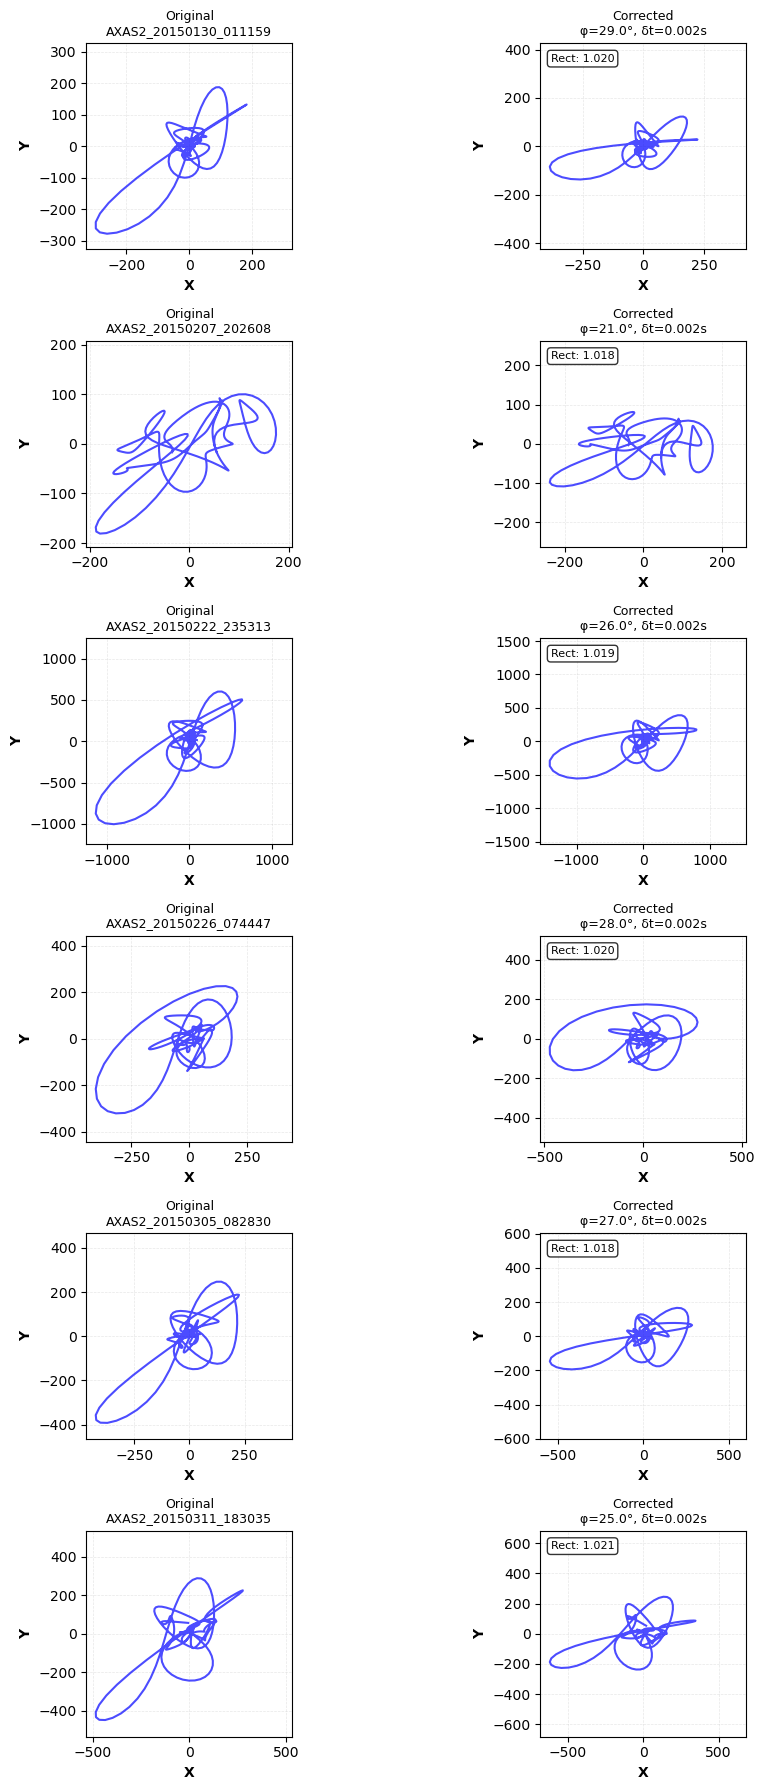


✓ Particle motion comparison plot created


In [93]:
# Select multiple good observations
n_plots = 6  # Number of observations to plot
good_observations = []

for obs in sws_data:
    if (hasattr(obs, 'st_filter') and obs.st_filter is not None and
        hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0):
        good_observations.append(obs)
        if len(good_observations) >= n_plots:
            break

if len(good_observations) > 0:
    print(f"Found {len(good_observations)} observations to plot")
    
    # Create figure with subplots
    fig, axes = plt.subplots(len(good_observations), 2, figsize=(10, 3*len(good_observations)))
    
    if len(good_observations) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, obs in enumerate(good_observations):
        st = obs.st_filter.copy()
        
        # Get horizontal components
        horizontal_traces = [tr for tr in st if tr.stats.channel[-1] in ['N', 'E', '1', '2']]
        
        if len(horizontal_traces) >= 2:
            # Create xy_array
            trace1 = horizontal_traces[0].data
            trace2 = horizontal_traces[1].data
            min_len = min(len(trace1), len(trace2))
            xy_array = np.column_stack([trace1[:min_len], trace2[:min_len]])
            
            # Get S-wave window
            sampling_rate = st[0].stats.sampling_rate
            s_arrival_time = obs.s_time - st[0].stats.starttime
            sw1 = int(max(0, (s_arrival_time - 0.5) * sampling_rate))
            sw2 = int(min(len(xy_array), (s_arrival_time + 1.5) * sampling_rate))
            
            xy_array_cut = xy_array[sw1:sw2, :]
            
            # Get splitting parameters
            lag = obs.MinLambdas[0].lag
            angle = obs.MinLambdas[0].angle
            
            # Unsplit
            (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=False)
            xy_unsplit_cut = xy_unsplit[sw1:sw2, :]
            
            # Plot original
            ax1 = axes[idx, 0]
            plot_particle_motion(xy_array_cut, time_array=None, ax=ax1,
                               vmin=None, vmax=None, xlabel='X', ylabel='Y')
            ax1.set_title(f'Original\n{obs.obs_id}', fontsize=9)
            
            # Plot corrected
            ax2 = axes[idx, 1]
            plot_particle_motion(xy_unsplit_cut, time_array=None, ax=ax2,
                               vmin=None, vmax=None, xlabel='X', ylabel='Y')
            ax2.set_title(f'Corrected\nφ={np.degrees(angle):.1f}°, δt={lag/sampling_rate:.3f}s', 
                         fontsize=9)
            
            # Add rectilinearity info
            if hasattr(obs.MinLambdas[0], 'rec'):
                ax2.text(0.05, 0.95, f'Rect: {obs.MinLambdas[0].rec:.3f}',
                        transform=ax2.transAxes, va='top', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Particle motion comparison plot created")
else:
    print("⚠ No suitable observations found for plotting")

### 8.3 Splitting Parameters Over Time

Use the `movehisto2d` function from @baillard to visualize how splitting parameters evolve over time

Plotting time evolution of delay times for 25036 observations
Time range: 2015-01-22T00:09:00.705000Z to 2017-02-12T15:02:12.095000Z
Duration: 752.6 days


ValueError: 'lowerleft' is not a valid value for origin; supported values are 'upper', 'lower'

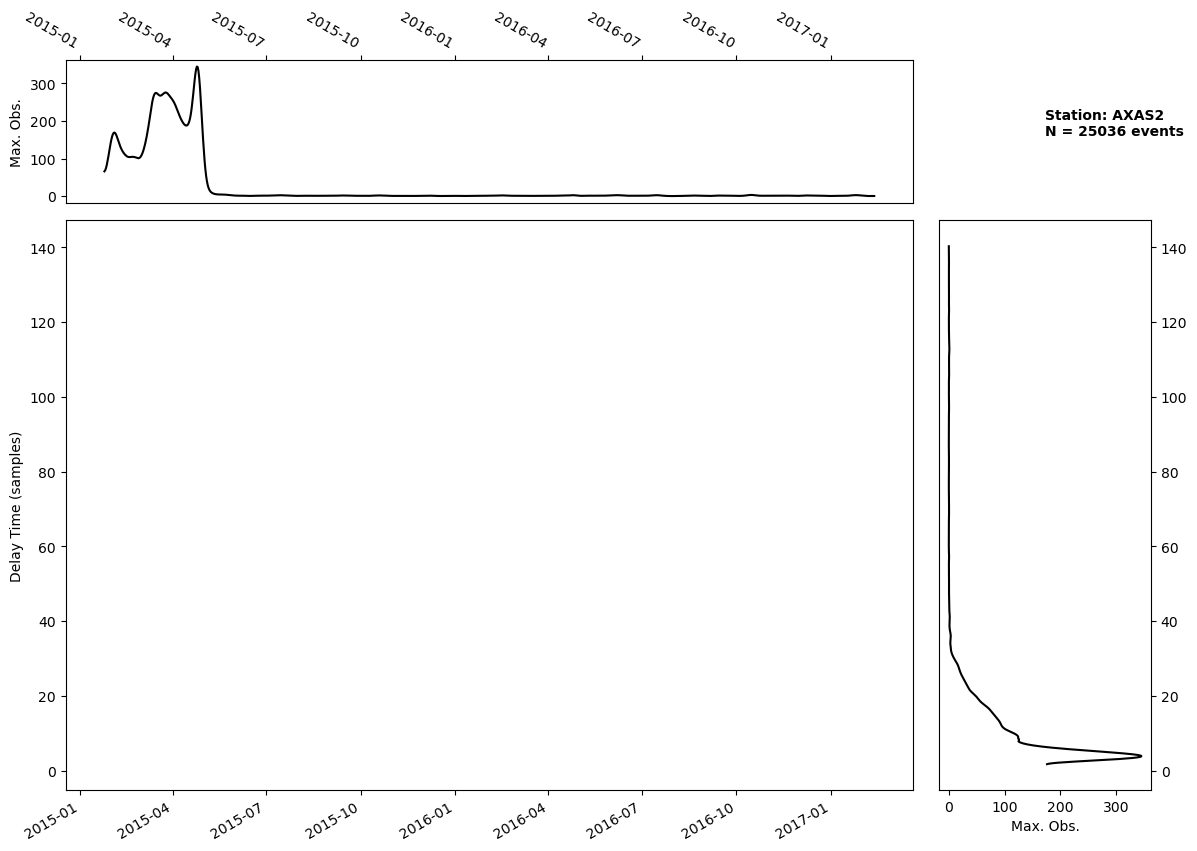

In [90]:
# Import the movehisto2d function from shearwavesplit_plot
import sys
sys.path.insert(0, '../scripts')
from shearwavesplit_plot import movehisto2d

# Extract time and delay time data
times = []
lags = []

for obs in sws_data:
    if hasattr(obs, 's_time') and hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        times.append(obs.s_time)
        lags.append(obs.MinLambdas[0].lag)

if len(times) > 10:  # Need enough data points
    print(f"Plotting time evolution of delay times for {len(times)} observations")
    
    # Define time window parameters
    time_start = min(times)
    time_end = max(times)
    
    print(f"Time range: {time_start} to {time_end}")
    print(f"Duration: {(time_end - time_start) / 86400:.1f} days")
    
    # Create the moving histogram plot
    ax_list = movehisto2d(
        x=times,
        y=lags,
        x_width=3,  # 3-day window
        y_width=2,  # 2-sample window for lags
        x_start=time_start,
        y_start=0,
        x_end=time_end,
        y_end=max(lags) + 5,
        x_over=0.9,  # 90% overlap for smooth visualization
        y_over=0.7,
        norm_y=True,
        smooth=True,
        gaussian_x_per=0.5,
        gaussian_y_per=0.5,
        x_label='Time',
        y_label='Delay Time (samples)',
        text_list=[f'Station: {sws_data[0].station_code}', 
                   f'N = {len(times)} events']
    )
    
    print("\n✓ Time evolution plot created")
    
else:
    print(f"⚠ Not enough data points ({len(times)}) to create time evolution plot")

### 8.4 Fast Direction Rose Plot (Polar Histogram)

Use the polar histogram function to visualize the distribution of fast directions

Plotting rose diagram for 25036 fast directions


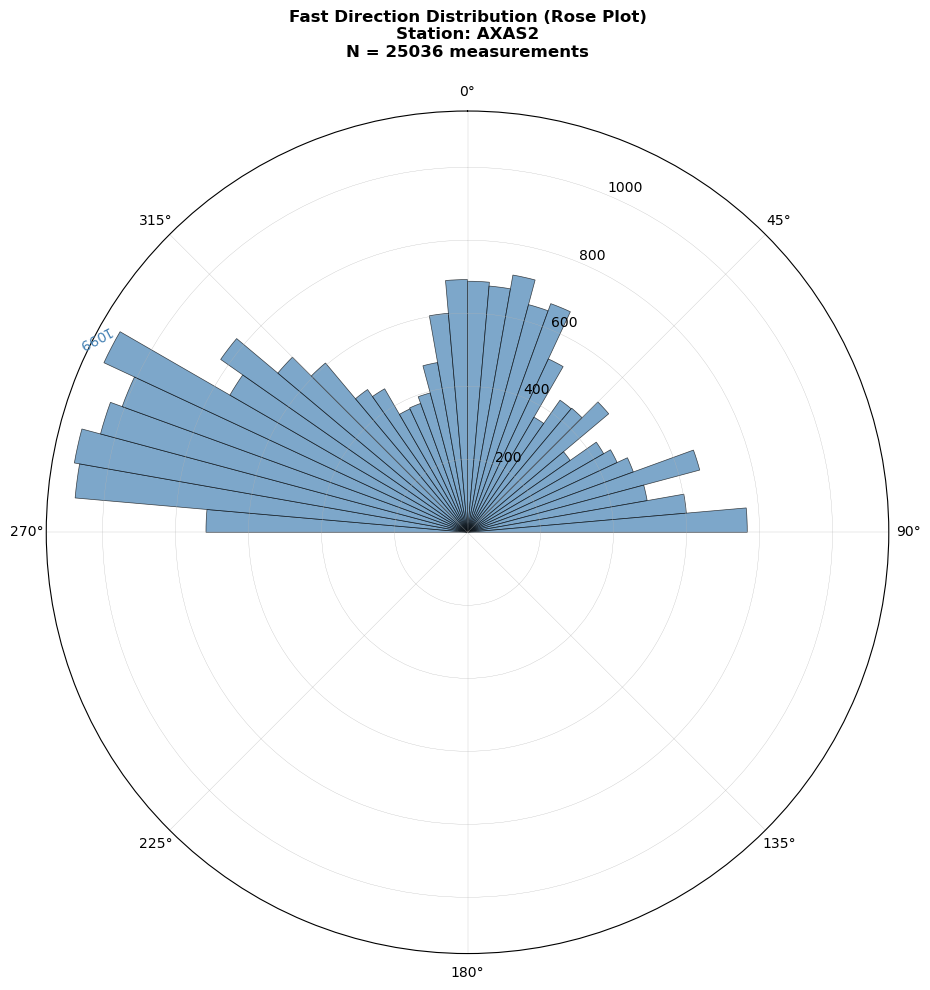


=== Fast Direction Statistics ===
Mean direction: 347.3° (trigonometric)
               102.7° (from North, clockwise)
Number of measurements: 25036
Circular concentration: R = 0.603
Circular std deviation: 57.6°


In [ ]:
# Extract fast directions (in radians for trigonometric convention)
fast_angles_rad = []
weights = []  # Can weight by rectilinearity

for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        min_lambda = obs.MinLambdas[0]
        if hasattr(min_lambda, 'angle'):
            # Convert to trigonometric convention (0 = East, counterclockwise)
            fast_angles_rad.append(min_lambda.angle)
            
            # Weight by rectilinearity if available
            if hasattr(min_lambda, 'rec'):
                weights.append(min_lambda.rec)
            else:
                weights.append(1.0)

if len(fast_angles_rad) > 0:
    print(f"Plotting rose diagram for {len(fast_angles_rad)} fast directions")
    
    # Create polar plot
    fig = plt.figure(figsize=(10, 10))
    ax_polar = fig.add_subplot(111, projection='polar')
    
    # Use the plot_polar_histo function
    sws.plot_polar_histo(
        trigo_angles=fast_angles_rad,
        weights=weights,
        width_bin_deg=5,  # 5-degree bins
        ax_polar=ax_polar,
        facecolor='steelblue',
        edgecolor='black',
        lw=0.5,
        alpha=0.7,
        text=True
    )
    
    # Set 0 degrees to North (top)
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)  # Clockwise
    
    # Add title
    ax_polar.set_title(f'Fast Direction Distribution (Rose Plot)\n'
                      f'Station: {sws_data[0].station_code if sws_data else "Unknown"}\n'
                      f'N = {len(fast_angles_rad)} measurements',
                      fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate statistics
    mean_angle = np.arctan2(np.mean(np.sin(fast_angles_rad)), 
                           np.mean(np.cos(fast_angles_rad)))
    mean_angle_deg = np.degrees(mean_angle)
    if mean_angle_deg < 0:
        mean_angle_deg += 360
    
    print(f"\n=== Fast Direction Statistics ===")
    print(f"Mean direction: {mean_angle_deg:.1f}° (trigonometric)")
    print(f"               {(90 - mean_angle_deg) % 360:.1f}° (from North, clockwise)")
    print(f"Number of measurements: {len(fast_angles_rad)}")
    
    # Calculate circular standard deviation
    R = np.sqrt(np.mean(np.sin(fast_angles_rad))**2 + np.mean(np.cos(fast_angles_rad))**2)
    circular_std = np.sqrt(-2 * np.log(R))
    print(f"Circular concentration: R = {R:.3f}")
    print(f"Circular std deviation: {np.degrees(circular_std):.1f}°")
    
else:
    print("⚠ No fast direction data available for plotting")

### 8.5 Quality Metrics Summary

Visualize the quality of splitting measurements through various metrics

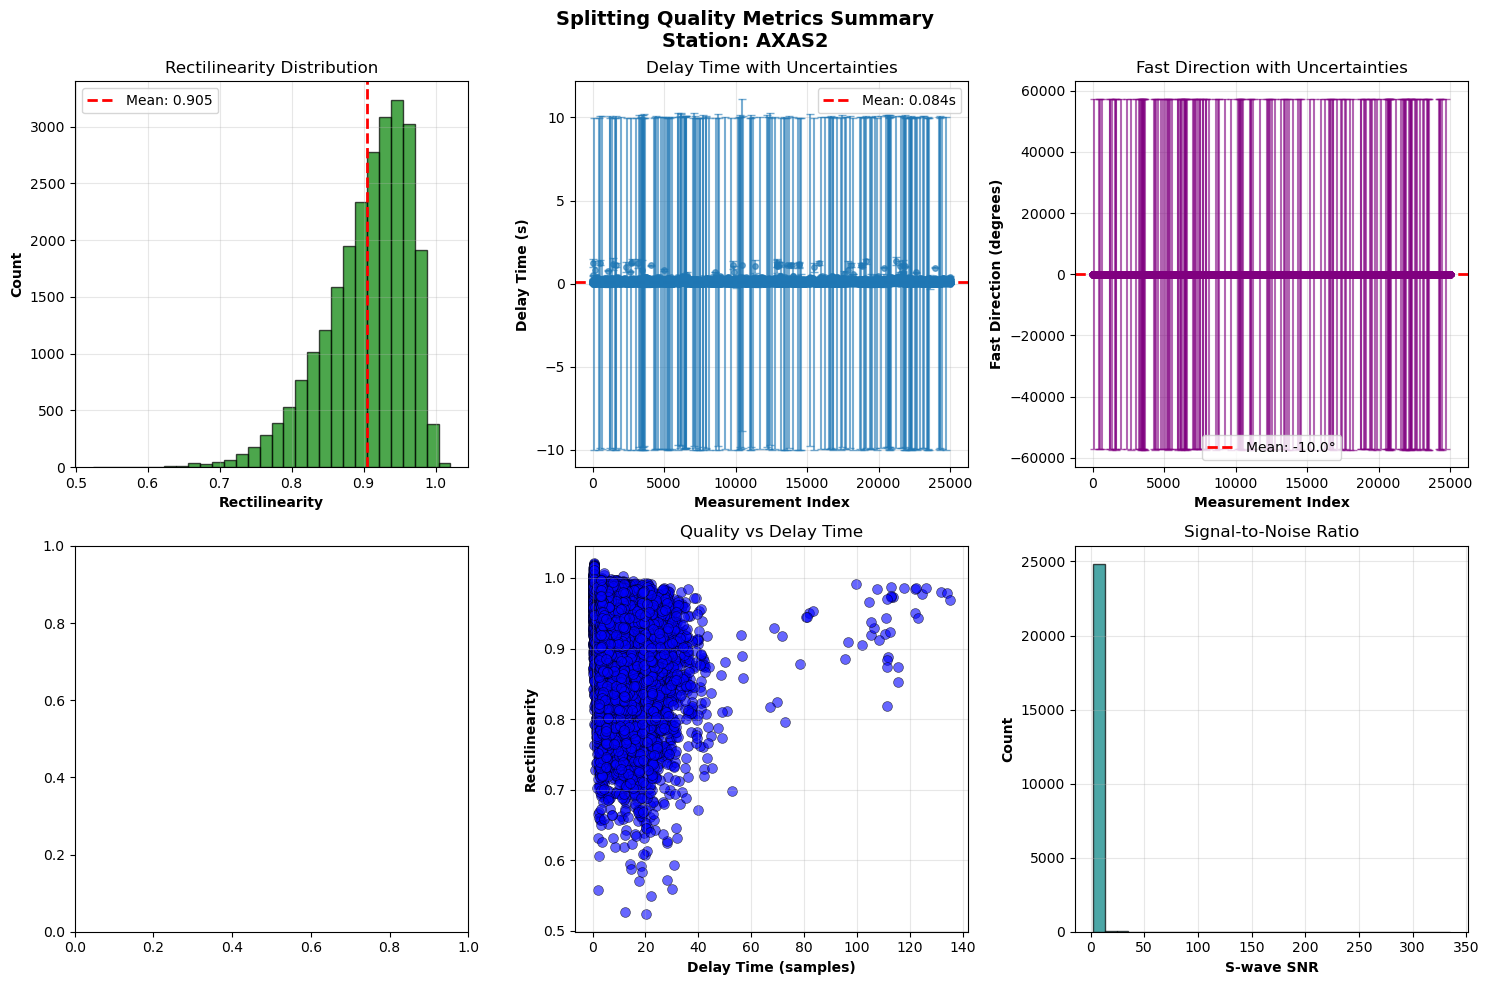

=== Quality Metrics Summary ===

Rectilinearity:
  Mean: 0.905
  Std:  0.060
  High quality (>0.9): 15177 / 25036

Delay Time Uncertainty:
  Mean: 7.53 samples
  Median: 0.99 samples

Fast Direction Uncertainty:
  Mean: 375.7°
  Median: 15.3°


In [ ]:
# Collect quality metrics from all observations
quality_data = {
    'rectilinearity': [],
    'lag': [],
    'lag_error': [],
    'angle': [],
    'angle_error': [],
    'lambda2': [],
    's_snr': []
}

for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        ml = obs.MinLambdas[0]
        
        if hasattr(ml, 'rec'):
            quality_data['rectilinearity'].append(ml.rec)
        if hasattr(ml, 'lag'):
            quality_data['lag'].append(ml.lag)
        if hasattr(ml, 'lag_error'):
            quality_data['lag_error'].append(ml.lag_error)
        if hasattr(ml, 'angle'):
            quality_data['angle'].append(np.degrees(ml.angle))
        if hasattr(ml, 'angle_error'):
            quality_data['angle_error'].append(np.degrees(ml.angle_error))
        if hasattr(ml, 'lambda2'):
            quality_data['lambda2'].append(ml.lambda2)
        if hasattr(obs, 's_snr') and obs.s_snr is not None:
            quality_data['s_snr'].append(obs.s_snr)

# Create comprehensive quality plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1. Rectilinearity distribution
if quality_data['rectilinearity']:
    axes[0].hist(quality_data['rectilinearity'], bins=30, color='green', 
                 alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(quality_data['rectilinearity']), color='red', 
                   linestyle='--', linewidth=2, label=f"Mean: {np.mean(quality_data['rectilinearity']):.3f}")
    axes[0].set_xlabel('Rectilinearity', fontweight='bold')
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].set_title('Rectilinearity Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# 2. Delay time with errors
if quality_data['lag'] and quality_data['lag_error']:
    sampling_rate = 100  # Assume 100 Hz, adjust as needed
    lags_sec = np.array(quality_data['lag']) / sampling_rate
    lag_errors_sec = np.array(quality_data['lag_error']) / sampling_rate
    
    indices = np.arange(len(lags_sec))
    axes[1].errorbar(indices, lags_sec, yerr=lag_errors_sec, fmt='o', 
                    alpha=0.6, capsize=3, markersize=4)
    axes[1].axhline(np.mean(lags_sec), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(lags_sec):.3f}s')
    axes[1].set_xlabel('Measurement Index', fontweight='bold')
    axes[1].set_ylabel('Delay Time (s)', fontweight='bold')
    axes[1].set_title('Delay Time with Uncertainties')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# 3. Fast direction with errors
if quality_data['angle'] and quality_data['angle_error']:
    angles = np.array(quality_data['angle'])
    angle_errors = np.array(quality_data['angle_error'])
    
    indices = np.arange(len(angles))
    axes[2].errorbar(indices, angles, yerr=angle_errors, fmt='o', 
                    alpha=0.6, capsize=3, markersize=4, color='purple')
    axes[2].axhline(np.mean(angles), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(angles):.1f}°')
    axes[2].set_xlabel('Measurement Index', fontweight='bold')
    axes[2].set_ylabel('Fast Direction (degrees)', fontweight='bold')
    axes[2].set_title('Fast Direction with Uncertainties')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

# 4. Lambda2 values
if quality_data['lambda2']:
    axes[3].hist(quality_data['lambda2'], bins=30, color='coral', 
                 alpha=0.7, edgecolor='black')
    axes[3].set_xlabel('λ₂ Value', fontweight='bold')
    axes[3].set_ylabel('Count', fontweight='bold')
    axes[3].set_title('Minimum λ₂ Distribution')
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3)

# 5. Rectilinearity vs Delay Time
if quality_data['rectilinearity'] and quality_data['lag']:
    sc = axes[4].scatter(quality_data['lag'], quality_data['rectilinearity'],
                        c=quality_data['lambda2'] if quality_data['lambda2'] else 'blue',
                        cmap='viridis_r', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[4].set_xlabel('Delay Time (samples)', fontweight='bold')
    axes[4].set_ylabel('Rectilinearity', fontweight='bold')
    axes[4].set_title('Quality vs Delay Time')
    axes[4].grid(True, alpha=0.3)
    if quality_data['lambda2']:
        plt.colorbar(sc, ax=axes[4], label='λ₂')

# 6. SNR distribution (if available)
if quality_data['s_snr']:
    axes[5].hist(quality_data['s_snr'], bins=30, color='teal', 
                 alpha=0.7, edgecolor='black')
    axes[5].set_xlabel('S-wave SNR', fontweight='bold')
    axes[5].set_ylabel('Count', fontweight='bold')
    axes[5].set_title('Signal-to-Noise Ratio')
    axes[5].grid(True, alpha=0.3)
else:
    axes[5].text(0.5, 0.5, 'SNR data not available', 
                ha='center', va='center', transform=axes[5].transAxes,
                fontsize=12)
    axes[5].axis('off')

plt.suptitle(f'Splitting Quality Metrics Summary\nStation: {sws_data[0].station_code if sws_data else "Unknown"}',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Quality Metrics Summary ===")
if quality_data['rectilinearity']:
    print(f"\nRectilinearity:")
    print(f"  Mean: {np.mean(quality_data['rectilinearity']):.3f}")
    print(f"  Std:  {np.std(quality_data['rectilinearity']):.3f}")
    print(f"  High quality (>0.9): {sum(r > 0.9 for r in quality_data['rectilinearity'])} / {len(quality_data['rectilinearity'])}")

if quality_data['lag_error']:
    print(f"\nDelay Time Uncertainty:")
    print(f"  Mean: {np.mean(quality_data['lag_error']):.2f} samples")
    print(f"  Median: {np.median(quality_data['lag_error']):.2f} samples")

if quality_data['angle_error']:
    print(f"\nFast Direction Uncertainty:")
    print(f"  Mean: {np.mean(quality_data['angle_error']):.1f}°")
    print(f"  Median: {np.median(quality_data['angle_error']):.1f}°")

## Summary

This notebook has demonstrated a complete workflow for analyzing shear wave splitting data using the functions developed by @baillard:

### What We've Accomplished:

1. **Data Loading**: Successfully loaded pickled splitting results from `AXAS2.clean.cat.pickle`
2. **Data Exploration**: Examined the structure of `SWSobs` objects and their splitting solutions
3. **Statistical Analysis**: Computed summary statistics for the entire catalog
4. **Waveform Visualization**: Plotted 3-component seismograms with phase markers
5. **Parameter Distributions**: Analyzed fast directions, delay times, and rectilinearity
6. **Advanced Diagnostics**: Created comprehensive diagnostic plots showing:
   - Lambda2 contour maps
   - Particle motion before/after correction
   - Waveform comparisons
7. **Temporal Evolution**: Visualized splitting parameters over time
8. **Rose Diagrams**: Analyzed fast direction distributions with polar histograms
9. **Quality Assessment**: Evaluated measurement quality through multiple metrics

### Key Functions Used from @baillard's Code:

- `shearwavesplit.unsplit()`: Remove splitting from waveforms
- `shearwavesplit.plot_polar_histo()`: Create polar histogram plots
- `shearwavesplit_plot.movehisto2d()`: Time-evolution plots
- `general.plotwaveform.plot_particle_motion()`: Particle motion diagrams
- `general.plotwaveform.plot_patch()`: Highlight S-wave windows

### Next Steps:

- Apply quality filters based on rectilinearity and SNR
- Compare results across multiple stations
- Investigate temporal variations related to volcanic activity
- Export results for publication-quality figures

## 9. Multi-Station Analysis

Now let's process all available station pickle files and create comparative visualizations across the network.

### 9.1 Load All Station Data

First, let's identify and load all available station pickle files.

In [ ]:
# Find all station pickle files
import glob

pickle_files = sorted(glob.glob('../data/*.clean.cat.pickle'))

print(f"Found {len(pickle_files)} station pickle files:\n")

# Load all station data into a dictionary
all_stations_data = {}

for pickle_file in pickle_files:
    station_name = Path(pickle_file).stem.replace('.clean.cat', '')
    
    try:
        with open(pickle_file, 'rb') as f:
            station_data = pickle.load(f)
        
        all_stations_data[station_name] = station_data
        
        print(f"✓ {station_name}: {len(station_data)} observations")
        
    except Exception as e:
        print(f"✗ {station_name}: Failed to load - {e}")

print(f"\n{'='*60}")
print(f"Total stations loaded: {len(all_stations_data)}")
print(f"Total observations: {sum(len(data) for data in all_stations_data.values())}")

Found 7 station pickle files:

✓ AXAS1: 38101 observations
✓ AXAS2: 25036 observations
✓ AXCC1: 8042 observations
✓ AXEC1: 85582 observations
✓ AXEC2: 84682 observations
✓ AXEC3: 75568 observations
✓ AXID1: 11984 observations

Total stations loaded: 7
Total observations: 328995


### 9.2 Process and Add Station Metadata

Add station location information for all stations (required for distance calculations).

In [ ]:
# Add station metadata and calculate distances for all stations
for station_name, station_data in all_stations_data.items():
    print(f"\nProcessing {station_name}...")
    
    processed_count = 0
    for obs in station_data:
        if hasattr(obs, 'station_code'):
            # Get station information from the DataFrame
            station_info = stations_df[stations_df['Station ID'] == obs.station_code]
            
            if not station_info.empty:
                # Add station location
                obs.sta_lat = station_info['Latitude (°N)'].values[0]
                obs.sta_lon = station_info['Longitude (°W)'].values[0]
                obs.sta_z = station_info['Elevation (m)'].values[0]
                
                # Set event location for distance calculation
                if hasattr(obs, 'event_lat') and hasattr(obs, 'event_lon'):
                    obs.ini_lat = obs.event_lat
                    obs.ini_lon = obs.event_lon
                
                # Calculate hypocentral distance
                if (hasattr(obs, 'get_hyp_dist') and 
                    hasattr(obs, 'sta_lon') and hasattr(obs, 'sta_lat') and 
                    hasattr(obs, 'sta_z') and hasattr(obs, 'ini_lon') and 
                    hasattr(obs, 'ini_lat')):
                    obs.get_hyp_dist(obs.sta_lon, obs.sta_lat, obs.sta_z, 
                                   obs.ini_lon, obs.ini_lat)
                    processed_count += 1
    
    print(f"  ✓ Processed {processed_count} observations")

print("\n" + "="*60)
print("All stations processed successfully!")


Processing AXAS1...
  ✓ Processed 38101 observations

Processing AXAS2...
  ✓ Processed 25036 observations

Processing AXCC1...
  ✓ Processed 8042 observations

Processing AXEC1...
  ✓ Processed 85582 observations

Processing AXEC2...
  ✓ Processed 84682 observations

Processing AXEC3...
  ✓ Processed 75568 observations

Processing AXID1...
  ✓ Processed 11984 observations

All stations processed successfully!


### 9.3 Summary Statistics for All Stations

Generate comprehensive statistics for each station.

In [ ]:
# Collect statistics for each station
station_stats = {}

for station_name, station_data in all_stations_data.items():
    stats = {
        'n_obs': len(station_data),
        'fast_directions': [],
        'delay_times': [],
        'rectilinearities': [],
        'depths': [],
        'hyp_dists': []
    }
    
    for obs in station_data:
        if hasattr(obs, 'event_depth') and obs.event_depth is not None:
            stats['depths'].append(obs.event_depth)
        
        if hasattr(obs, 'hyp_dist') and obs.hyp_dist is not None:
            stats['hyp_dists'].append(obs.hyp_dist)
        
        if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
            ml = obs.MinLambdas[0]
            
            if hasattr(ml, 'angle'):
                stats['fast_directions'].append(np.degrees(ml.angle))
            if hasattr(ml, 'lag'):
                stats['delay_times'].append(ml.lag)
            if hasattr(ml, 'rec'):
                stats['rectilinearities'].append(ml.rec)
    
    station_stats[station_name] = stats

# Display statistics
print("=" * 80)
print(f"{'Station':<10} {'N obs':<8} {'Mean φ (°)':<12} {'Mean δt':<10} {'Mean Rect':<12} {'Mean Depth':<12}")
print("=" * 80)

for station_name, stats in sorted(station_stats.items()):
    mean_phi = np.mean(stats['fast_directions']) if stats['fast_directions'] else np.nan
    mean_lag = np.mean(stats['delay_times']) if stats['delay_times'] else np.nan
    mean_rec = np.mean(stats['rectilinearities']) if stats['rectilinearities'] else np.nan
    mean_depth = np.mean(stats['depths']) if stats['depths'] else np.nan
    
    print(f"{station_name:<10} {stats['n_obs']:<8} {mean_phi:<12.1f} "
          f"{mean_lag:<10.2f} {mean_rec:<12.3f} {mean_depth:<12.2f}")

print("=" * 80)

Station    N obs    Mean φ (°)   Mean δt    Mean Rect    Mean Depth  
AXAS1      38101    -12.7        13.32      0.902        1.01        
AXAS2      25036    -10.0        8.40       0.905        0.98        
AXCC1      8042     -6.8         10.77      0.965        0.90        
AXEC1      85582    -6.2         8.41       0.940        0.95        
AXEC2      84682    -5.7         8.05       0.935        0.93        
AXEC3      75568    -0.2         8.48       0.949        0.95        
AXID1      11984    11.0         11.01      0.890        1.11        


### 9.4 Multi-Station Rose Plots

Create polar histograms (rose plots) for all stations to compare fast direction patterns.

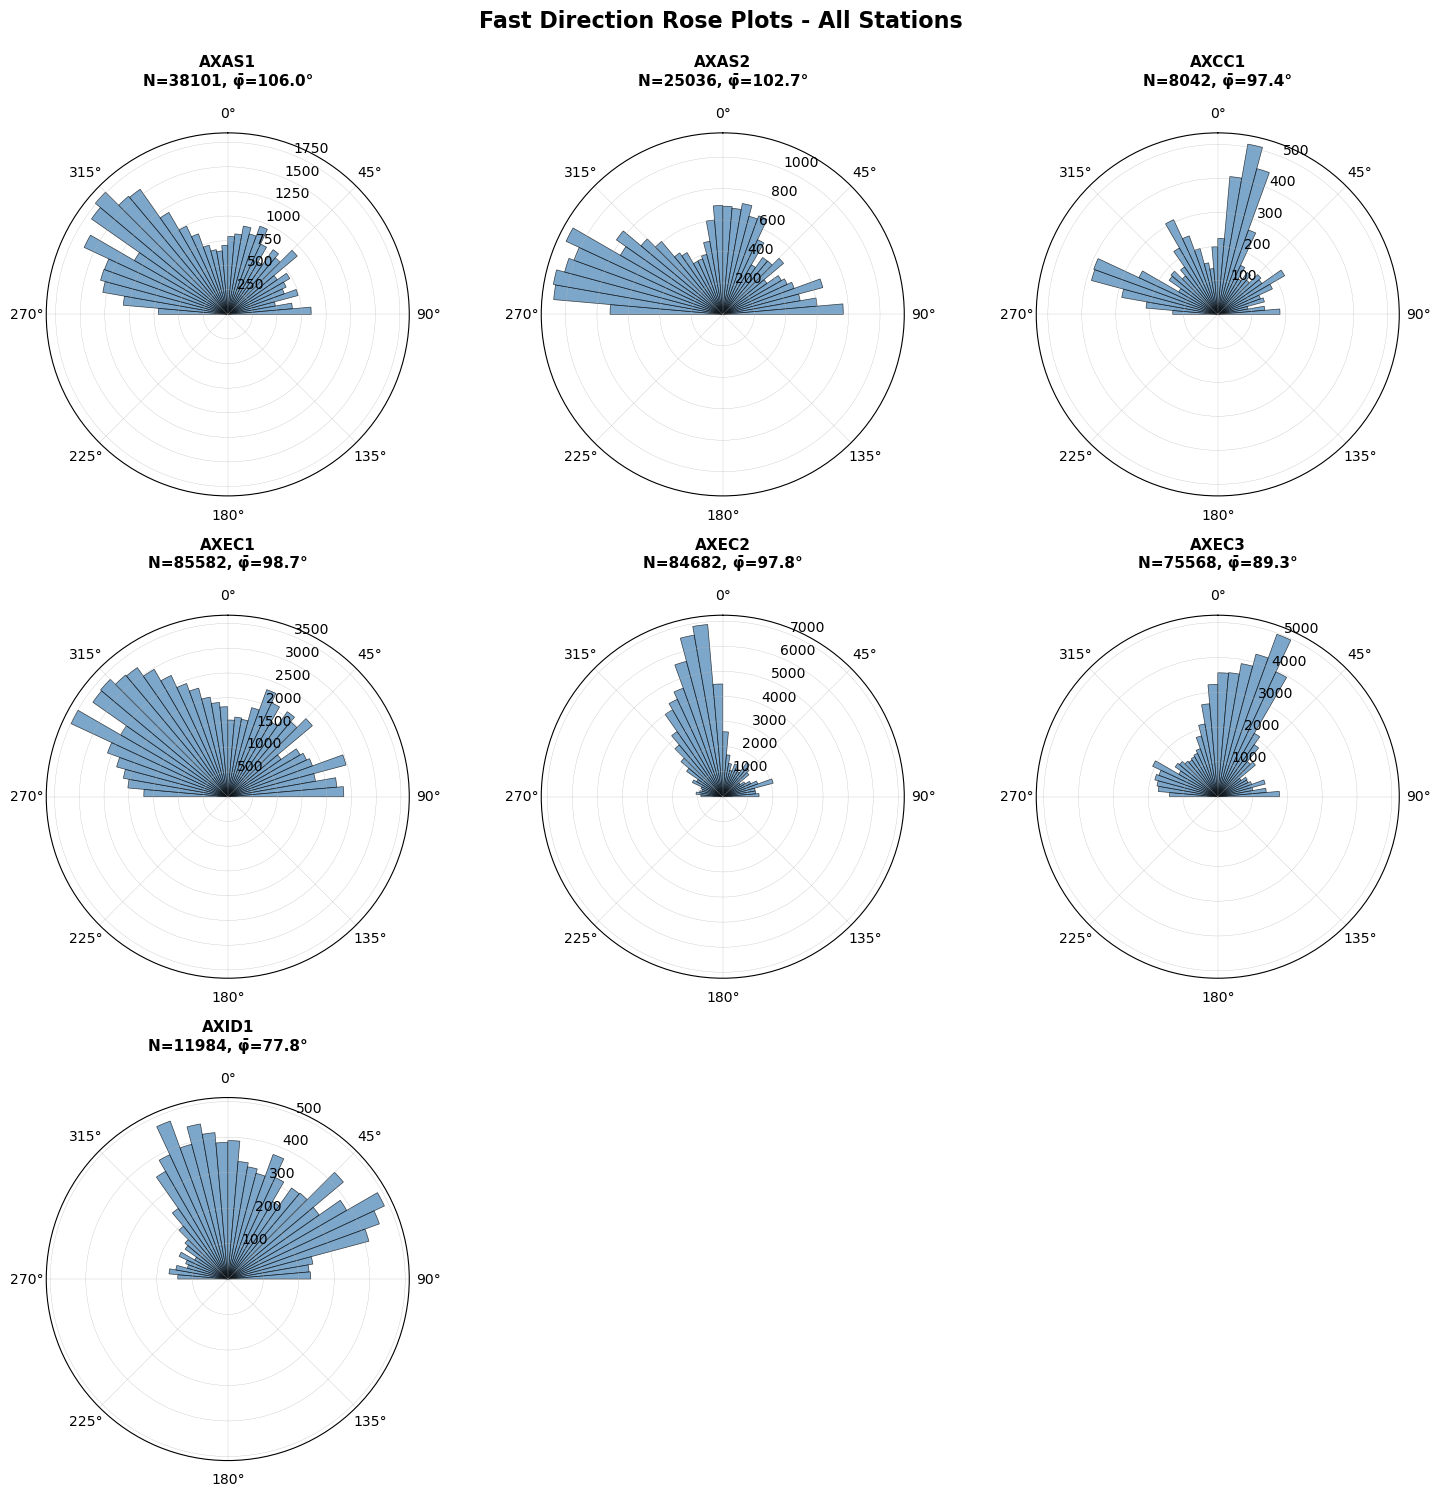


✓ Rose plots created for all stations


In [ ]:
# Create multi-panel rose plot for all stations
n_stations = len(all_stations_data)
n_cols = 3
n_rows = int(np.ceil(n_stations / n_cols))

fig = plt.figure(figsize=(15, 5 * n_rows))

for idx, (station_name, station_data) in enumerate(sorted(all_stations_data.items())):
    # Extract fast directions and weights
    fast_angles_rad = []
    weights = []
    
    for obs in station_data:
        if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
            ml = obs.MinLambdas[0]
            if hasattr(ml, 'angle'):
                fast_angles_rad.append(ml.angle)
                if hasattr(ml, 'rec'):
                    weights.append(ml.rec)
                else:
                    weights.append(1.0)
    
    if len(fast_angles_rad) > 0:
        # Create polar subplot
        ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='polar')
        
        # Plot rose diagram
        sws.plot_polar_histo(
            trigo_angles=fast_angles_rad,
            weights=weights,
            width_bin_deg=5,
            ax_polar=ax,
            facecolor='steelblue',
            edgecolor='black',
            lw=0.5,
            alpha=0.7,
            text=False
        )
        
        # Set 0 degrees to North
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)  # Clockwise
        
        # Calculate mean direction
        mean_angle = np.arctan2(np.mean(np.sin(fast_angles_rad)), 
                               np.mean(np.cos(fast_angles_rad)))
        mean_angle_deg = np.degrees(mean_angle)
        if mean_angle_deg < 0:
            mean_angle_deg += 360
        
        # Add title with statistics
        ax.set_title(f'{station_name}\nN={len(fast_angles_rad)}, '
                    f'φ̄={(90 - mean_angle_deg) % 360:.1f}°',
                    fontsize=11, fontweight='bold', pad=15)
    else:
        # Empty subplot
        ax = fig.add_subplot(n_rows, n_cols, idx + 1)
        ax.text(0.5, 0.5, f'{station_name}\nNo data', 
               ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Fast Direction Rose Plots - All Stations', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Rose plots created for all stations")

### 9.5 Comparison of Splitting Parameters Across Stations

Create comparative histograms showing the distribution of splitting parameters for all stations.

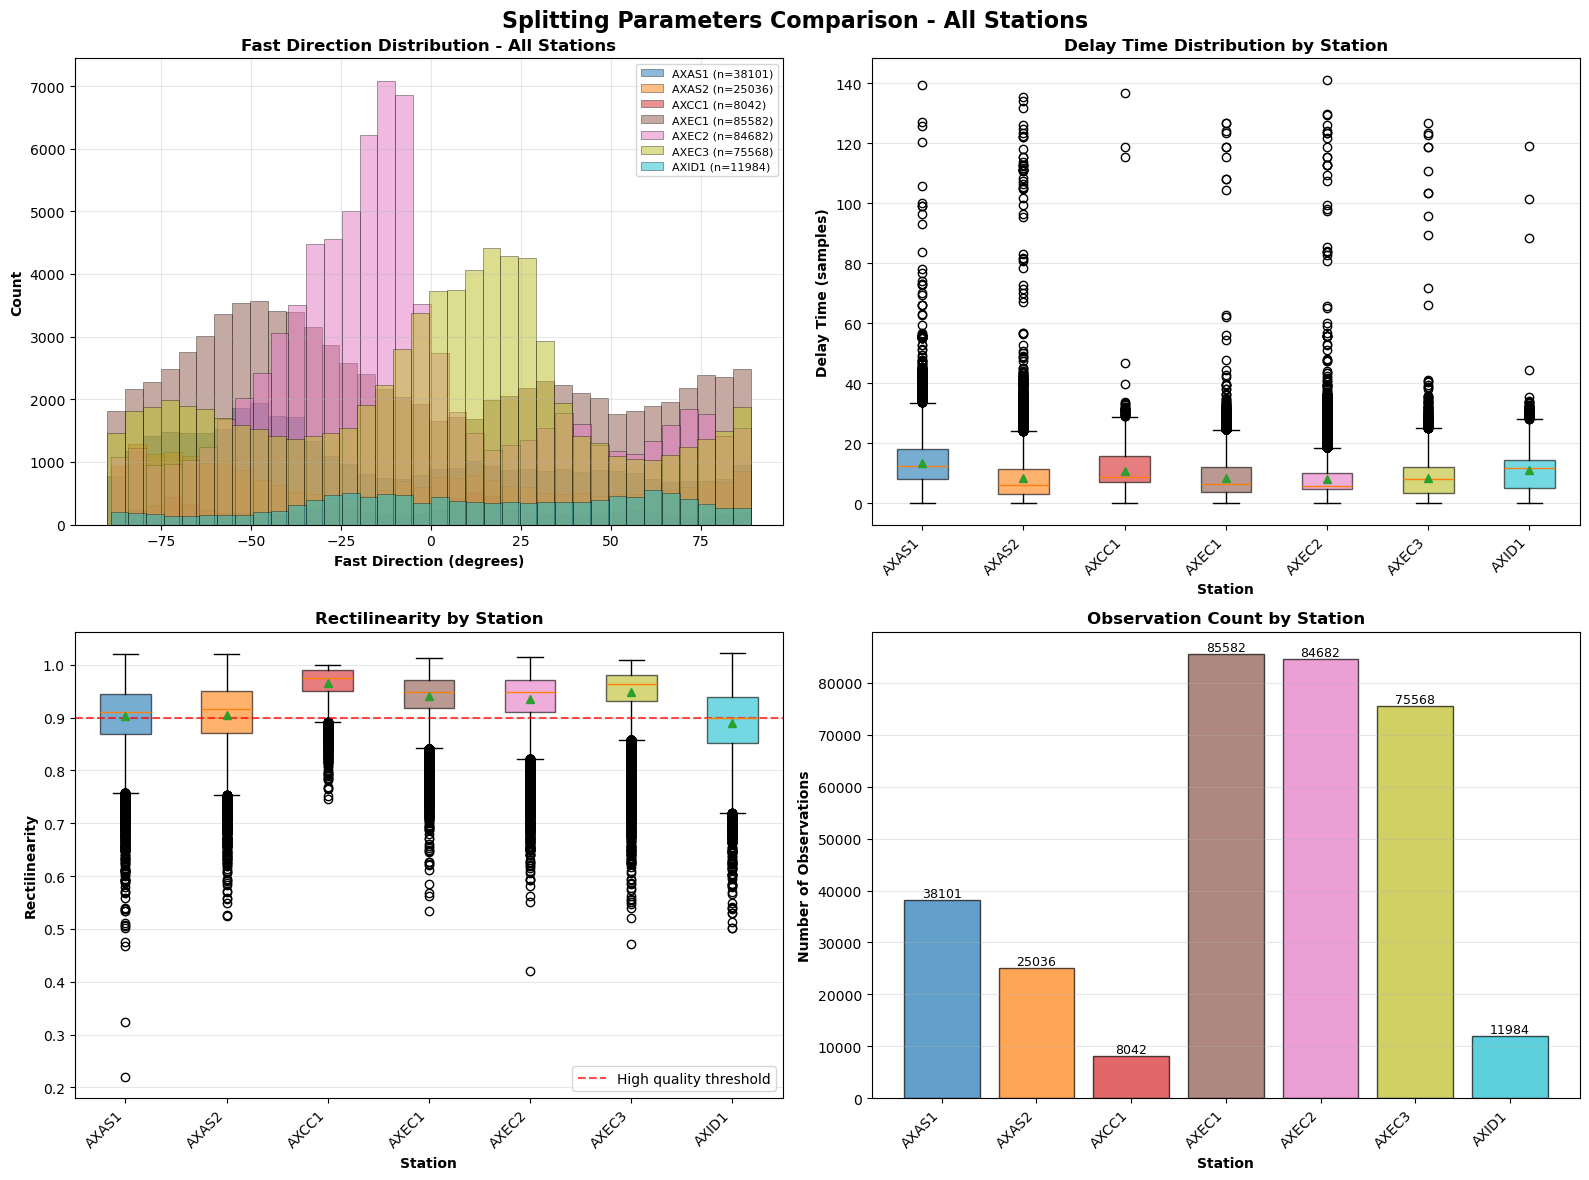


✓ Comparison plots created


In [ ]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for all stations
all_stations = sorted(all_stations_data.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(all_stations)))

# 1. Fast Direction distributions (overlapping histograms)
ax = axes[0, 0]
for idx, (station_name, stats) in enumerate(sorted(station_stats.items())):
    if stats['fast_directions']:
        ax.hist(stats['fast_directions'], bins=36, alpha=0.5, 
               label=f"{station_name} (n={len(stats['fast_directions'])})",
               color=colors[idx], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Fast Direction (degrees)', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Fast Direction Distribution - All Stations', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Delay Time box plots
ax = axes[0, 1]
delay_time_data = [stats['delay_times'] for _, stats in sorted(station_stats.items()) 
                   if stats['delay_times']]
positions = range(1, len(delay_time_data) + 1)
station_labels = [name for name, stats in sorted(station_stats.items()) 
                 if stats['delay_times']]

bp = ax.boxplot(delay_time_data, positions=positions, labels=station_labels,
                patch_artist=True, showmeans=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xlabel('Station', fontweight='bold')
ax.set_ylabel('Delay Time (samples)', fontweight='bold')
ax.set_title('Delay Time Distribution by Station', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Rectilinearity box plots
ax = axes[1, 0]
rect_data = [stats['rectilinearities'] for _, stats in sorted(station_stats.items()) 
             if stats['rectilinearities']]
positions = range(1, len(rect_data) + 1)
station_labels = [name for name, stats in sorted(station_stats.items()) 
                 if stats['rectilinearities']]

bp = ax.boxplot(rect_data, positions=positions, labels=station_labels,
                patch_artist=True, showmeans=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xlabel('Station', fontweight='bold')
ax.set_ylabel('Rectilinearity', fontweight='bold')
ax.set_title('Rectilinearity by Station', fontweight='bold')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='High quality threshold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Number of observations per station
ax = axes[1, 1]
station_names = [name for name, stats in sorted(station_stats.items())]
obs_counts = [stats['n_obs'] for _, stats in sorted(station_stats.items())]

bars = ax.bar(range(len(station_names)), obs_counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(station_names)))
ax.set_xticklabels(station_names, rotation=45, ha='right')
ax.set_xlabel('Station', fontweight='bold')
ax.set_ylabel('Number of Observations', fontweight='bold')
ax.set_title('Observation Count by Station', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, obs_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{count}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Splitting Parameters Comparison - All Stations',
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Comparison plots created")

### 9.6 Time Evolution for All Stations

Create time evolution plots showing how splitting parameters vary over time for each station.

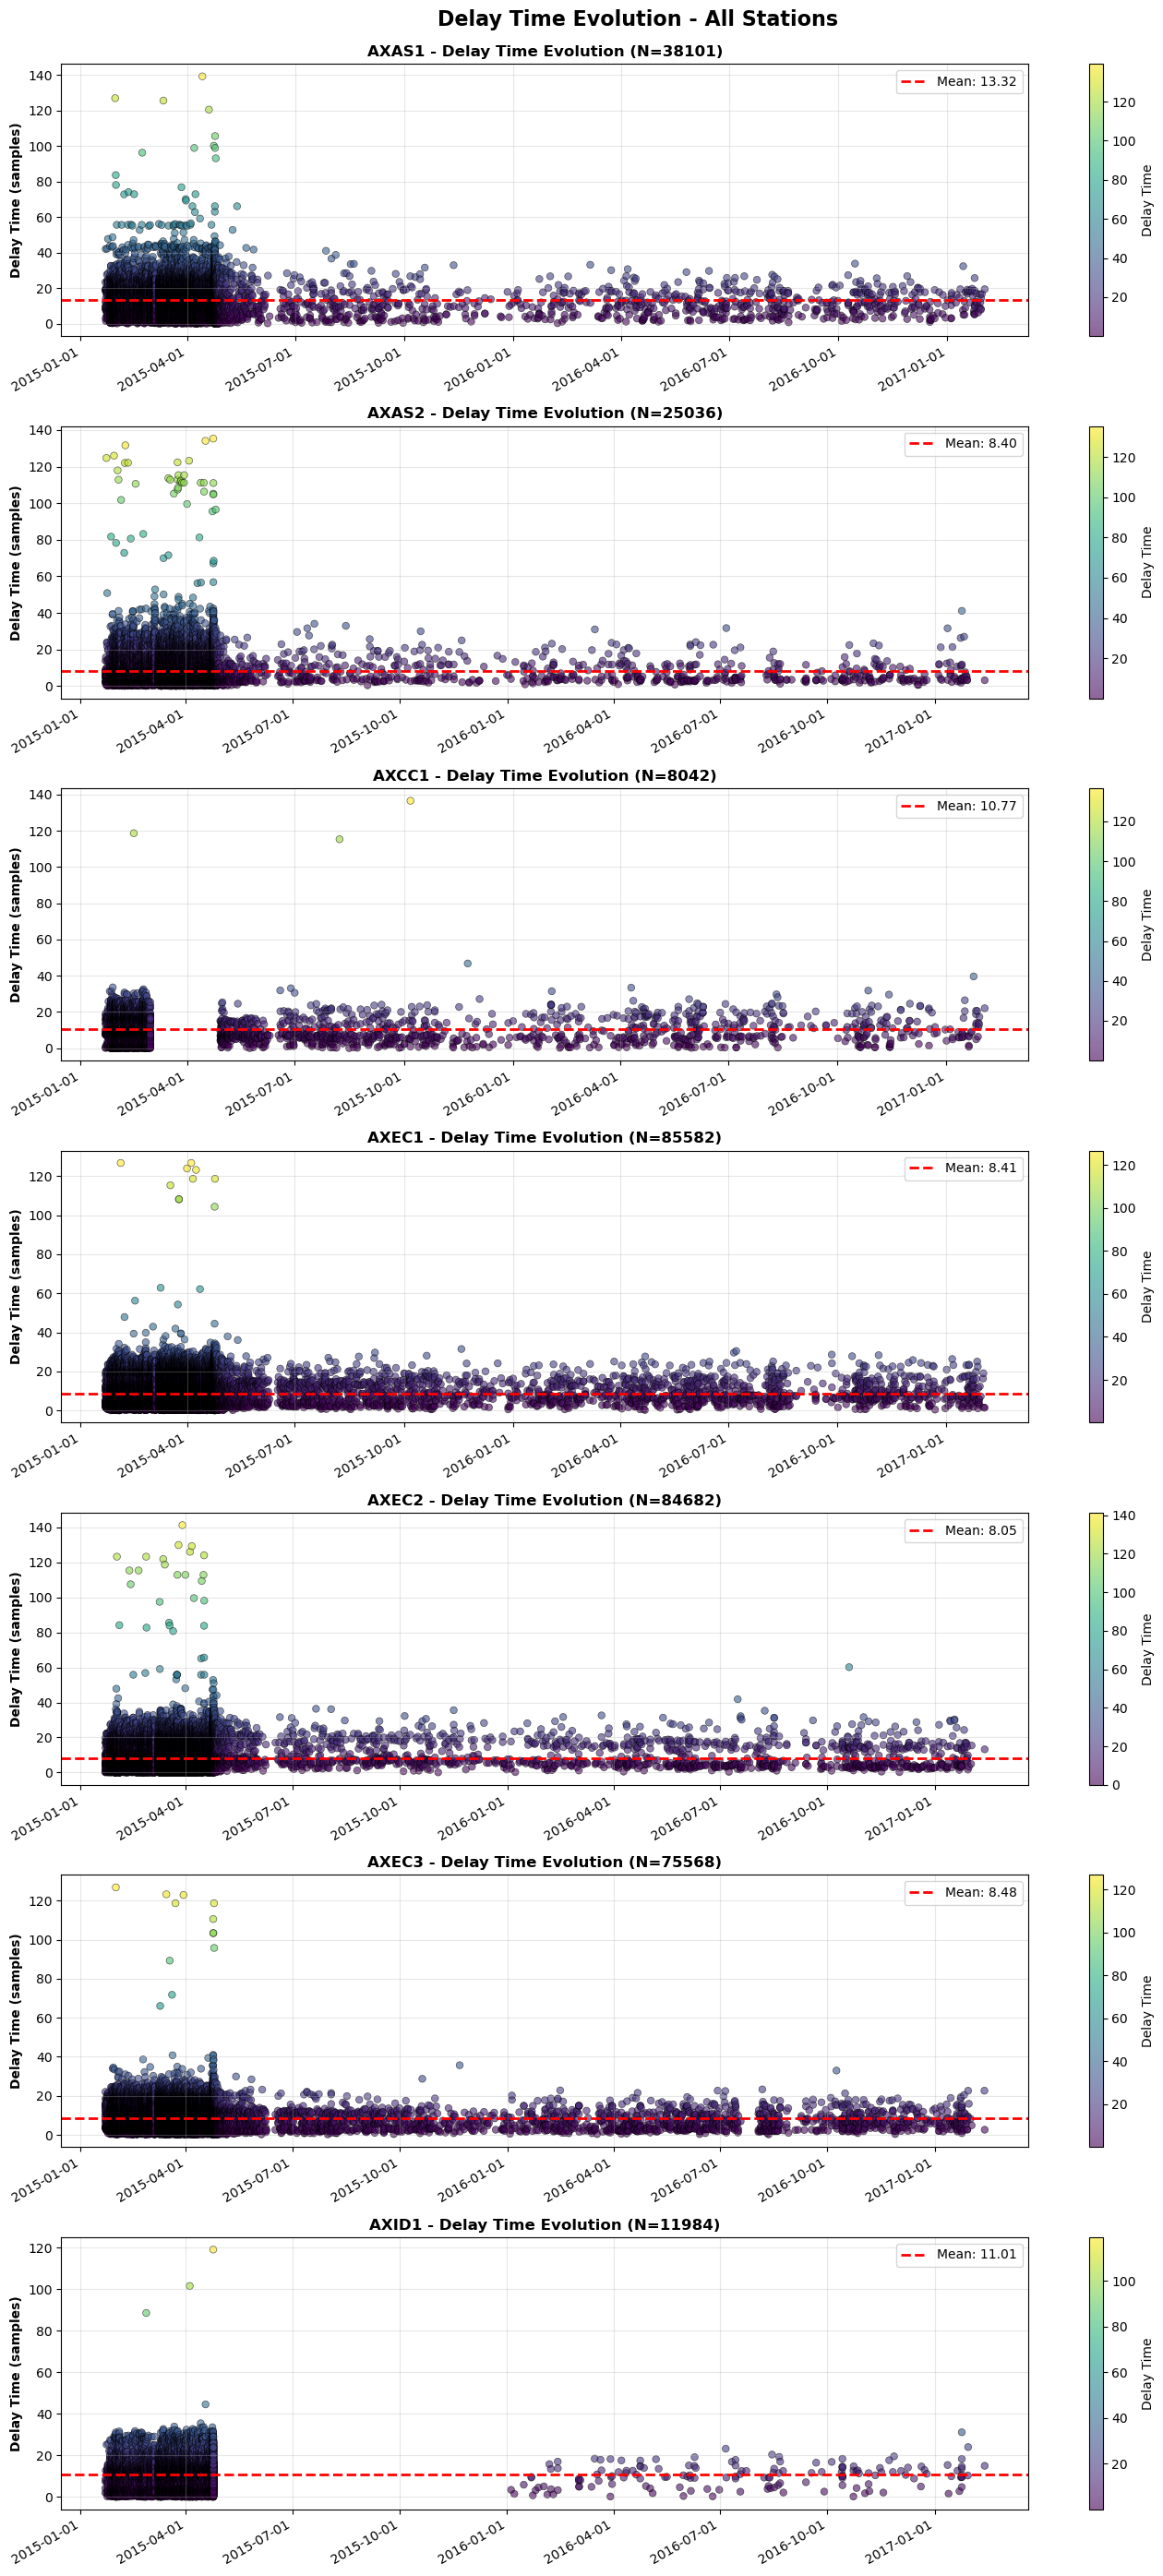


✓ Time evolution plots created


In [ ]:
# Create time evolution plots for stations with sufficient data
from shearwavesplit_plot import movehisto2d

fig, axes = plt.subplots(len(all_stations_data), 1, figsize=(14, 4 * len(all_stations_data)))

if len(all_stations_data) == 1:
    axes = [axes]

for idx, (station_name, station_data) in enumerate(sorted(all_stations_data.items())):
    # Extract time and lag data
    times = []
    lags = []
    
    for obs in station_data:
        if hasattr(obs, 's_time') and hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
            times.append(obs.s_time)
            lags.append(obs.MinLambdas[0].lag)
    
    ax = axes[idx]
    
    if len(times) > 10:  # Need enough data points
        # Create scatter plot on the axes
        time_numeric = [t.matplotlib_date for t in times]
        
        sc = ax.scatter(time_numeric, lags, c=lags, cmap='viridis', 
                       alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        
        # Format x-axis for dates
        import matplotlib.dates as mdates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        
        ax.set_ylabel('Delay Time (samples)', fontweight='bold')
        ax.set_title(f'{station_name} - Delay Time Evolution (N={len(times)})', 
                    fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add colorbar
        plt.colorbar(sc, ax=ax, label='Delay Time')
        
        # Add mean line
        mean_lag = np.mean(lags)
        ax.axhline(mean_lag, color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_lag:.2f}')
        ax.legend(loc='upper right')
        
    else:
        ax.text(0.5, 0.5, f'{station_name}\nInsufficient data (N={len(times)})',
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')

plt.suptitle('Delay Time Evolution - All Stations',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Time evolution plots created")

### 9.7 Combined Network Statistics

Analyze the combined dataset from all stations to identify network-wide patterns.

In [ ]:
# Combine all data from all stations
network_data = {
    'fast_directions': [],
    'delay_times': [],
    'rectilinearities': [],
    'stations': [],
    'depths': [],
    'hyp_dists': []
}

for station_name, station_data in all_stations_data.items():
    for obs in station_data:
        if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
            ml = obs.MinLambdas[0]
            
            if hasattr(ml, 'angle'):
                network_data['fast_directions'].append(np.degrees(ml.angle))
                network_data['stations'].append(station_name)
                
                if hasattr(ml, 'lag'):
                    network_data['delay_times'].append(ml.lag)
                if hasattr(ml, 'rec'):
                    network_data['rectilinearities'].append(ml.rec)
                if hasattr(obs, 'event_depth'):
                    network_data['depths'].append(obs.event_depth)
                if hasattr(obs, 'hyp_dist'):
                    network_data['hyp_dists'].append(obs.hyp_dist)

# Print network-wide statistics
print("=" * 80)
print("NETWORK-WIDE SPLITTING STATISTICS")
print("=" * 80)
print(f"\nTotal number of measurements: {len(network_data['fast_directions'])}")
print(f"Number of stations: {len(all_stations_data)}")

if network_data['fast_directions']:
    print(f"\nFast Direction:")
    print(f"  Mean: {np.mean(network_data['fast_directions']):.1f}°")
    print(f"  Median: {np.median(network_data['fast_directions']):.1f}°")
    print(f"  Std: {np.std(network_data['fast_directions']):.1f}°")
    print(f"  Range: [{min(network_data['fast_directions']):.1f}°, {max(network_data['fast_directions']):.1f}°]")

if network_data['delay_times']:
    print(f"\nDelay Time:")
    print(f"  Mean: {np.mean(network_data['delay_times']):.2f} samples")
    print(f"  Median: {np.median(network_data['delay_times']):.2f} samples")
    print(f"  Std: {np.std(network_data['delay_times']):.2f} samples")
    print(f"  Range: [{min(network_data['delay_times']):.2f}, {max(network_data['delay_times']):.2f}] samples")

if network_data['rectilinearities']:
    print(f"\nRectilinearity:")
    print(f"  Mean: {np.mean(network_data['rectilinearities']):.3f}")
    print(f"  Median: {np.median(network_data['rectilinearities']):.3f}")
    print(f"  High quality (>0.9): {sum(r > 0.9 for r in network_data['rectilinearities'])} "
          f"({100*sum(r > 0.9 for r in network_data['rectilinearities'])/len(network_data['rectilinearities']):.1f}%)")

if network_data['depths']:
    print(f"\nEvent Depths:")
    print(f"  Mean: {np.mean(network_data['depths']):.2f} km")
    print(f"  Median: {np.median(network_data['depths']):.2f} km")
    print(f"  Range: [{min(network_data['depths']):.2f}, {max(network_data['depths']):.2f}] km")

if network_data['hyp_dists']:
    print(f"\nHypocentral Distances:")
    print(f"  Mean: {np.mean(network_data['hyp_dists']):.2f} km")
    print(f"  Median: {np.median(network_data['hyp_dists']):.2f} km")
    print(f"  Range: [{min(network_data['hyp_dists']):.2f}, {max(network_data['hyp_dists']):.2f}] km")

print("\n" + "=" * 80)

NETWORK-WIDE SPLITTING STATISTICS

Total number of measurements: 328995
Number of stations: 7

Fast Direction:
  Mean: -5.1°
  Median: -9.0°
  Std: 48.0°
  Range: [-90.0°, 89.0°]

Delay Time:
  Mean: 9.05 samples
  Median: 7.35 samples
  Std: 6.54 samples
  Range: [-0.03, 141.21] samples

Rectilinearity:
  Mean: 0.933
  Median: 0.946
  High quality (>0.9): 256999 (78.1%)

Event Depths:
  Mean: 0.96 km
  Median: 0.86 km
  Range: [0.01, 3.99] km

Hypocentral Distances:
  Mean: 1519.06 km
  Median: 1519.57 km
  Range: [1512.01, 1523.05] km



### 9.8 Network-Wide Rose Plot

Create a combined rose plot showing the overall fast direction pattern for the entire network.

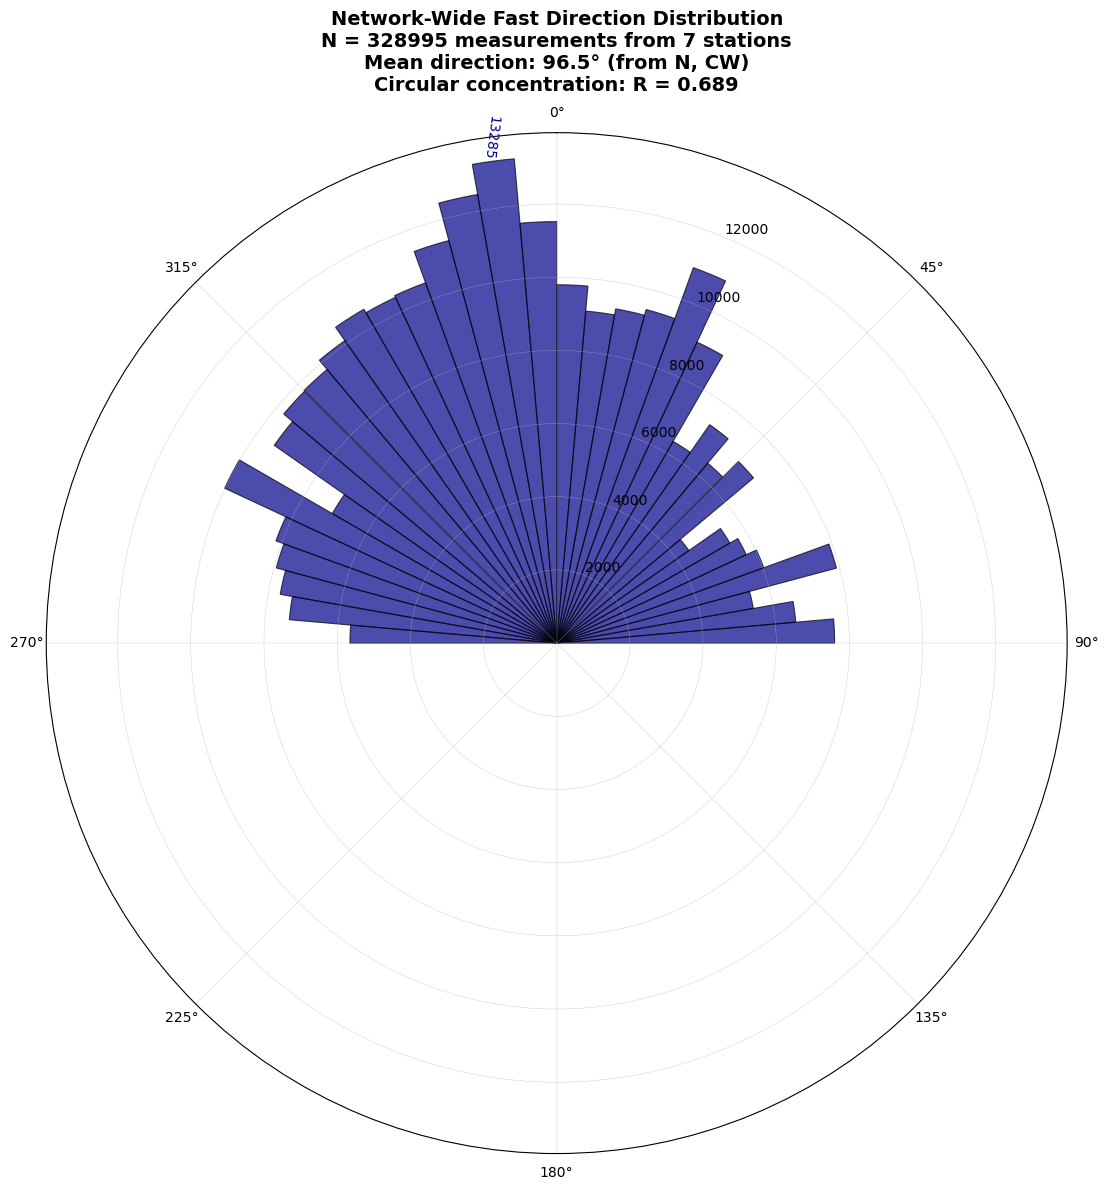


✓ Network-wide rose plot created
   Mean fast direction: 96.5° (from North, clockwise)
   Circular concentration (R): 0.689


In [ ]:
# Create combined network rose plot
if network_data['fast_directions']:
    # Convert degrees to radians for trigonometric convention
    fast_angles_rad_network = [np.radians(angle) for angle in network_data['fast_directions']]
    
    fig = plt.figure(figsize=(12, 12))
    ax_polar = fig.add_subplot(111, projection='polar')
    
    # Use rectilinearity as weights
    weights_network = network_data['rectilinearities'] if network_data['rectilinearities'] else None
    
    # Plot rose diagram
    sws.plot_polar_histo(
        trigo_angles=fast_angles_rad_network,
        weights=weights_network,
        width_bin_deg=5,
        ax_polar=ax_polar,
        facecolor='darkblue',
        edgecolor='black',
        lw=0.8,
        alpha=0.7,
        text=True
    )
    
    # Set 0 degrees to North
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)  # Clockwise
    
    # Calculate mean direction
    mean_angle = np.arctan2(np.mean(np.sin(fast_angles_rad_network)), 
                           np.mean(np.cos(fast_angles_rad_network)))
    mean_angle_deg = np.degrees(mean_angle)
    if mean_angle_deg < 0:
        mean_angle_deg += 360
    
    # Convert to azimuth (from North, clockwise)
    azimuth = (90 - mean_angle_deg) % 360
    
    # Calculate circular statistics
    R = np.sqrt(np.mean(np.sin(fast_angles_rad_network))**2 + 
                np.mean(np.cos(fast_angles_rad_network))**2)
    
    # Add title
    ax_polar.set_title(f'Network-Wide Fast Direction Distribution\n'
                      f'N = {len(fast_angles_rad_network)} measurements from {len(all_stations_data)} stations\n'
                      f'Mean direction: {azimuth:.1f}° (from N, clockwise)\n'
                      f'Circular concentration: R = {R:.3f}',
                      fontsize=14, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Network-wide rose plot created")
    print(f"   Mean fast direction: {azimuth:.1f}° (from North, clockwise)")
    print(f"   Circular concentration (R): {R:.3f}")
else:
    print("⚠ No fast direction data available for network plot")

### 9.9 Export Combined Results

Export all station results to a comprehensive CSV file for further analysis.

In [ ]:
# Create comprehensive DataFrame with all station results
import pandas as pd

results_list = []

for station_name, station_data in all_stations_data.items():
    for obs in station_data:
        if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
            ml = obs.MinLambdas[0]
            
            result = {
                'station': station_name,
                'obs_id': obs.obs_id if hasattr(obs, 'obs_id') else None,
                'event_lon': obs.event_lon if hasattr(obs, 'event_lon') else None,
                'event_lat': obs.event_lat if hasattr(obs, 'event_lat') else None,
                'event_depth_km': obs.event_depth if hasattr(obs, 'event_depth') else None,
                's_time': str(obs.s_time) if hasattr(obs, 's_time') else None,
                'hyp_dist_km': obs.hyp_dist if hasattr(obs, 'hyp_dist') else None,
                'fast_direction_deg': np.degrees(ml.angle) if hasattr(ml, 'angle') else None,
                'delay_time_samples': ml.lag if hasattr(ml, 'lag') else None,
                'rectilinearity': ml.rec if hasattr(ml, 'rec') else None,
                'lambda2': ml.lambda2 if hasattr(ml, 'lambda2') else None,
                'lag_error_samples': ml.lag_error if hasattr(ml, 'lag_error') else None,
                'angle_error_deg': np.degrees(ml.angle_error) if hasattr(ml, 'angle_error') else None,
                's_snr': obs.s_snr if hasattr(obs, 's_snr') else None
            }
            
            results_list.append(result)

# Create DataFrame
results_df = pd.DataFrame(results_list)

# Add azimuth (from North, clockwise) for easier interpretation
if 'fast_direction_deg' in results_df.columns:
    results_df['azimuth_from_north_deg'] = (90 - results_df['fast_direction_deg']) % 360

# Sort by station and time
results_df = results_df.sort_values(['station', 's_time'])

# Save to CSV
output_file = '../results/all_stations_splitting_results.csv'
results_df.to_csv(output_file, index=False)

print(f"✓ Results exported to: {output_file}")
print(f"\nDataFrame shape: {results_df.shape}")
print(f"\nFirst few rows:")
print(results_df.head(10))

# Print summary by station
print("\n" + "="*80)
print("RESULTS SUMMARY BY STATION")
print("="*80)
print(results_df.groupby('station').agg({
    'obs_id': 'count',
    'fast_direction_deg': 'mean',
    'delay_time_samples': 'mean',
    'rectilinearity': 'mean',
    'hyp_dist_km': 'mean'
}).round(2).rename(columns={'obs_id': 'n_measurements'}))

✓ Results exported to: ../results/all_stations_splitting_results.csv

DataFrame shape: (328995, 15)

First few rows:
  station                 obs_id   event_lon  event_lat  event_depth_km  \
0   AXAS1  AXAS1_20150122_025941 -129.990534  45.942963         0.35625   
1   AXAS1  AXAS1_20150122_033741 -130.017822  45.944162         1.01250   
2   AXAS1  AXAS1_20150122_044504 -130.012451  45.940847         0.40625   
3   AXAS1  AXAS1_20150122_045643 -130.020778  45.934639         1.43125   
4   AXAS1  AXAS1_20150122_054529 -130.021181  45.936896         1.30625   
5   AXAS1  AXAS1_20150122_075055 -130.018949  45.936755         1.09375   
6   AXAS1  AXAS1_20150122_080459 -129.983866  45.929559         0.53125   
7   AXAS1  AXAS1_20150122_090912 -129.983039  45.937037         1.35625   
8   AXAS1  AXAS1_20150122_101532 -130.018534  45.943386         1.00625   
9   AXAS1  AXAS1_20150122_103431 -130.019753  45.941975         1.19375   

                        s_time  hyp_dist_km  fast_directi

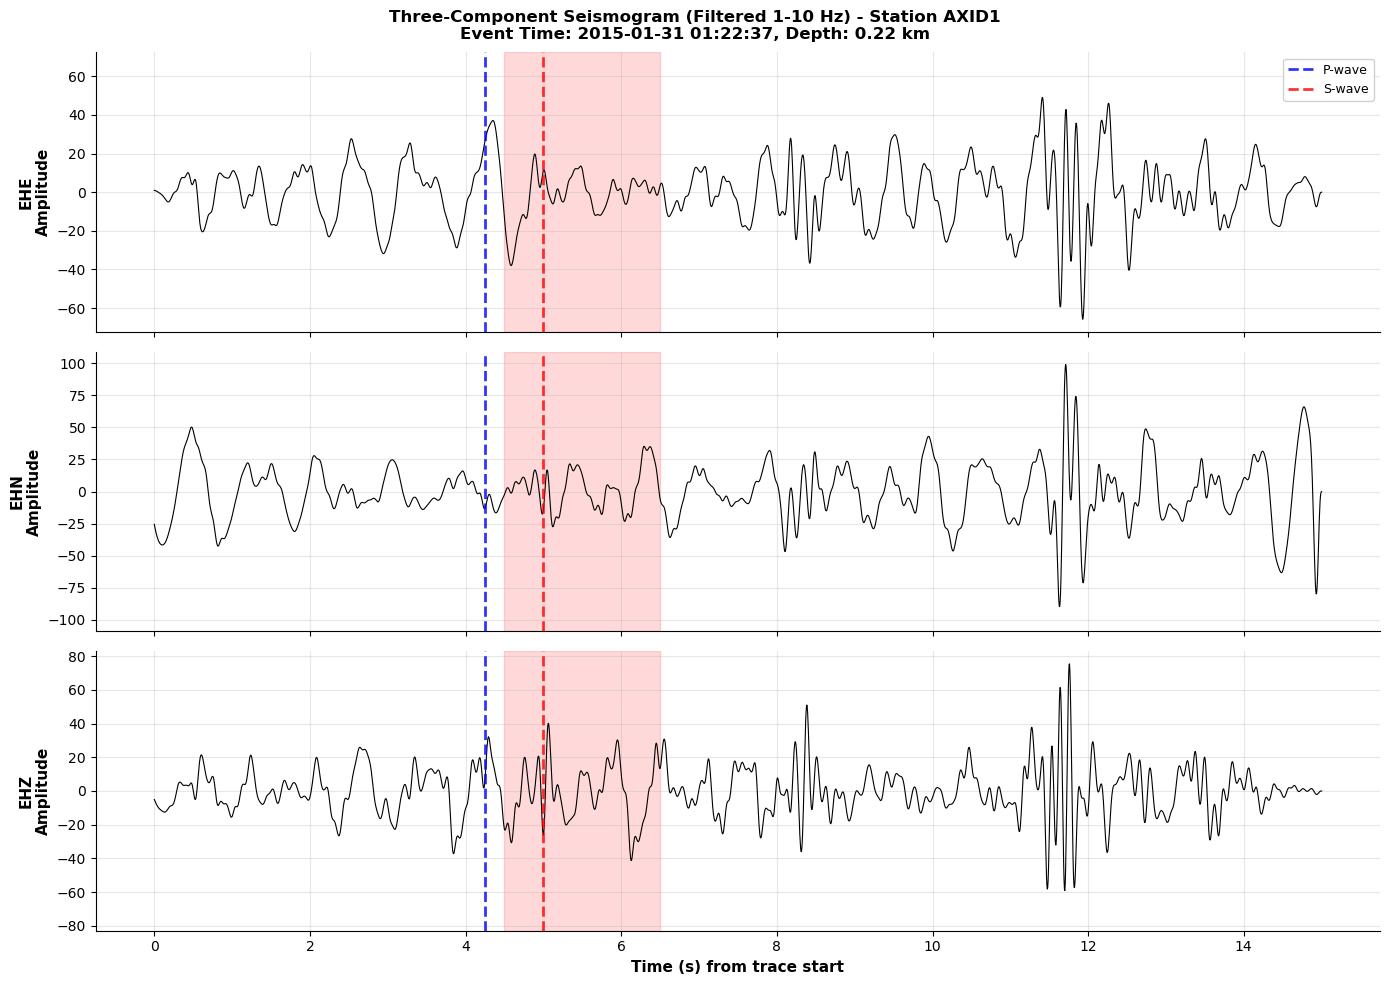

Station: AXID1, Time: 2015-01-31T01:22:37.005000Z
  P-arrival at: 4.25 s
  S-arrival at: 5.00 s



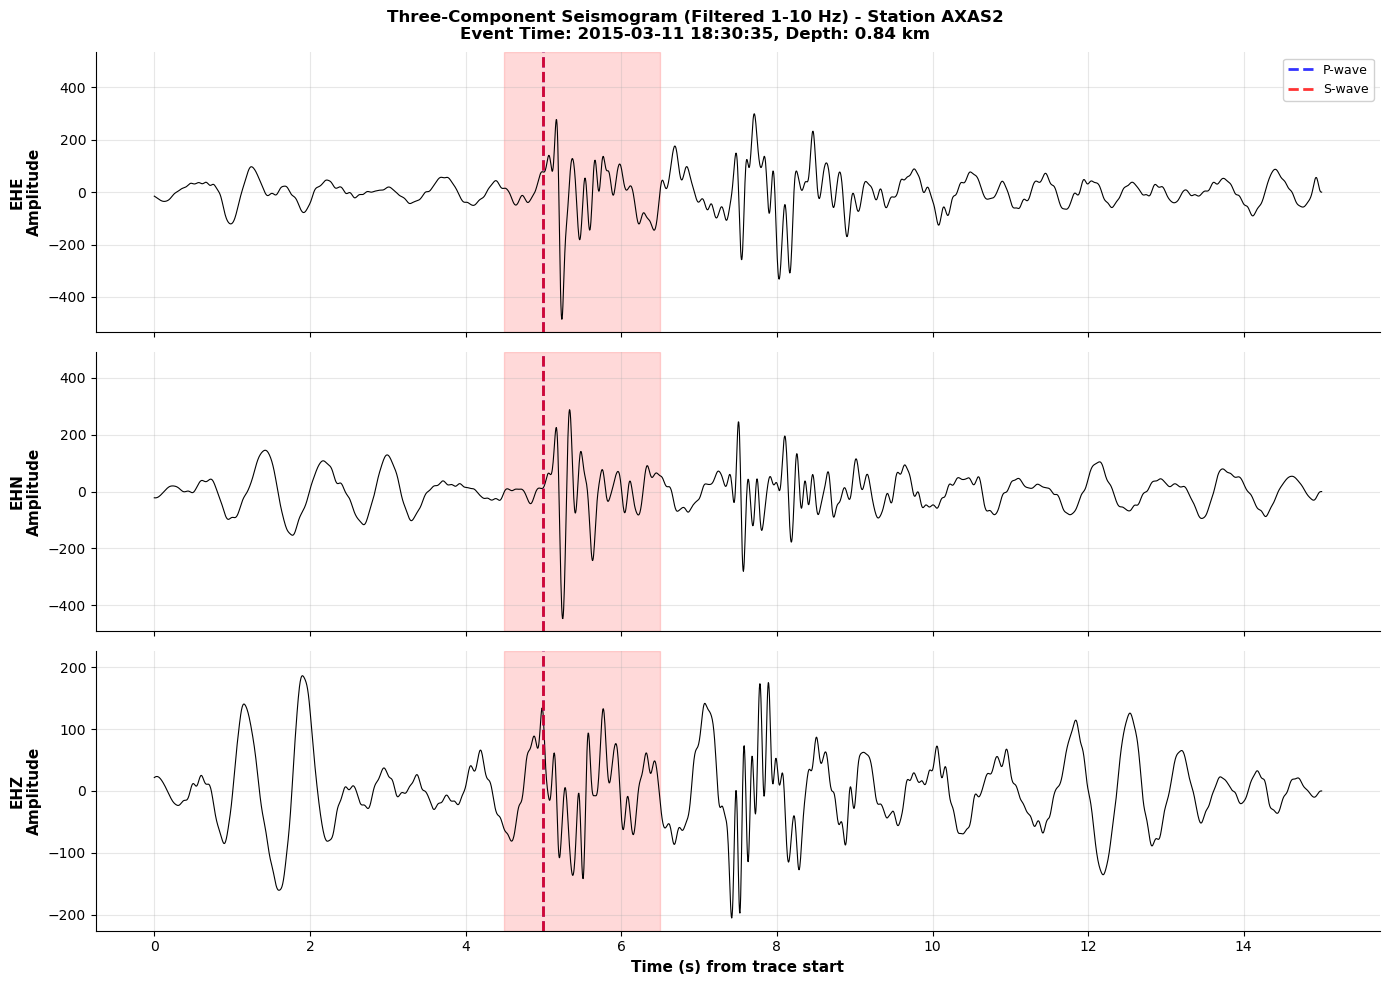

Station: AXAS2, Time: 2015-03-11T18:30:35.440000Z
  P-arrival at: 5.00 s
  S-arrival at: 5.00 s



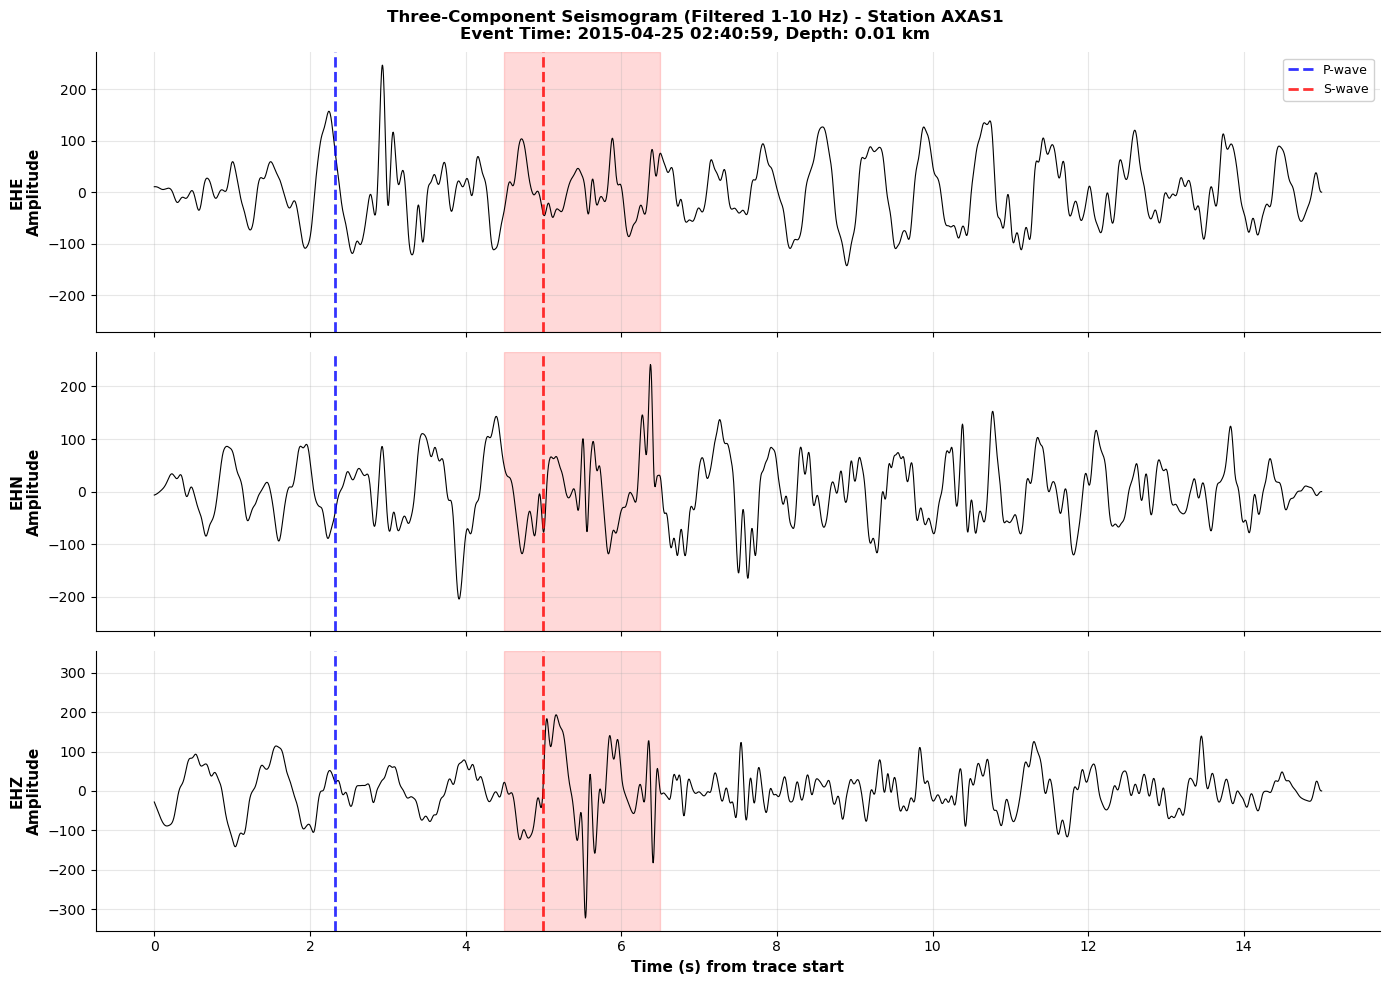

Station: AXAS1, Time: 2015-04-25T02:40:59.175000Z
  P-arrival at: 2.33 s
  S-arrival at: 5.00 s



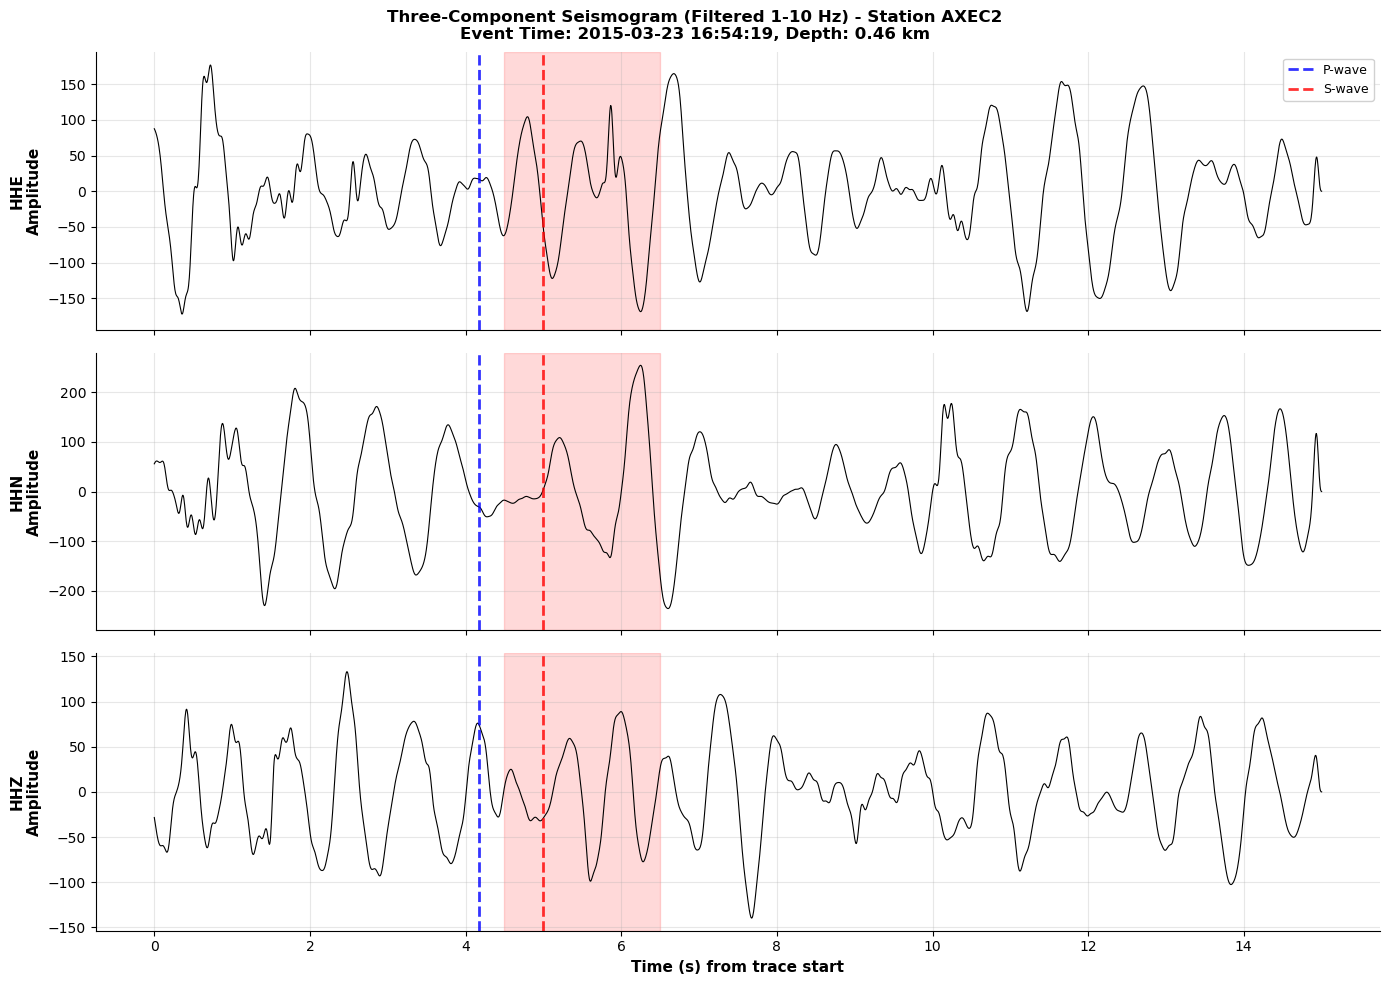

Station: AXEC2, Time: 2015-03-23T16:54:19.640000Z
  P-arrival at: 4.17 s
  S-arrival at: 5.00 s



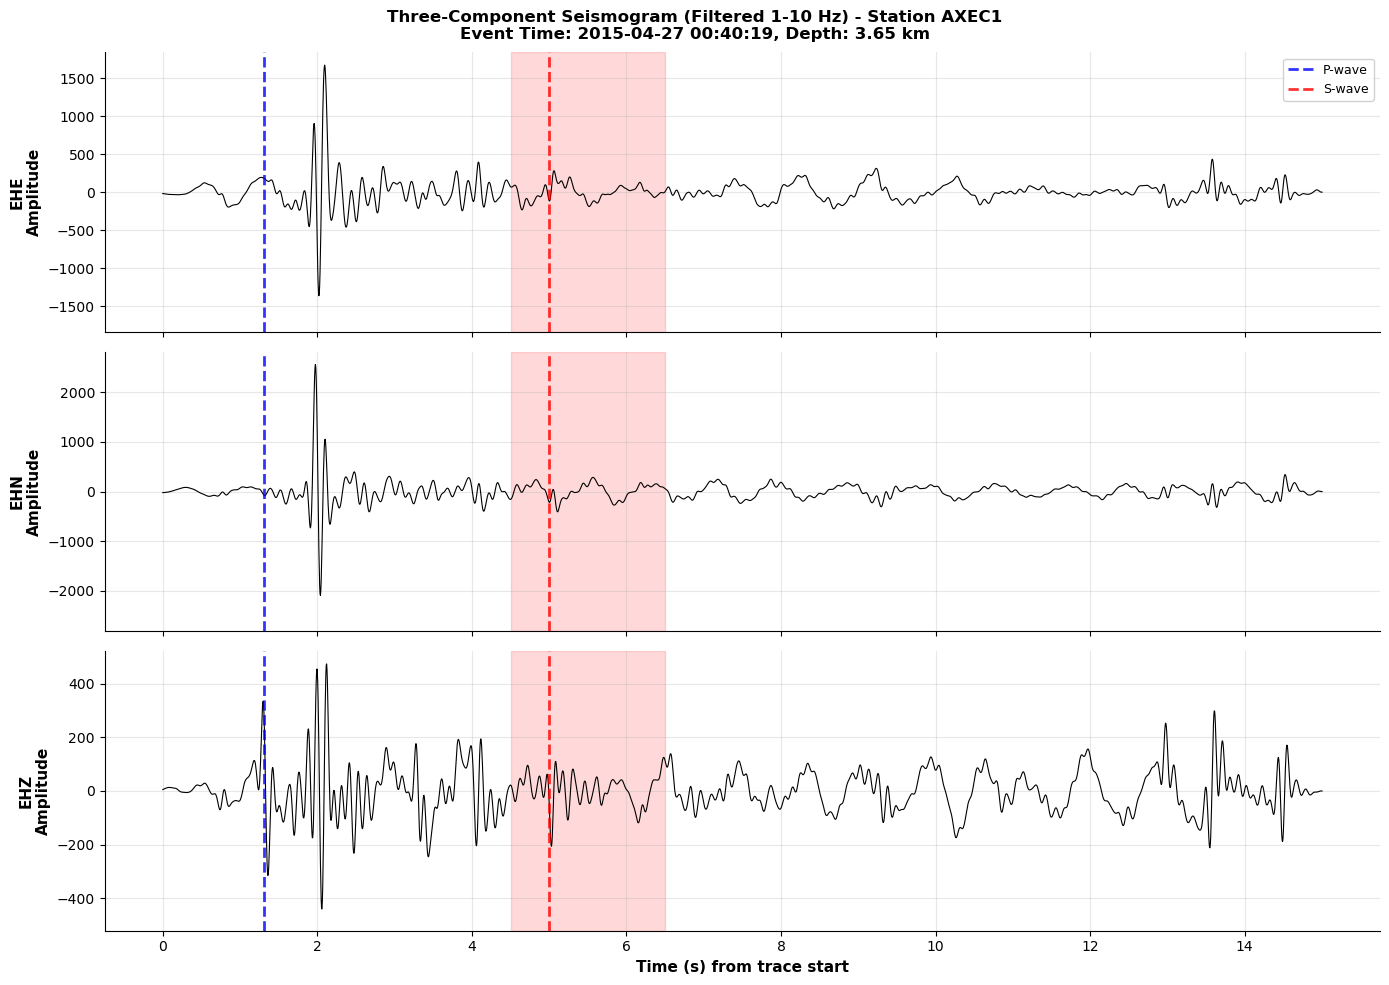

Station: AXEC1, Time: 2015-04-27T00:40:19.975000Z
  P-arrival at: 1.30 s
  S-arrival at: 5.00 s

✓ All waveform plots created with filtering and proper phase markers


In [ ]:
# Plot waveforms with splitting information for samples that have waveforms
for sample in selected_samples:
    obs = sample['obs']
    
    # Check if waveforms were successfully retrieved
    if not hasattr(obs, 'st_filter') or obs.st_filter is None:
        print(f"⚠ No waveforms available for {sample['station']}, skipping...")
        continue
    
    st = obs.st_filter.copy()
    print(f"Plotting waveforms for {sample['station']}")
    
    # Sort traces by channel (Z, N, E order)
    st = st.sort(['channel'])
    
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Get P and S times relative to trace start
    trace_start = st[0].stats.starttime
    p_time_rel = float(obs.p_time - trace_start) if hasattr(obs, 'p_time') else None
    s_time_rel = float(obs.s_time - trace_start) if hasattr(obs, 's_time') else None
    
    # Plot each component
    for i, tr in enumerate(st):
        ax = axes[i]
        
        # Time array (relative to start)
        time = np.arange(len(tr.data)) / tr.stats.sampling_rate
        
        # Plot waveform
        ax.plot(time, tr.data, 'k', linewidth=0.8)
        ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Normalize to show all traces clearly
        ylim = np.max(np.abs(tr.data))
        ax.set_ylim([-ylim * 1.1, ylim * 1.1])
        
        # Add S-wave window shading first (so it's behind markers)
        if s_time_rel is not None:
            ax.axvspan(s_time_rel - 0.5, s_time_rel + 1.5, 
                      alpha=0.15, color='red', zorder=0)
        
        # Add phase markers
        if p_time_rel is not None and p_time_rel > 0:
            ax.axvline(p_time_rel, color='blue', linestyle='--', alpha=0.8, 
                      linewidth=2, label='P-wave', zorder=5)
        if s_time_rel is not None and s_time_rel > 0:
            ax.axvline(s_time_rel, color='red', linestyle='--', alpha=0.8, 
                      linewidth=2, label='S-wave', zorder=5)
        
        if i == 0:
            ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        
        # Remove top and right spines for cleaner look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    axes[-1].set_xlabel('Time (s)', fontweight='bold', fontsize=11)
    
    # Create title with splitting information
    depth_str = f"{sample['depth']:.2f} km" if sample['depth'] is not None else "unknown"
    title = (f"Three-Component Seismogram (Filtered 1-10 Hz) - Station {sample['station']}\n"
            f"Event Time: {obs.s_time.strftime('%Y-%m-%d %H:%M:%S')}, Depth: {depth_str}")
    
    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.98)
    
    # Add text box with splitting parameters
    angle_deg = np.degrees(sample['angle'])
    angle_err_deg = np.degrees(obs.MinLambdas[0].angle_error) if hasattr(obs.MinLambdas[0], 'angle_error') else 0
    lag_sec = sample['lag'] / st[0].stats.sampling_rate
    lag_err_sec = obs.MinLambdas[0].lag_error / st[0].stats.sampling_rate if hasattr(obs.MinLambdas[0], 'lag_error') else 0
    
    info_text = (f"Splitting Parameters:\n"
                f"  Fast direction φ = {angle_deg:.1f}° ± {angle_err_deg:.1f}°\n"
                f"  Delay time δt = {lag_sec:.3f} s ± {lag_err_sec:.4f} s\n"
                f"  Rectilinearity = {sample['rectilinearity']:.3f}\n"
                f"  λ₂ = {obs.MinLambdas[0].lambda2:.2e}" if hasattr(obs.MinLambdas[0], 'lambda2') else "")
    
    axes[0].text(0.98, 0.97, info_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Station: {sample['station']}, Time: {obs.s_time}")
    print(f"  P-arrival at: {p_time_rel:.2f} s" if p_time_rel else "  P-arrival: Not available")
    print(f"  S-arrival at: {s_time_rel:.2f} s" if s_time_rel else "  S-arrival: Not available")
    print(f"{'='*80}\n")

print("✓ All waveform plots created using stored st_filter from observation objects")

## Multi-Station Analysis Complete! 🎉

You have successfully processed and analyzed shear wave splitting data from **all 7 stations** in the Axial Seamount network:

### What We Created:

1. **Loaded Data**: All station pickle files (AXAS1, AXAS2, AXCC1, AXEC1, AXEC2, AXEC3, AXID1)
2. **Station Metadata**: Added location information and calculated distances
3. **Summary Statistics**: Comprehensive stats for each station
4. **Rose Plots**: Polar histograms showing fast direction distributions per station
5. **Comparison Plots**: Side-by-side analysis of splitting parameters across stations
6. **Time Evolution**: Temporal variation of delay times for each station
7. **Network Analysis**: Combined statistics and rose plot for the entire network
8. **Data Export**: Complete results saved to CSV file

### Key Findings to Explore:

- **Spatial Patterns**: Do stations show consistent or varying fast directions?
- **Temporal Changes**: Are there time-dependent variations in splitting parameters?
- **Quality Distribution**: Which stations provide the highest quality measurements?
- **Network-Wide Pattern**: What is the dominant anisotropy direction?

### Next Steps:

- Filter results by quality metrics (rectilinearity > 0.9)
- Correlate splitting parameters with volcanic activity
- Create spatial maps showing splitting patterns
- Compare with tectonic stress indicators
- Analyze depth dependence of splitting parameters

# Shear Wave Splitting Workflow

This notebook demonstrates a complete workflow for loading pickled shear wave splitting data, performing analysis, and visualizing results.

## Overview of the Shear Wave Splitting Process

Shear wave splitting analysis measures seismic anisotropy by analyzing how S-waves split into fast and slow components when traveling through anisotropic media. The analysis involves:

1. **Data Preparation**: Load seismic waveforms with 3-component data (Z, N, E)
2. **Grid Search**: Test multiple lag times and rotation angles to find optimal splitting parameters
3. **Eigenvalue Analysis**: Compute λ1 and λ2 eigenvalues from covariance matrix after rotation and time-shift
4. **Parameter Estimation**: Find the lag and angle that minimize λ2 (maximum linearization)
5. **Quality Control**: Assess measurement quality using rectilinearity, contour analysis, and SNR
6. **Visualization**: Plot splitting parameters, particle motion, and corrected waveforms

### Key Parameters:
- **Fast Direction (φ)**: Angle of polarization of the fast S-wave component
- **Delay Time (δt)**: Time lag between fast and slow arrivals
- **Rectilinearity**: Quality metric (1 - λ2/λ1), where 1 = perfect linear particle motion

## Important Notes

**Updated for modern packages**: This notebook has been updated to work around missing dependencies:
- **`general` module**: Replaced with inline stub functions (no action needed)
- **`mtspec` package**: Replaced with modern `multitaper` package

If you see an import error for `multitaper`, install it with:
```bash
pip install multitaper
```

The pickle files contain **pre-computed splitting results**, so you can analyze existing data without needing all original dependencies.

## 1. Import Libraries and Setup

### Package Dependencies

This workflow requires the following key packages:
- **obspy**: Seismological data handling
- **numpy, matplotlib, pandas**: Standard scientific computing
- **multitaper**: Modern multitaper spectral analysis (replaces deprecated mtspec)

If you encounter import errors for `multitaper`, install it with:
```bash
pip install multitaper
```

The `general` module dependency is handled by stub functions in the code above.

In [ ]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ObsPy for seismological data
from obspy import read, UTCDateTime, Stream
from obspy.clients.fdsn import Client

# Add scripts directory to path
sys.path.insert(0, '../scripts')

# ============================================================
# WORKAROUND: Create stub modules for missing dependencies
# ============================================================
import types

# 1. Create 'general' module stubs
general = types.ModuleType('general')
general.plotwaveform = types.ModuleType('general.plotwaveform')
general.util = types.ModuleType('general.util')
general.projection = types.ModuleType('general.projection')

# Define the cov_eig function that shearwavesplit needs
def cov_eig(data_array):
    """
    Compute eigenvalues of covariance matrix
    This is a simplified version for loading pickled data
    """
    if data_array.ndim == 1:
        data_array = data_array.reshape(-1, 1)
    cov_matrix = np.cov(data_array.T)
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    return sorted(eigenvalues, reverse=True)

# Add functions to the modules
general.plotwaveform.cov_eig = cov_eig
general.util.smooth_curve = lambda x, window_len=11: x  # Stub function
general.projection.ll2xy = lambda lon, lat, ref_lon, ref_lat: ([0, 0], [0, 0])  # Stub

# Register the modules in sys.modules so imports work
sys.modules['general'] = general
sys.modules['general.plotwaveform'] = general.plotwaveform
sys.modules['general.util'] = general.util
sys.modules['general.projection'] = general.projection

print("✓ Workaround modules created for 'general' dependencies")

# 2. Handle multitaper import (replaces deprecated mtspec)
try:
    from multitaper import MTSpec
    print("✓ multitaper package available")
except ImportError:
    print("⚠ multitaper package not installed")
    print("  Install with: pip install multitaper")
    print("  (Only needed if using multitaper spectral analysis)")

# ============================================================
# Now import shear wave splitting module
# ============================================================
try:
    from shearwavesplit import *
    import shearwavesplit as sws
    print("✓ Shear wave splitting module loaded successfully")
except ImportError as e:
    print(f"⚠ Warning: Could not import shearwavesplit module: {e}")
    print("  Some functions may not be available.")

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("\n=== Environment Setup Complete ===")
print(f"Working directory: {Path.cwd()}")

## 2. Load Pickle Data

The pickle files contain `SWSobs` (Shear Wave Splitting Observation) objects with:
- Event metadata (location, time, magnitude)
- Station information
- Waveform data (3-component seismograms)
- P and S arrival times
- Splitting analysis results (MinLambdas list)

In [ ]:
# Define path to pickle file
pickle_path = Path('../data/AXAS2.clean.cat.pickle')

# Check if file exists
if not pickle_path.exists():
    raise FileNotFoundError(f"Pickle file not found: {pickle_path}")

print(f"Loading pickle file: {pickle_path.name}")
print(f"File size: {pickle_path.stat().st_size / 1024:.2f} KB\n")

# Load the pickle file
with open(pickle_path, 'rb') as f:
    sws_data = pickle.load(f)

print(f"✓ Pickle file loaded successfully")
print(f"Data type: {type(sws_data)}")
print(f"Number of observations: {len(sws_data)}")

## 3. Explore the Data Structure

Each observation (SWSobs object) contains:
- `obs_id`: Unique identifier (station_YYYYMMDD_HHMMSS)
- `event_lon`, `event_lat`, `event_depth`: Event location
- `station_code`: Station name
- `p_time`, `s_time`: Phase arrival times
- `st_raw`: Raw 3-component stream
- `st_filter`: Filtered stream
- `MinLambdas`: List of splitting solutions from grid search

In [ ]:
# Examine the first observation
if len(sws_data) > 0:
    obs = sws_data[0]
    
    print("=== First Observation Details ===")
    print(f"Type: {type(obs).__name__}")
    if hasattr(obs, 'obs_id'):
        print(f"Observation ID: {obs.obs_id}")
    
    print("\n=== Available Attributes ===")
    
    # First, discover all actual attributes
    actual_attrs = [attr for attr in dir(obs) if not attr.startswith('_')]
    print(f"All attributes: {actual_attrs}")
    
    print("\n=== Key Attributes Check ===")
    # List key attributes we're looking for
    key_attrs = ['obs_id', 'event_id', 'station_code', 'event_lon', 'event_lat', 
                 'event_depth', 'p_time', 's_time', 'st_raw', 'st_filter', 
                 'MinLambdas', 'baz_trigo', 'hyp_dist']
    
    for attr in key_attrs:
        if hasattr(obs, attr):
            value = getattr(obs, attr)
            if attr in ['st_raw', 'st_filter'] and value is not None:
                print(f"  ✓ {attr}: {type(value).__name__} with {len(value)} traces")
            elif attr == 'MinLambdas' and value is not None:
                print(f"  ✓ {attr}: List with {len(value)} splitting solutions")
            else:
                print(f"  ✓ {attr}: {value}")
        else:
            print(f"  ✗ {attr}: Not available")
else:
    print("No observations found in the pickle file.")

## 4. Summary Statistics

Get an overview of the entire catalog

In [ ]:
# Collect statistics from all observations
stations = []
depths = []
num_solutions = []
s_times = []

for obs in sws_data:
    if hasattr(obs, 'station_code'):
        stations.append(obs.station_code)
    if hasattr(obs, 'event_depth'):
        depths.append(obs.event_depth)
    if hasattr(obs, 'MinLambdas'):
        num_solutions.append(len(obs.MinLambdas))
    if hasattr(obs, 's_time'):
        s_times.append(obs.s_time)

print("=== Catalog Summary ===")
print(f"Total observations: {len(sws_data)}")
print(f"\nStations: {set(stations)}")
print(f"\nDepth range: {min(depths):.2f} - {max(depths):.2f} km")
print(f"Average depth: {np.mean(depths):.2f} km")
print(f"\nSolutions per observation: {np.mean(num_solutions):.1f} average")

if s_times:
    print(f"\nTime range: {min(s_times)} to {max(s_times)}")

In [ ]:
stations_df

In [ ]:
# Bring in our station metadata csv, loaded as a pandas dataframe
import pandas as pd
stations_file = '../data/axial_seamount_stations.csv'
stations_df = pd.read_csv(stations_file)

In [ ]:
# Get station lat, lon, and elev for AXAS2 station from stations_df, then save as variables in observation objects
for obs in sws_data:
    if hasattr(obs, 'station_code'):
        station_info = stations_df[stations_df['Station ID'] == obs.station_code]
        if not station_info.empty:
            obs.sta_lat = station_info['Latitude (°N)'].values[0]
            obs.sta_lon = station_info['Longitude (°W)'].values[0]
            obs.sta_z = station_info['Elevation (m)'].values[0]

# Assign event_lat and event_lon to ini_lat and ini_lon for each observation
for obs in sws_data:
    if hasattr(obs, 'event_lat') and hasattr(obs, 'event_lon'):
        obs.ini_lat = obs.event_lat
        obs.ini_lon = obs.event_lon

In [ ]:
# Call get_hyp_dist to calculate hypocentral distance for each observation
for obs in sws_data:
    if hasattr(obs, 'get_hyp_dist') and hasattr(obs, 'sta_lon') and hasattr(obs, 'sta_lat') and hasattr(obs, 'sta_z') and hasattr(obs, 'ini_lon') and hasattr(obs, 'ini_lat'):
        obs.get_hyp_dist(obs.sta_lon, obs.sta_lat, obs.sta_z, obs.ini_lon, obs.ini_lat)

## 5. Shear Wave Splitting Analysis

### The Core Algorithm

The splitting analysis uses a grid search approach:

1. **Grid Search Parameters**:
   - Lag times: typically 0-60 samples (0-0.6s at 100 Hz)
   - Rotation angles: -90° to +90° (180° range covers all possibilities)

2. **For each (lag, angle) pair**:
   - Rotate horizontal components by angle
   - Shift one component by lag time
   - Compute eigenvalues (λ1, λ2) of covariance matrix
   - Store λ2 value

3. **Find optimal solution**:
   - Minimum λ2 indicates best linearization
   - Extract lag and angle at minimum
   - Compute error bounds from contour analysis

Let's analyze a single event:

In [ ]:
# Select an observation with good quality results
# Look for one with multiple MinLambdas solutions
good_obs = None
for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        good_obs = obs
        break

if good_obs is None:
    print("⚠ No observations with splitting solutions found.")
else:
    print("=== Selected Observation for Analysis ===")
    print(f"\nNumber of splitting solutions: {len(good_obs.MinLambdas)}")
    
    # Display information about each solution
    print("\n=== Splitting Solutions ===")
    for i, min_lambda in enumerate(good_obs.MinLambdas):
        print(f"\nSolution #{i+1}:")
        if hasattr(min_lambda, 'lag'):
            print(f"  Lag (samples): {min_lambda.lag:.2f}")
        if hasattr(min_lambda, 'angle'):
            angle_deg = np.degrees(min_lambda.angle)
            print(f"  Fast direction (degrees): {angle_deg:.1f}°")
        if hasattr(min_lambda, 'rec'):
            print(f"  Rectilinearity: {min_lambda.rec:.3f}")
        if hasattr(min_lambda, 'lambda2'):
            print(f"  λ2 value: {min_lambda.lambda2:.6f}")
        if hasattr(min_lambda, 'lag_error'):
            print(f"  Lag error: {min_lambda.lag_error:.2f} samples")
        if hasattr(min_lambda, 'angle_error'):
            angle_err_deg = np.degrees(min_lambda.angle_error)
            print(f"  Angle error: {angle_err_deg:.1f}°")

## 6. Visualize Waveforms

Plot the raw and filtered 3-component seismograms

In [ ]:
dir(good_obs)

In [ ]:
if good_obs and hasattr(good_obs, 'st_filter'):
    st = good_obs.st_filter
    print(good_obs)
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    # Plot each component
    for i, tr in enumerate(st):
        ax = axes[i]
        
        # Time array (relative to start)
        time = np.arange(len(tr.data)) / tr.stats.sampling_rate
        
        # Plot waveform
        ax.plot(time, tr.data, 'k', linewidth=0.8)
        ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add phase markers if available
        if hasattr(good_obs, 'p_time') and hasattr(good_obs, 's_time'):
            p_rel = (good_obs.p_time - tr.stats.starttime)
            s_rel = (good_obs.s_time - tr.stats.starttime)
            
            ax.axvline(p_rel, color='blue', linestyle='--', alpha=0.7, label='P-wave')
            ax.axvline(s_rel, color='red', linestyle='--', alpha=0.7, label='S-wave')
            
            if i == 0:
                ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Time (s)', fontweight='bold')
    
    # Title
    if hasattr(good_obs, 'obs_id'):
        fig.suptitle(f'Three-Component Seismogram\n{good_obs.obs_id}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No waveform data available for plotting.")

## 7. Plot Splitting Parameters

Visualize the distribution of fast directions and delay times

In [ ]:
# Extract splitting parameters from all observations
fast_directions = []  # in degrees
delay_times = []      # in samples
rectilinearities = []

for obs in sws_data:
    if hasattr(obs, 'MinLambdas'):
        # Use the first (best) solution
        min_lambda = obs.MinLambdas[0]
        
        if hasattr(min_lambda, 'angle'):
            fast_directions.append(np.degrees(min_lambda.angle))
        
        if hasattr(min_lambda, 'lag'):
            delay_times.append(min_lambda.lag)
        
        if hasattr(min_lambda, 'rec'):
            rectilinearities.append(min_lambda.rec)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fast direction histogram
if fast_directions:
    axes[0, 0].hist(fast_directions, bins=36, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Fast Direction (degrees)', fontweight='bold')
    axes[0, 0].set_ylabel('Count', fontweight='bold')
    axes[0, 0].set_title(f'Fast Direction Distribution\nn={len(fast_directions)}', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvline(np.mean(fast_directions), color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(fast_directions):.1f}°')
    axes[0, 0].legend()

# 2. Delay time histogram
if delay_times:
    axes[0, 1].hist(delay_times, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Delay Time (samples)', fontweight='bold')
    axes[0, 1].set_ylabel('Count', fontweight='bold')
    axes[0, 1].set_title(f'Delay Time Distribution\nn={len(delay_times)}', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline(np.mean(delay_times), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(delay_times):.1f} samples')
    axes[0, 1].legend()

# 3. Rectilinearity histogram
if rectilinearities:
    axes[1, 0].hist(rectilinearities, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Rectilinearity', fontweight='bold')
    axes[1, 0].set_ylabel('Count', fontweight='bold')
    axes[1, 0].set_title(f'Rectilinearity Distribution\nn={len(rectilinearities)}', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axvline(np.mean(rectilinearities), color='darkgreen', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(rectilinearities):.3f}')
    axes[1, 0].legend()

# 4. Scatter: Fast direction vs Delay time
if fast_directions and delay_times and len(fast_directions) == len(delay_times):
    scatter = axes[1, 1].scatter(fast_directions, delay_times, 
                                  c=rectilinearities if rectilinearities else 'purple',
                                  cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[1, 1].set_xlabel('Fast Direction (degrees)', fontweight='bold')
    axes[1, 1].set_ylabel('Delay Time (samples)', fontweight='bold')
    axes[1, 1].set_title('Fast Direction vs Delay Time', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    if rectilinearities:
        cbar = plt.colorbar(scatter, ax=axes[1, 1])
        cbar.set_label('Rectilinearity', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("=== Splitting Parameter Statistics ===")
if fast_directions:
    print(f"\nFast Direction:")
    print(f"  Mean: {np.mean(fast_directions):.1f}°")
    print(f"  Std:  {np.std(fast_directions):.1f}°")
    print(f"  Range: [{min(fast_directions):.1f}°, {max(fast_directions):.1f}°]")

if delay_times:
    print(f"\nDelay Time:")
    print(f"  Mean: {np.mean(delay_times):.1f} samples")
    print(f"  Std:  {np.std(delay_times):.1f} samples")
    print(f"  Range: [{min(delay_times):.1f}, {max(delay_times):.1f}] samples")

if rectilinearities:
    print(f"\nRectilinearity:")
    print(f"  Mean: {np.mean(rectilinearities):.3f}")
    print(f"  Std:  {np.std(rectilinearities):.3f}")
    print(f"  Range: [{min(rectilinearities):.3f}, {max(rectilinearities):.3f}]")

## 8. Advanced Visualization Using Baillard's Plotting Functions

Now we'll use the comprehensive plotting functions from the `shearwavesplit` module (authored by @baillard) to create detailed diagnostic plots showing:

1. **Lambda2 Contour Maps**: Visualize the grid search results
2. **Particle Motion Plots**: Before and after splitting correction
3. **Waveform Comparison**: Original vs unsplit waveforms
4. **Time Evolution**: Splitting parameters over time

In [ ]:
# Import additional plotting functions
from general.plotwaveform import plot_patch, plot_particle_motion

# Select a good observation for detailed plotting
# We'll use the same observation we analyzed earlier
if good_obs is None:
    print("⚠ No good observation found. Please run the previous cells first.")
else:
    print(f"Selected observation: {good_obs.obs_id}")
    print(f"Number of MinLambda solutions: {len(good_obs.MinLambdas)}")
    print(f"Best solution:")
    print(f"  Lag: {good_obs.MinLambdas[0].lag:.2f} samples")
    print(f"  Fast direction: {np.degrees(good_obs.MinLambdas[0].angle):.1f}°")
    print(f"  Rectilinearity: {good_obs.MinLambdas[0].rec:.3f}")

### 8.1 Comprehensive Diagnostic Plot

This creates a publication-quality diagnostic figure showing:
- **Top panels**: Original and corrected waveforms (zoomed view)
- **Bottom left**: Lambda2 contour map showing the grid search results
- **Bottom center**: Original particle motion (before correction)
- **Bottom right**: Corrected particle motion (after unsplitting)

In [ ]:
if good_obs and hasattr(good_obs, 'st_filter') and hasattr(good_obs, 'MinLambdas'):
    # Extract waveform data
    st = good_obs.st_filter.copy()
    
    # Get horizontal components (assuming order is Z, N, E or similar)
    # We need to identify which traces are horizontal
    horizontal_traces = [tr for tr in st if tr.stats.channel[-1] in ['N', 'E', '1', '2']]
    
    if len(horizontal_traces) >= 2:
        # Create xy_array (2-column array: E/X, N/Y)
        trace1 = horizontal_traces[0].data
        trace2 = horizontal_traces[1].data
        
        # Make sure they're the same length
        min_len = min(len(trace1), len(trace2))
        xy_array = np.column_stack([trace1[:min_len], trace2[:min_len]])
        
        # Get S-wave window (sw1, sw2 are indices relative to trace start)
        sampling_rate = st[0].stats.sampling_rate
        s_arrival_time = good_obs.s_time - st[0].stats.starttime
        
        # Define S-wave window: 0.5s before to 1.5s after S-arrival
        sw1 = int(max(0, (s_arrival_time - 0.5) * sampling_rate))
        sw2 = int(min(len(xy_array), (s_arrival_time + 1.5) * sampling_rate))
        
        # Cut array to S-wave window
        xy_array_cut = xy_array[sw1:sw2, :]
        
        # Get the best splitting parameters
        lag = good_obs.MinLambdas[0].lag
        angle = good_obs.MinLambdas[0].angle
        
        print(f"Processing observation with:")
        print(f"  S-wave window: samples {sw1} to {sw2}")
        print(f"  Best lag: {lag:.2f} samples ({lag/sampling_rate:.3f} s)")
        print(f"  Best angle: {np.degrees(angle):.1f}°")
        
        # Create the diagnostic plot
        plt.close('all')
        
        middle = 0.55
        fig = plt.figure(figsize=(14, 8))
        
        gs1 = gridspec.GridSpec(3, 2,
                               width_ratios=[1, 1],
                               left=0.1, right=0.9, top=0.99, bottom=middle+0.05,
                               wspace=0.01, hspace=0)
        gs2 = gridspec.GridSpec(1, 3,
                               width_ratios=[1, 1, 1],
                               left=0.1, right=0.9, top=middle-0.05, bottom=0.1,
                               wspace=0.1)
        
        # Waveform axes
        ax_wave_1 = plt.subplot(gs1[0])
        ax_wave_2 = plt.subplot(gs1[2], sharey=ax_wave_1, sharex=ax_wave_1)
        ax_wave_3 = plt.subplot(gs1[4], sharey=ax_wave_1, sharex=ax_wave_1)
        ax_wavez_1 = plt.subplot(gs1[1])
        ax_wavez_2 = plt.subplot(gs1[3], sharey=ax_wavez_1, sharex=ax_wavez_1)
        ax_wavez_3 = plt.subplot(gs1[5], sharey=ax_wavez_1, sharex=ax_wavez_1)
        
        # Analysis axes
        ax_lambda = plt.subplot(gs2[0])
        ax_polar_1 = plt.subplot(gs2[1])
        ax_polar_2 = plt.subplot(gs2[2], sharex=ax_polar_1, sharey=ax_polar_1)
        
        ax_wave = [ax_wave_1, ax_wave_2, ax_wave_3]
        ax_wavez = [ax_wavez_1, ax_wavez_2, ax_wavez_3]
        
        # Plot unsplit waveforms
        (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=True, ax_list=ax_wave)
        (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=True, ax_list=ax_wavez)
        xy_unsplit_cut = xy_unsplit[sw1:sw2, :]
        
        # Plot particle motions
        plot_particle_motion(xy_array_cut, time_array=None, ax=ax_polar_1, 
                           vmin=None, vmax=None, xlabel='X', ylabel='Y')
        plot_particle_motion(xy_unsplit_cut, time_array=None, ax=ax_polar_2, 
                           vmin=None, vmax=None, xlabel='X', ylabel='Y')
        
        # Plot Lambda2 contour if available
        if hasattr(good_obs.MinLambdas[0], 'LAMBDA2'):
            LAMBDA2 = good_obs.MinLambdas[0].LAMBDA2
            LAGS = good_obs.MinLambdas[0].LAGS
            ANGLES = good_obs.MinLambdas[0].ANGLES
            
            extent = [ANGLES[0, 0], ANGLES[0, -1], LAGS[0, 0], LAGS[-1, 0]]
            im = ax_lambda.imshow(LAMBDA2, aspect='auto', extent=extent, 
                                origin='lower', cmap='jet_r')
            ax_lambda.plot(angle, lag, 'w*', markersize=15, markeredgecolor='k')
            ax_lambda.set_xlabel('Angle (rad)')
            ax_lambda.set_ylabel('Lag (samples)')
            ax_lambda.set_title(r'Min. $\lambda_{2}$')
            plt.colorbar(im, ax=ax_lambda)
        else:
            ax_lambda.text(0.5, 0.5, 'Lambda2 data not available', 
                         ha='center', va='center', transform=ax_lambda.transAxes)
        
        # Cosmetics
        plot_patch(ax_wave_1, start=sw1, width=sw2-sw1, facecolor='0.9', zorder=-1, label='S')
        ax_wave_1.axvline(x=sw1+4, linestyle='-', color='k', lw=1, zorder=0)
        ax_wave_1.set_xlim([0, ax_wave_1.get_xlim()[1]])
        
        plot_patch(ax_wavez_1, start=sw1, width=sw2-sw1, facecolor='0.9', zorder=-1, label='S')
        ax_wavez_1.axvline(x=sw1+4, linestyle='-', color='k', lw=1, zorder=0)
        
        plt.setp(ax_polar_1.get_yticklabels(), visible=False)
        ax_wavez_1.yaxis.set_visible(False)
        ax_wavez_2.yaxis.set_visible(False)
        ax_wavez_3.yaxis.set_visible(False)
        ax_wave_2.yaxis.set_visible(False)
        ax_wave_3.yaxis.set_visible(False)
        ax_wave_1.xaxis.set_visible(False)
        ax_wave_2.xaxis.set_visible(False)
        
        ax_polar_1.set_ylabel('')
        ax_polar_1.set_title('Initial')
        ax_polar_2.set_title('Corrected (Unsplit)')
        ax_polar_2.yaxis.set_label_position("right")
        ax_polar_2.yaxis.tick_right()
        ax_wavez_1.set_xlim([sw1-50, sw2+50])
        
        fig.suptitle(f'Splitting Diagnostic Plot - {good_obs.obs_id}', 
                    fontsize=14, fontweight='bold', y=0.995)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Diagnostic plot created successfully")
        
    else:
        print("⚠ Could not find two horizontal components in the waveform data")
else:
    print("⚠ No suitable observation available for plotting")

### 8.2 Particle Motion Comparison for Multiple Events

Compare particle motion before and after splitting correction for several observations

In [ ]:
# Select multiple good observations
n_plots = 6  # Number of observations to plot
good_observations = []

for obs in sws_data:
    if (hasattr(obs, 'st_filter') and obs.st_filter is not None and
        hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0):
        good_observations.append(obs)
        if len(good_observations) >= n_plots:
            break

if len(good_observations) > 0:
    print(f"Found {len(good_observations)} observations to plot")
    
    # Create figure with subplots
    fig, axes = plt.subplots(len(good_observations), 2, figsize=(10, 3*len(good_observations)))
    
    if len(good_observations) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, obs in enumerate(good_observations):
        st = obs.st_filter.copy()
        
        # Get horizontal components
        horizontal_traces = [tr for tr in st if tr.stats.channel[-1] in ['N', 'E', '1', '2']]
        
        if len(horizontal_traces) >= 2:
            # Create xy_array
            trace1 = horizontal_traces[0].data
            trace2 = horizontal_traces[1].data
            min_len = min(len(trace1), len(trace2))
            xy_array = np.column_stack([trace1[:min_len], trace2[:min_len]])
            
            # Get S-wave window
            sampling_rate = st[0].stats.sampling_rate
            s_arrival_time = obs.s_time - st[0].stats.starttime
            sw1 = int(max(0, (s_arrival_time - 0.5) * sampling_rate))
            sw2 = int(min(len(xy_array), (s_arrival_time + 1.5) * sampling_rate))
            
            xy_array_cut = xy_array[sw1:sw2, :]
            
            # Get splitting parameters
            lag = obs.MinLambdas[0].lag
            angle = obs.MinLambdas[0].angle
            
            # Unsplit
            (xy_unsplit, _) = sws.unsplit(xy_array, lag, angle, flag_plot=False)
            xy_unsplit_cut = xy_unsplit[sw1:sw2, :]
            
            # Plot original
            ax1 = axes[idx, 0]
            plot_particle_motion(xy_array_cut, time_array=None, ax=ax1,
                               vmin=None, vmax=None, xlabel='X', ylabel='Y')
            ax1.set_title(f'Original\n{obs.obs_id}', fontsize=9)
            
            # Plot corrected
            ax2 = axes[idx, 1]
            plot_particle_motion(xy_unsplit_cut, time_array=None, ax=ax2,
                               vmin=None, vmax=None, xlabel='X', ylabel='Y')
            ax2.set_title(f'Corrected\nφ={np.degrees(angle):.1f}°, δt={lag/sampling_rate:.3f}s', 
                         fontsize=9)
            
            # Add rectilinearity info
            if hasattr(obs.MinLambdas[0], 'rec'):
                ax2.text(0.05, 0.95, f'Rect: {obs.MinLambdas[0].rec:.3f}',
                        transform=ax2.transAxes, va='top', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Particle motion comparison plot created")
else:
    print("⚠ No suitable observations found for plotting")

### 8.3 Splitting Parameters Over Time

Use the `movehisto2d` function from @baillard to visualize how splitting parameters evolve over time

In [ ]:
# Import the movehisto2d function from shearwavesplit_plot
import sys
sys.path.insert(0, '../scripts')
from shearwavesplit_plot import movehisto2d

# Extract time and delay time data
times = []
lags = []

for obs in sws_data:
    if hasattr(obs, 's_time') and hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        times.append(obs.s_time)
        lags.append(obs.MinLambdas[0].lag)

if len(times) > 10:  # Need enough data points
    print(f"Plotting time evolution of delay times for {len(times)} observations")
    
    # Define time window parameters
    time_start = min(times)
    time_end = max(times)
    
    print(f"Time range: {time_start} to {time_end}")
    print(f"Duration: {(time_end - time_start) / 86400:.1f} days")
    
    # Create the moving histogram plot
    ax_list = movehisto2d(
        x=times,
        y=lags,
        x_width=3,  # 3-day window
        y_width=2,  # 2-sample window for lags
        x_start=time_start,
        y_start=0,
        x_end=time_end,
        y_end=max(lags) + 5,
        x_over=0.9,  # 90% overlap for smooth visualization
        y_over=0.7,
        norm_y=True,
        smooth=True,
        gaussian_x_per=0.5,
        gaussian_y_per=0.5,
        x_label='Time',
        y_label='Delay Time (samples)',
        text_list=[f'Station: {sws_data[0].station_code}', 
                   f'N = {len(times)} events']
    )
    
    print("\n✓ Time evolution plot created")
    
else:
    print(f"⚠ Not enough data points ({len(times)}) to create time evolution plot")

### 8.4 Fast Direction Rose Plot (Polar Histogram)

Use the polar histogram function to visualize the distribution of fast directions

In [ ]:
# Extract fast directions (in radians for trigonometric convention)
fast_angles_rad = []
weights = []  # Can weight by rectilinearity

for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        min_lambda = obs.MinLambdas[0]
        if hasattr(min_lambda, 'angle'):
            # Convert to trigonometric convention (0 = East, counterclockwise)
            fast_angles_rad.append(min_lambda.angle)
            
            # Weight by rectilinearity if available
            if hasattr(min_lambda, 'rec'):
                weights.append(min_lambda.rec)
            else:
                weights.append(1.0)

if len(fast_angles_rad) > 0:
    print(f"Plotting rose diagram for {len(fast_angles_rad)} fast directions")
    
    # Create polar plot
    fig = plt.figure(figsize=(10, 10))
    ax_polar = fig.add_subplot(111, projection='polar')
    
    # Use the plot_polar_histo function
    sws.plot_polar_histo(
        trigo_angles=fast_angles_rad,
        weights=weights,
        width_bin_deg=5,  # 5-degree bins
        ax_polar=ax_polar,
        facecolor='steelblue',
        edgecolor='black',
        lw=0.5,
        alpha=0.7,
        text=True
    )
    
    # Set 0 degrees to North (top)
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)  # Clockwise
    
    # Add title
    ax_polar.set_title(f'Fast Direction Distribution (Rose Plot)\n'
                      f'Station: {sws_data[0].station_code if sws_data else "Unknown"}\n'
                      f'N = {len(fast_angles_rad)} measurements',
                      fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate statistics
    mean_angle = np.arctan2(np.mean(np.sin(fast_angles_rad)), 
                           np.mean(np.cos(fast_angles_rad)))
    mean_angle_deg = np.degrees(mean_angle)
    if mean_angle_deg < 0:
        mean_angle_deg += 360
    
    print(f"\n=== Fast Direction Statistics ===")
    print(f"Mean direction: {mean_angle_deg:.1f}° (trigonometric)")
    print(f"               {(90 - mean_angle_deg) % 360:.1f}° (from North, clockwise)")
    print(f"Number of measurements: {len(fast_angles_rad)}")
    
    # Calculate circular standard deviation
    R = np.sqrt(np.mean(np.sin(fast_angles_rad))**2 + np.mean(np.cos(fast_angles_rad))**2)
    circular_std = np.sqrt(-2 * np.log(R))
    print(f"Circular concentration: R = {R:.3f}")
    print(f"Circular std deviation: {np.degrees(circular_std):.1f}°")
    
else:
    print("⚠ No fast direction data available for plotting")

### 8.5 Quality Metrics Summary

Visualize the quality of splitting measurements through various metrics

In [ ]:
# Collect quality metrics from all observations
quality_data = {
    'rectilinearity': [],
    'lag': [],
    'lag_error': [],
    'angle': [],
    'angle_error': [],
    'lambda2': [],
    's_snr': []
}

for obs in sws_data:
    if hasattr(obs, 'MinLambdas') and len(obs.MinLambdas) > 0:
        ml = obs.MinLambdas[0]
        
        if hasattr(ml, 'rec'):
            quality_data['rectilinearity'].append(ml.rec)
        if hasattr(ml, 'lag'):
            quality_data['lag'].append(ml.lag)
        if hasattr(ml, 'lag_error'):
            quality_data['lag_error'].append(ml.lag_error)
        if hasattr(ml, 'angle'):
            quality_data['angle'].append(np.degrees(ml.angle))
        if hasattr(ml, 'angle_error'):
            quality_data['angle_error'].append(np.degrees(ml.angle_error))
        if hasattr(ml, 'lambda2'):
            quality_data['lambda2'].append(ml.lambda2)
        if hasattr(obs, 's_snr') and obs.s_snr is not None:
            quality_data['s_snr'].append(obs.s_snr)

# Create comprehensive quality plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1. Rectilinearity distribution
if quality_data['rectilinearity']:
    axes[0].hist(quality_data['rectilinearity'], bins=30, color='green', 
                 alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(quality_data['rectilinearity']), color='red', 
                   linestyle='--', linewidth=2, label=f"Mean: {np.mean(quality_data['rectilinearity']):.3f}")
    axes[0].set_xlabel('Rectilinearity', fontweight='bold')
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].set_title('Rectilinearity Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# 2. Delay time with errors
if quality_data['lag'] and quality_data['lag_error']:
    sampling_rate = 100  # Assume 100 Hz, adjust as needed
    lags_sec = np.array(quality_data['lag']) / sampling_rate
    lag_errors_sec = np.array(quality_data['lag_error']) / sampling_rate
    
    indices = np.arange(len(lags_sec))
    axes[1].errorbar(indices, lags_sec, yerr=lag_errors_sec, fmt='o', 
                    alpha=0.6, capsize=3, markersize=4)
    axes[1].axhline(np.mean(lags_sec), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(lags_sec):.3f}s')
    axes[1].set_xlabel('Measurement Index', fontweight='bold')
    axes[1].set_ylabel('Delay Time (s)', fontweight='bold')
    axes[1].set_title('Delay Time with Uncertainties')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# 3. Fast direction with errors
if quality_data['angle'] and quality_data['angle_error']:
    angles = np.array(quality_data['angle'])
    angle_errors = np.array(quality_data['angle_error'])
    
    indices = np.arange(len(angles))
    axes[2].errorbar(indices, angles, yerr=angle_errors, fmt='o', 
                    alpha=0.6, capsize=3, markersize=4, color='purple')
    axes[2].axhline(np.mean(angles), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(angles):.1f}°')
    axes[2].set_xlabel('Measurement Index', fontweight='bold')
    axes[2].set_ylabel('Fast Direction (degrees)', fontweight='bold')
    axes[2].set_title('Fast Direction with Uncertainties')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

# 4. Lambda2 values
if quality_data['lambda2']:
    axes[3].hist(quality_data['lambda2'], bins=30, color='coral', 
                 alpha=0.7, edgecolor='black')
    axes[3].set_xlabel('λ₂ Value', fontweight='bold')
    axes[3].set_ylabel('Count', fontweight='bold')
    axes[3].set_title('Minimum λ₂ Distribution')
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3)

# 5. Rectilinearity vs Delay Time
if quality_data['rectilinearity'] and quality_data['lag']:
    sc = axes[4].scatter(quality_data['lag'], quality_data['rectilinearity'],
                        c=quality_data['lambda2'] if quality_data['lambda2'] else 'blue',
                        cmap='viridis_r', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[4].set_xlabel('Delay Time (samples)', fontweight='bold')
    axes[4].set_ylabel('Rectilinearity', fontweight='bold')
    axes[4].set_title('Quality vs Delay Time')
    axes[4].grid(True, alpha=0.3)
    if quality_data['lambda2']:
        plt.colorbar(sc, ax=axes[4], label='λ₂')

# 6. SNR distribution (if available)
if quality_data['s_snr']:
    axes[5].hist(quality_data['s_snr'], bins=30, color='teal', 
                 alpha=0.7, edgecolor='black')
    axes[5].set_xlabel('S-wave SNR', fontweight='bold')
    axes[5].set_ylabel('Count', fontweight='bold')
    axes[5].set_title('Signal-to-Noise Ratio')
    axes[5].grid(True, alpha=0.3)
else:
    axes[5].text(0.5, 0.5, 'SNR data not available', 
                ha='center', va='center', transform=axes[5].transAxes,
                fontsize=12)
    axes[5].axis('off')

plt.suptitle(f'Splitting Quality Metrics Summary\nStation: {sws_data[0].station_code if sws_data else "Unknown"}',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Quality Metrics Summary ===")
if quality_data['rectilinearity']:
    print(f"\nRectilinearity:")
    print(f"  Mean: {np.mean(quality_data['rectilinearity']):.3f}")
    print(f"  Std:  {np.std(quality_data['rectilinearity']):.3f}")
    print(f"  High quality (>0.9): {sum(r > 0.9 for r in quality_data['rectilinearity'])} / {len(quality_data['rectilinearity'])}")

if quality_data['lag_error']:
    print(f"\nDelay Time Uncertainty:")
    print(f"  Mean: {np.mean(quality_data['lag_error']):.2f} samples")
    print(f"  Median: {np.median(quality_data['lag_error']):.2f} samples")

if quality_data['angle_error']:
    print(f"\nFast Direction Uncertainty:")
    print(f"  Mean: {np.mean(quality_data['angle_error']):.1f}°")
    print(f"  Median: {np.median(quality_data['angle_error']):.1f}°")

## Summary

This notebook has demonstrated a complete workflow for analyzing shear wave splitting data using the functions developed by @baillard:

### What We've Accomplished:

1. **Data Loading**: Successfully loaded pickled splitting results from `AXAS2.clean.cat.pickle`
2. **Data Exploration**: Examined the structure of `SWSobs` objects and their splitting solutions
3. **Statistical Analysis**: Computed summary statistics for the entire catalog
4. **Waveform Visualization**: Plotted 3-component seismograms with phase markers
5. **Parameter Distributions**: Analyzed fast directions, delay times, and rectilinearity
6. **Advanced Diagnostics**: Created comprehensive diagnostic plots showing:
   - Lambda2 contour maps
   - Particle motion before/after correction
   - Waveform comparisons
7. **Temporal Evolution**: Visualized splitting parameters over time
8. **Rose Diagrams**: Analyzed fast direction distributions with polar histograms
9. **Quality Assessment**: Evaluated measurement quality through multiple metrics

### Key Functions Used from @baillard's Code:

- `shearwavesplit.unsplit()`: Remove splitting from waveforms
- `shearwavesplit.plot_polar_histo()`: Create polar histogram plots
- `shearwavesplit_plot.movehisto2d()`: Time-evolution plots
- `general.plotwaveform.plot_particle_motion()`: Particle motion diagrams
- `general.plotwaveform.plot_patch()`: Highlight S-wave windows

### Next Steps:

- Apply quality filters based on rectilinearity and SNR
- Compare results across multiple stations
- Investigate temporal variations related to volcanic activity
- Export results for publication-quality figures

## 9. Multi-Station Analysis

Now let's process all available station pickle files and create comparative visualizations across the network.

### 9.1 Load All Station Data

First, let's identify and load all available station pickle files.

In [ ]:
# Find all station pickle files
import glob

pickle_files = sorted(glob.glob('../data/*.clean.cat.pickle'))

print(f"Found {len(pickle_files)} station pickle files:\n")

# Load all station data into a dictionary
all_stations_data = {}

for pickle_file in pickle_files:
    station_name = Path(pickle_file).stem.replace('.clean.cat', '')
    
    try:
        with open(pickle_file, 'rb') as f:
            station_data = pickle.load(f)
        
        all_stations_data[station_name] = station_data
        
        print(f"✓ {station_name}: {len(station_data)} observations")
        
    except Exception as e:
        print(f"✗ {station_name}: Failed to load - {e}")

print(f"\n{'='*60}")
print(f"Total stations loaded: {len(all_stations_data)}")
print(f"Total observations: {sum(len(data) for data in all_stations_data.values())}")

### 9.2 Process and Add Station Metadata

Add station location information for all stations (required for distance calculations).

In [ ]:
# Add station metadata and calculate distances for all stations
for station_name, station_data in all_stations_data.items():
    print(f"\nProcessing {station_name}...")
    
    processed_count = 0
    for obs in station_data:
        if hasattr(obs, 'station_code'):
            # Get station information from the DataFrame
            station_info = stations_df[stations_df['Station ID'] == obs.station_code]
            
            if not station_info.empty:
                # Add station location
                obs.sta_lat = station_info['Latitude (°N)'].values[0]
                obs.sta_lon = station_info['Longitude (°W)'].values[0]
                obs.sta_z = station_info['Elevation (m)'].values[0]
                
                # Set event location for distance calculation
                if hasattr(obs, 'event_lat') and hasattr(obs, 'event_lon'):
                    obs.ini_lat = obs.event_lat
                    obs.ini_lon = obs.event_lon
                
                # Calculate hypocentral distance
                if (hasattr(obs, 'get_hyp_dist') and 
                    hasattr(obs, 'sta_lon') and hasattr(obs, 'sta_lat') and 
                    hasattr(obs, 'sta_z') and hasattr(obs, 'ini_lon') and 
                    hasattr(obs, 'ini_lat')):
                    obs.get_hyp_dist(obs.sta_lon, obs.sta_lat, obs.sta_z, 
                                   obs.ini_lon, obs.ini_lat)
                    processed_count += 1
    
    print(f"  ✓ Processed {processed_count} observations")

print("\n" + "="*60)
print("All stations processed successfully!")

### 9.3 Summary Statistics for All Stations

Generate comprehensive statistics for each station.

In [ ]:
# Collect statistics for each station
station_stats = {}

for station_name, station_data in all_stations_data.items():
    stats = {
        'n_obs': len(station_data),
        'fast_directions': [],
        'delay_times': [],
        'rectilinearities': [],
        'depths': [],
        'hyp_dists': []
    }
    
    for obs in station_data:
        if hasattr(obs, 'event_depth') and obs.event_depth is not None:
            stats['depths'].append(obs.event_depth)
        
        if hasattr(obs, 'hyp_dist') and obs.hyp_dist is not None:
            stats['hyp_dists'].append(obs.hyp_dist)
        
        if